# ISTAT TRAFFIC DATA ANALYSIS - ANALYSIS

In [1]:
# import packages
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# set style for plots
sns.set_style("whitegrid")

In the `data_preparation.ipynb` notebook, we cleaned, fixed, and joined the data from the INSTAT and SITUAS databases. Now, let's analyze this data to extract useful information about road accidents that occurred between 2001 and 2024. We will examine how these accidents changed over time and how they were affected by population growth in those cities.

In [2]:
# import data
# -> Use keep_default_na to avoid issues with misunderstood values as before (since now we know what to expect)

df_raw = pd.read_csv('data/instat_situas_traffic_accidents_data.csv', keep_default_na=False)

print(df_raw.info())
df_raw.sample(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572700 entries, 0 to 572699
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATAFLOW          572700 non-null  object 
 1   FREQ              572700 non-null  object 
 2   REF_AREA          572700 non-null  int64  
 3   DATA_TYPE         572700 non-null  object 
 4   RESULT            572700 non-null  object 
 5   TIME_PERIOD       572700 non-null  int64  
 6   OBS_VALUE         572700 non-null  int64  
 7   Comune            572700 non-null  object 
 8   Provincia         572700 non-null  object 
 9   Codice Regione    572700 non-null  object 
 10  Residenti         572700 non-null  float64
 11  Superficie (Kmq)  572700 non-null  float64
 12  degurba           572700 non-null  int64  
dtypes: float64(2), int64(4), object(7)
memory usage: 56.8+ MB
None


,DATAFLOW,FREQ,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,Comune,Provincia,Codice Regione,Residenti,Superficie (Kmq),degurba
38518,IT1:41_983(1.0),A,4055,KILLINJ,M,2011,0,Castiglione Falletto,CN,Piemonte,715.0,4.7202,3
382250,IT1:41_983(1.0),A,64047,KILLINJ,M,2018,0,Marzano di Nola,AV,Campania,1669.0,4.7196,2
334941,IT1:41_983(1.0),A,56037,ROADACC,9,2004,7,Monte Romano,VT,Lazio,1928.0,86.1400,3
145817,IT1:41_983(1.0),A,16175,ROADACC,9,2005,0,Premolo,BG,Lombardia,1155.0,17.6248,3
159075,IT1:41_983(1.0),A,17112,KILLINJ,M,2007,0,Monticelli Brusati,BS,Lombardia,4176.0,10.8908,2
36244,IT1:41_983(1.0),A,4022,ROADACC,9,2014,7,Bernezzo,CN,Piemonte,4040.0,25.8445,3
420436,IT1:41_983(1.0),A,70002,ROADACC,9,2020,4,Baranello,CB,Molise,2510.0,24.9947,3
416433,IT1:41_983(1.0),A,69050,KILLINJ,F,2022,21,Miglianico,CH,Abruzzo,4631.0,22.7343,3
570414,IT1:41_983(1.0),A,111010,KILLINJ,F,2023,3,Carloforte,SU,Sardegna,5919.0,51.1587,-1
257922,IT1:41_983(1.0),A,30022,KILLINJ,M,2020,0,Cercivento,UD,Friuli-Venezia Giulia,652.0,15.7819,3


## PREPARATION
Let's rename some columns to help us with the analysis

In [3]:
# selecting only useful columns:
features_analysis = df_raw.columns[2:]
df = df_raw[features_analysis].copy()

df.rename(columns={
    'REF_AREA': 'city_id',
    'DATA_TYPE': 'accident category',
    'RESULT': 'type',
    'TIME_PERIOD': 'year',
    'OBS_VALUE': 'value',
    'Comune': 'city',
    'Provincia': 'province',
    'Codice Regione': 'region',
    'Residenti': 'residents',
    'Superficie (Kmq)': 'area (km2)'
    },
    inplace=True
)

df.sample(5)

,city_id,accident category,type,year,value,city,province,region,residents,area (km2),degurba
28862,3018,KILLINJ,F,2009,3,Biandrate,NO,Piemonte,1176.0,12.4536,3
445165,76013,ROADACC,9,2011,6,Brienza,PZ,Basilicata,4100.0,82.9325,3
307161,45017,KILLINJ,F,2007,2,Zeri,MS,Toscana,1275.0,73.6618,3
47798,4186,KILLINJ,M,2019,0,Roburent,CN,Piemonte,480.0,29.8104,3
55678,5049,KILLINJ,F,2011,3,Cossombrato,AT,Piemonte,533.0,5.3987,3


Working with this type of data structure can be difficult. It would be much easier if we had only one row (record) for each city and year instead of three.    
To do that we can pivot the table to create three new columns for fatalities, injuries, and collisions with the respective values.  
By doing this, we can neglect the columns for `Accident Category`. Meanwhile, the values for `Type` are transformed into new columns.

In [4]:
# PIVOT TABLE

df_pivot = df.pivot_table(
    index=['city_id', 'year', 'city', 'province', 'region', 'residents', 'area (km2)', 'degurba'],
    columns='type',
    values='value',
    fill_value=0,
).reset_index()

# Rename columns for clarity
df_pivot = df_pivot.rename(columns={
    '9': 'collisions',
    'F': 'injuries',
    'M': 'fatalities'
    }
)

df_pivot

type,city_id,year,city,province,region,residents,area (km2),degurba,collisions,injuries,fatalities
0,1001,2001,Agliè,TO,Piemonte,2557.0,13.1462,3,5.0,10.0,0.0
1,1001,2002,Agliè,TO,Piemonte,2538.0,13.1462,3,5.0,10.0,0.0
2,1001,2003,Agliè,TO,Piemonte,2588.0,13.1462,3,4.0,7.0,0.0
3,1001,2004,Agliè,TO,Piemonte,2679.0,13.1462,3,9.0,13.0,0.0
4,1001,2005,Agliè,TO,Piemonte,2674.0,13.1462,3,2.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
190895,111107,2020,Villaspeciosa,SU,Sardegna,2549.0,27.1937,-1,2.0,3.0,0.0
190896,111107,2021,Villaspeciosa,SU,Sardegna,2536.0,27.1943,-1,5.0,7.0,0.0
190897,111107,2022,Villaspeciosa,SU,Sardegna,2575.0,27.1943,-1,1.0,1.0,0.0
190898,111107,2023,Villaspeciosa,SU,Sardegna,2616.0,27.1943,-1,4.0,5.0,0.0


**Filtering the dataset**  
As we know, this dataset includes all of Italy’s cities and independent municipalities; this also includes towns with very small populations, which create significant outliers when we calculate the number of accidents per capita. For example, in a town with 5000 residents where there are about ten accidents per year, a single fatal accident would disproportionately increase the proportion of fatal accidents out of the total, resulting in a value that is significantly above the average.  
Therefore, we’ll proceed by filtering our database to include only cities with more than $10^4$ residents.

In [5]:
print(df_pivot.loc[df_pivot['degurba'] == 3, ['residents','area (km2)']].describe())
print()
print(df_pivot.loc[df_pivot['degurba'] == -1, ['residents','area (km2)']].describe())

type       residents     area (km2)
count  112241.000000  112241.000000
mean     2149.879955      35.184516
std      2212.091302      36.628151
min        28.000000       1.168100
25%       728.000000      12.904900
50%      1474.000000      23.579700
75%      2882.000000      43.397500
max     32080.000000     372.505100

type       residents    area (km2)
count   15064.000000  15064.000000
mean     4027.037374     47.237485
std     10777.595760     55.292134
min        34.000000      0.149500
25%       747.000000     13.161300
50%      1615.500000     27.931700
75%      3297.250000     59.043000
max    163719.000000    547.076800


In [6]:
# filtering the dataset
df_filtered = df_pivot[df_pivot['residents'] > 1e4].copy()

print(f"Number of cities in the original dataset: {df_pivot['city_id'].nunique()}")
print(f"Number of cities in the filtered dataset: {df_filtered['city_id'].nunique()}")

Number of cities in the original dataset: 8578
Number of cities in the filtered dataset: 1326


We can now proceed by calculating some useful metrics for our analysis:
1) **Total Accidents:** total number of accidents 
2) **Harmful Accidents:** total number of accidents that caused deaths or injuries
3) **Severity Index:** ratio of fatal (M) and serious (F) accidents divided by the total. This metric helps us to calculate how much dangerous the roads are
4) **Fatality Rate:** ratio of fatal accidents divided by the total
5) **Per-Capita Accident Rate (per 10,000 residents):** ratio of accidents per 10,000 residents. This helps us avoid biased values for cities with large populations and it also indicates the number of accidents for every 10,000 inhabitants.
6) **Collision Density:** ratio of total accidents divided by the area (km2). This is useful for understanding whether the total number of accidents has increased or decreased, since the area has remained almost the same throughout the years.
7) **residents Density** ratio of residents divided by the area (km2)

In [7]:
# check min values for division
print(df_filtered['area (km2)'].min(), df_filtered['residents'].max())
print(df_filtered['year'].min(), df_filtered['year'].max())

1.5267 2820219.0
2001 2024


In [8]:
# 1) Total Accidents
df_filtered['total_accidents'] = df_filtered['collisions'] + df_filtered['injuries'] + df_filtered['fatalities']

# 2) Harmful Accidents (M + F)
df_filtered['harmful_accidents'] = df_filtered['fatalities'] + df_filtered['injuries']

# 3) Severity Index (where condition to taking into account possible division by zero)
df_filtered['severity_index'] = np.where(df_filtered['total_accidents'] > 0, df_filtered['harmful_accidents'] / df_filtered['total_accidents'], 0)

# 4) Fatality Rate
df_filtered['fatality_rate'] = np.where(df_filtered['total_accidents'] > 0, df_filtered['fatalities'] / df_filtered['total_accidents'], 0)

# 5) Per-Capita Accidents Rate
df_filtered['per_capita_accidents_rate'] = (df_filtered['total_accidents'] / df_filtered['residents']) * 1e4

# 6) Collision Density
df_filtered['collision_density'] = df_filtered['total_accidents'] / df_filtered['area (km2)']

# 7) Resident Density
df_filtered['resident_density'] = df_filtered['residents'] / df_filtered['area (km2)']

df_filtered


type,city_id,year,city,province,region,residents,area (km2),degurba,collisions,injuries,fatalities,total_accidents,harmful_accidents,severity_index,fatality_rate,per_capita_accidents_rate,collision_density,resident_density
161,1008,2001,Alpignano,TO,Piemonte,16647.0,11.9193,2,45.0,58.0,3.0,106.0,61.0,0.575472,0.028302,63.675137,8.893140,1396.642420
162,1008,2002,Alpignano,TO,Piemonte,16695.0,11.9193,2,43.0,66.0,0.0,109.0,66.0,0.605505,0.000000,65.289009,9.144832,1400.669502
163,1008,2003,Alpignano,TO,Piemonte,16737.0,11.9193,2,39.0,51.0,0.0,90.0,51.0,0.566667,0.000000,53.773078,7.550779,1404.193199
164,1008,2004,Alpignano,TO,Piemonte,16767.0,11.9193,2,41.0,57.0,2.0,100.0,59.0,0.590000,0.020000,59.640961,8.389754,1406.710126
165,1008,2005,Alpignano,TO,Piemonte,16737.0,11.9193,2,48.0,69.0,2.0,119.0,71.0,0.596639,0.016807,71.099958,9.983808,1404.193199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190809,111096,2020,Villacidro,SU,Sardegna,13412.0,183.4750,-1,19.0,23.0,2.0,44.0,25.0,0.568182,0.045455,32.806442,0.239815,73.099877
190810,111096,2021,Villacidro,SU,Sardegna,13317.0,183.4761,-1,21.0,35.0,1.0,57.0,36.0,0.631579,0.017544,42.802433,0.310667,72.581660
190811,111096,2022,Villacidro,SU,Sardegna,13210.0,183.4761,-1,27.0,43.0,0.0,70.0,43.0,0.614286,0.000000,52.990159,0.381521,71.998478
190812,111096,2023,Villacidro,SU,Sardegna,13117.0,183.4761,-1,16.0,27.0,0.0,43.0,27.0,0.627907,0.000000,32.781886,0.234363,71.491600


Let's also create another data frame that takes the entire time span and sums all the accident values. For the area and residents we will take the mean values across the years since municipal boundaries rarely change in Italy.  

In [9]:
df_filtered_24y = df_filtered.groupby(['city_id']).agg(
                                            city=('city', 'last'),
                                            province=('province', 'last'),
                                            region=('region', 'last'),
                                            mean_residents_years=('residents', 'mean'),
                                            mean_area_km2=('area (km2)', 'mean'),
                                            total_collisions=('collisions', 'sum'),
                                            total_fatalities=('fatalities', 'sum'),
                                            total_injuries=('injuries', 'sum'),
                                            total_accidents=('total_accidents', 'sum'),
                                            years_recorded=('year', 'count'),
                                        ).reset_index()


# calculcate again the metrics
# 2) Harmful Accidents (M + F)
df_filtered_24y['harmful_accidents'] = df_filtered_24y['total_fatalities'] + df_filtered_24y['total_injuries']

# 3) Severity Index (where condition to taking into account possible division by zero)
df_filtered_24y['severity_index'] = np.where(df_filtered_24y['total_accidents'] > 0, df_filtered_24y['harmful_accidents'] / df_filtered_24y['total_accidents'], 0,)

# 4) Fatality Rate
df_filtered_24y['fatality_rate'] = np.where(df_filtered_24y['total_accidents'] > 0, df_filtered_24y['total_fatalities'] / df_filtered_24y['total_accidents'], 0,)

# 5) Per-Capita Accidents Rate
df_filtered_24y['per_capita_accidents_rate'] = (df_filtered_24y['total_accidents'] / df_filtered_24y['mean_residents_years']) * 1e4

# 6) Collision Density
df_filtered_24y['collision_density'] = df_filtered_24y['total_accidents'] / df_filtered_24y['mean_area_km2']

# 7) Resident Density
df_filtered_24y['resident_density'] = df_filtered_24y['mean_residents_years'] / df_filtered_24y['mean_area_km2']

df_filtered_24y

,city_id,city,province,region,mean_residents_years,mean_area_km2,total_collisions,total_fatalities,total_injuries,total_accidents,years_recorded,harmful_accidents,severity_index,fatality_rate,per_capita_accidents_rate,collision_density,resident_density
0,1008,Alpignano,TO,Piemonte,16915.166667,11.919300,775.0,12.0,1085.0,1872.0,24,1097.0,0.586004,0.006410,1106.699116,157.056203,1419.140945
1,1013,Avigliana,TO,Piemonte,12112.958333,23.217217,1025.0,24.0,1474.0,2523.0,24,1498.0,0.593738,0.009512,2082.893320,108.669357,521.723103
2,1024,Beinasco,TO,Piemonte,18007.333333,6.734683,1218.0,19.0,1763.0,3000.0,24,1782.0,0.594000,0.006333,1665.987931,445.455243,2673.820348
3,1028,Borgaro Torinese,TO,Piemonte,12864.916667,13.252933,471.0,10.0,684.0,1165.0,24,694.0,0.595708,0.008584,905.563581,87.905068,970.722205
4,1059,Carmagnola,TO,Piemonte,27717.125000,95.715092,1478.0,51.0,2211.0,3740.0,24,2262.0,0.604813,0.013636,1349.346298,39.074298,289.579465
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1321,111009,Carbonia,SU,Sardegna,26576.875000,145.541250,400.0,19.0,675.0,1094.0,8,694.0,0.634369,0.017367,411.636056,7.516769,182.607165
1322,111034,Guspini,SU,Sardegna,11211.625000,174.666950,137.0,10.0,212.0,359.0,8,222.0,0.618384,0.027855,320.203360,2.055340,64.188589
1323,111035,Iglesias,SU,Sardegna,25517.125000,208.229750,379.0,11.0,533.0,923.0,8,544.0,0.589382,0.011918,361.717866,4.432604,122.543128
1324,111071,Sant'Antioco,SU,Sardegna,10769.875000,87.955400,81.0,4.0,128.0,213.0,8,132.0,0.619718,0.018779,197.773883,2.421682,122.447002


First, let's look at top-of-mind questions, such as which city has the most and fewest accidents. Since we can see from the above data frame that there are cities without any accidents, we will take the cities that have had zero total accidents.  
We also print the city with the highest per capita values of accidents to compare it with the city that has the highest number of accidents.

In [10]:
print(f'City with the highest total number of accidents in 24 years: {df_filtered_24y.loc[df_filtered_24y["total_collisions"].idxmax(), "city"]}')
print(f'Cities with the lowest total number of accidents in 24 years: {df_filtered_24y.loc[df_filtered_24y["total_collisions"] == 0, "city"].values.shape[0]}')
print(f'City with the highest Per-Capita Accidents Rate in 24 years: {df_filtered_24y.loc[df_filtered_24y["per_capita_accidents_rate"].idxmax(), "city"]}')

City with the highest total number of accidents in 24 years: Roma
Cities with the lowest total number of accidents in 24 years: 0
City with the highest Per-Capita Accidents Rate in 24 years: Jesolo


As expected, in the time span of 24 years, Rome has the highest number of accidents because it is the capital and has the largest population in Italy. However, when we look at the number of accidents per capita, Jesolo has the highest number. Jesolo is a beach destination that attracts many tourists, and it is also famous for its nightlife. These factors could explain the high per capita accident rate.

In [11]:
# print the top 10 cities by accidents per-capita

df_filtered_24y.sort_values(by='per_capita_accidents_rate', ascending=False).reset_index(drop=True).iloc[:10]

,city_id,city,province,region,mean_residents_years,mean_area_km2,total_collisions,total_fatalities,total_injuries,total_accidents,years_recorded,harmful_accidents,severity_index,fatality_rate,per_capita_accidents_rate,collision_density,resident_density
0,27019,Jesolo,VE,Veneto,2.500583e+04,96.487304,5526.0,104.0,8033.0,13663.0,24,8137.0,0.595550,0.007612,5463.925084,141.604122,259.161903
1,99014,Rimini,RN,Emilia-Romagna,1.419936e+05,135.758446,30723.0,323.0,40532.0,71578.0,24,40855.0,0.570776,0.004513,5040.932014,527.245282,1045.928174
2,99013,Riccione,RN,Emilia-Romagna,3.471358e+04,17.514492,7483.0,57.0,9772.0,17312.0,24,9829.0,0.567756,0.003293,4987.096790,988.438622,1981.992055
3,15146,Milano,MI,Lombardia,1.310566e+06,181.702871,272545.0,1435.0,355984.0,629964.0,24,357419.0,0.567364,0.002278,4806.807286,3467.000808,7212.689425
4,16024,Bergamo,BG,Lombardia,1.168580e+05,40.148042,24104.0,151.0,30855.0,55110.0,24,31006.0,0.562620,0.002740,4715.980078,1372.669692,2910.677461
5,48002,Barberino di Mugello,FI,Toscana,1.072076e+04,133.302810,1847.0,49.0,2972.0,4868.0,21,3021.0,0.620583,0.010066,4540.722052,36.518360,80.424126
6,48017,Firenze,FI,Toscana,3.646007e+05,102.315325,74537.0,425.0,90339.0,165301.0,24,90764.0,0.549083,0.002571,4533.754220,1615.603528,3563.500466
7,48005,Calenzano,FI,Toscana,1.687808e+04,76.952408,3199.0,65.0,4364.0,7628.0,24,4429.0,0.580624,0.008521,4519.470516,99.126202,219.331450
8,10028,Lavagna,GE,Liguria,1.270129e+04,13.874896,2465.0,23.0,3182.0,5670.0,24,3205.0,0.565256,0.004056,4464.112902,408.651717,915.415281
9,81021,Trapani,TP,Sicilia,6.630675e+04,257.707313,12380.0,105.0,16683.0,29168.0,24,16788.0,0.575562,0.003600,4398.948825,113.182663,257.294794


In [12]:
df_filtered_24y.loc[df_filtered_24y['city'].isin(['Roma', 'Jesolo'])]

,city_id,city,province,region,mean_residents_years,mean_area_km2,total_collisions,total_fatalities,total_injuries,total_accidents,years_recorded,harmful_accidents,severity_index,fatality_rate,per_capita_accidents_rate,collision_density,resident_density
380,27019,Jesolo,VE,Veneto,2.500583e+04,96.487304,5526.0,104.0,8033.0,13663.0,24,8137.0,0.59555,0.007612,5463.925084,141.604122,259.161903
722,58091,Roma,RM,Lazio,2.693100e+06,1287.499925,390605.0,4350.0,506345.0,901300.0,24,510695.0,0.56662,0.004826,3346.701242,700.038876,2091.728018


Even though Jesolo is much smaller than Rome, it has a higher severity index and fatality rate than Rome, and almost 1.5 times the number of accidents per capita.  
Let's have a look at some plots.

## VISUALIZING INFORMATION
First, we can examine how the following metrics change over time for Rome (a large city) and Belforte Monferrato (a small town with a high accident rate): accidents per capita, severity index, fatality rate, and collision density.    
We will use a line plot, where the x-axis represents the years and the y-axis represents the values of the metric.

In [13]:
def realplot_year_comparison(df, hue, xaxis, metrics, metric_labels):

    # melt dataframe
    df_melted = df.melt(
        id_vars=[hue, xaxis],
        value_vars=metrics,
        var_name='metric',
        value_name='value',
    )
    df_melted['metric'] = df_melted['metric'].map(metric_labels)

    g = sns.relplot(
        data=df_melted,
        x=xaxis,
        y='value',
        hue=hue,
        col='metric',
        col_wrap=2,
        kind='line',
        height=4,
        aspect=1.5,
        facet_kws={'sharey': False},
        linewidth=1.5,
        marker='o',
        errorbar=None,
    )

    g.set_titles(col_template='{col_name}', weight='bold')
    g.set_axis_labels(xaxis, 'Value')
    g.fig.subplots_adjust(top=0.9)
    g.fig.suptitle(f'2001-2024 Road Accidents Trends', fontsize=16, weight='bold')
    plt.show()

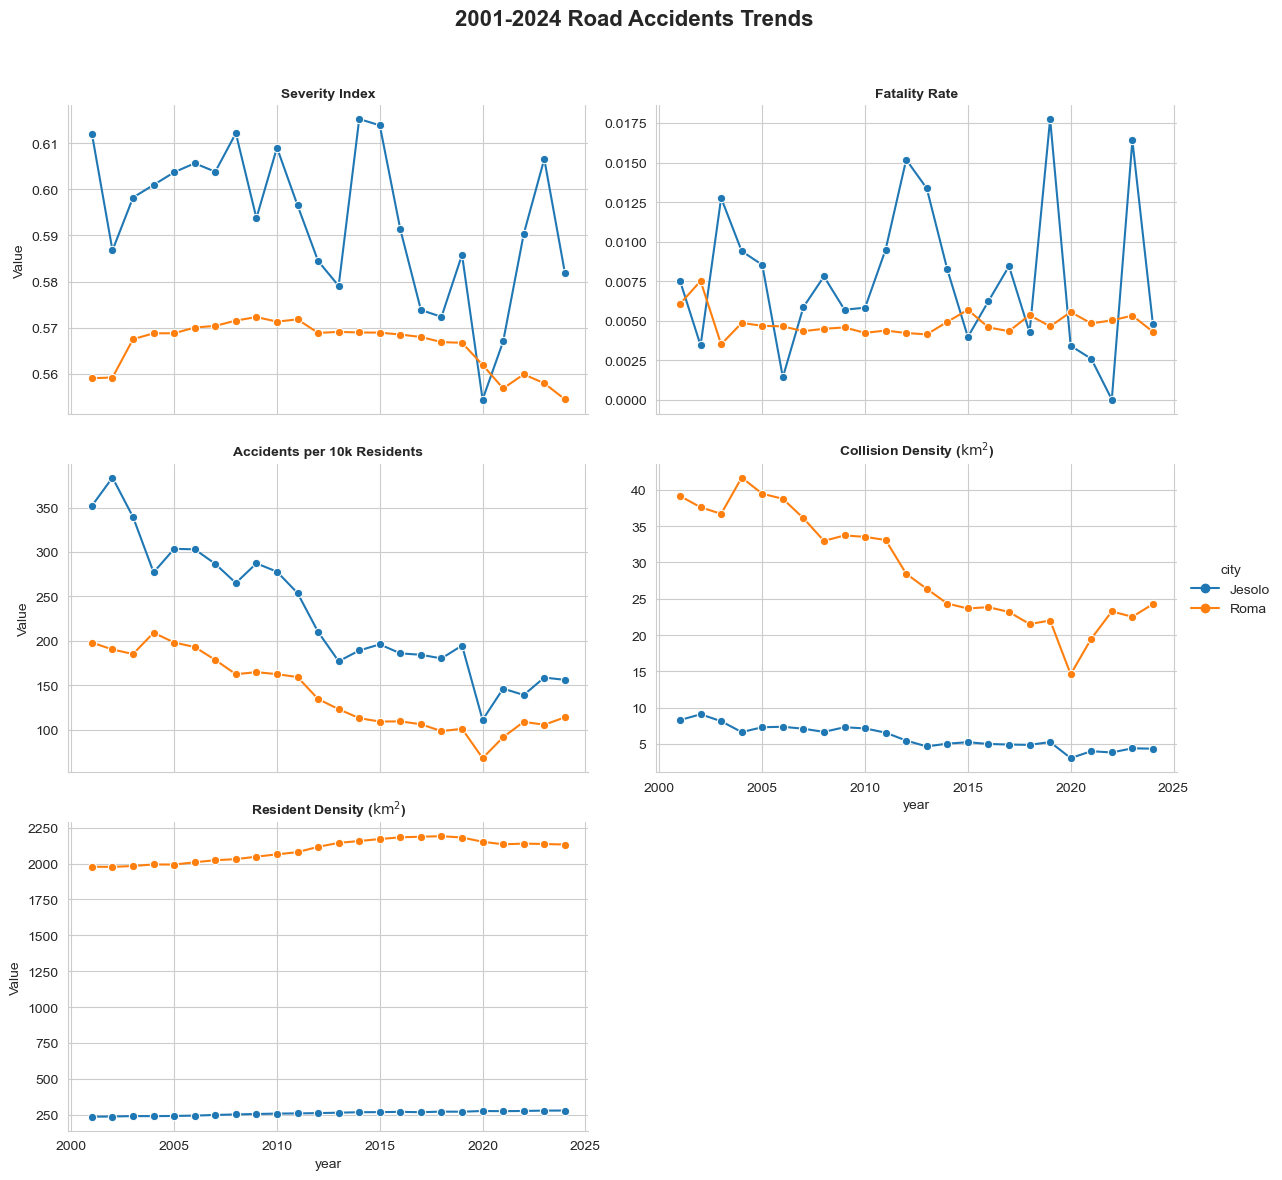

In [14]:
locations = ['Roma', 'Jesolo']

metrics = ['severity_index', 'fatality_rate', 'per_capita_accidents_rate', 'collision_density', 'resident_density']
metric_labels = {
    'per_capita_accidents_rate': 'Accidents per 10k Residents',
    'severity_index': 'Severity Index',
    'fatality_rate': 'Fatality Rate',
    'collision_density': r'Collision Density ($\text{km}^2$)',
    'resident_density': r'Resident Density ($\text{km}^2$)',
}
realplot_year_comparison(df_filtered[df_filtered['city'].isin(locations)], 'city', 'year', metrics, metric_labels)

The first thing we can see from this plot is that, upon closer observation of per capita and collision density, the number of accidents in both cities decreased. There was also a slight decrease in the Severity Index meanwhile Fatality Rate remain unchanged. This could be a sign that the number of accidents has changed over time due to car safety regulations, road quality, and other general regulations, but the risk of death don't. Only Rome presents an increase in population, which could indicate that the number of accidents near 2024 increased due to the increase in population. However, the risk of injury has decreased.
Of course, these are just initial hypotheses based on a small sample, so it’s impossible to provide a precise estimate of the trend. For example, let’s compare the major Italian cities to see if these trends are similar across them.

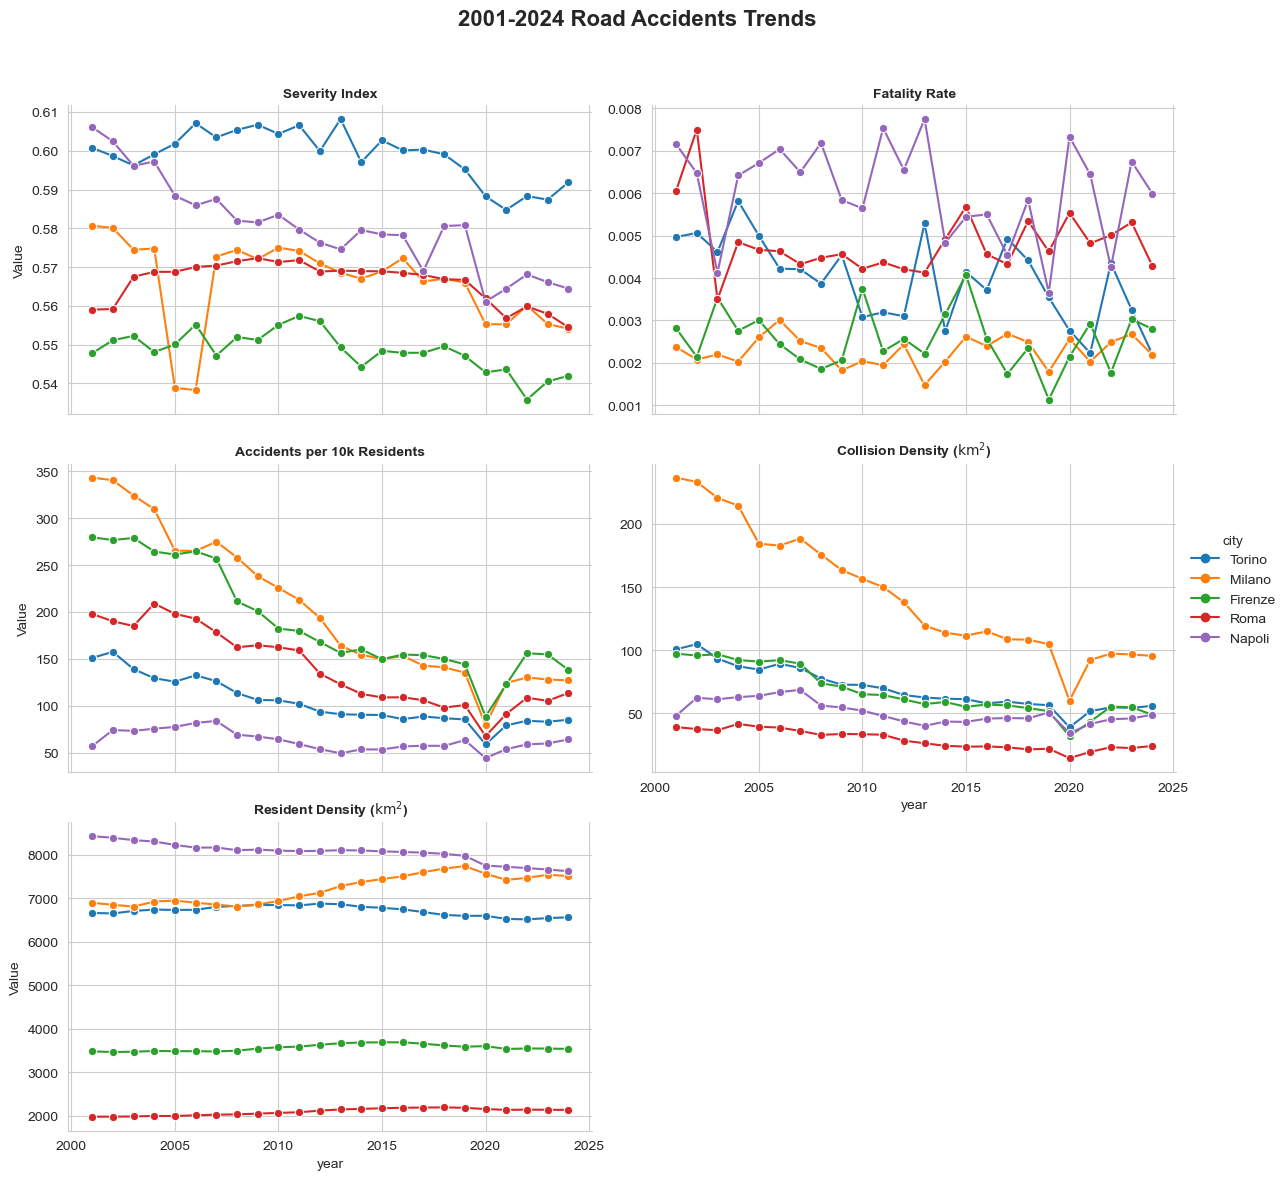

In [15]:
locations = ['Roma', 'Milano', 'Torino', 'Napoli', 'Firenze']

realplot_year_comparison(df_filtered[df_filtered['city'].isin(locations)], 'city', 'year', metrics, metric_labels)

We can see some information from this graph:
- we can see that the trend described earlier, how the number of accidents has decreased over the years, also holds true for other major cities besides Rome.
- the number of accidents dropped dramatically in 2020; this is due to the COVID-19 pandemic and the lockdown, during which residents were largely unable to travel freely by car for much of that year. Therefore, 2020 should not be fully factored into our analysis, as it represents a very specific case and thus introduces a bias in our calculations.
- Among Italy’s most populous cities, Milan has the highest number of accidents (see per-capita and collision density), but it is also among those cities, along with Florence, where the vast majority of accidents are simple collisions.
In fact, cities like Turin, but especially Naples, have the lowest number of accidents yet the highest severity index and fatality rate, with Naples leading the latter.  
One possible explanation for these figures is that Milan, with its heavy traffic, experiences accidents that occur at low speeds, whereas in Naples, the high fatality rate may be caused by the widespread use of mopeds, which are far more dangerous than cars.
- The most densely populated cities have the highest severity index, meaning fewer accidents but more injuries. Meanwhile, there is no clear distinction in the number of deaths. 

We can see that the downward trend in the number of accidents in Italy is consistent across regions as well, since, precisely because of the country’s geography, the terrain on which the roads are built can influence the number of accidents in Italy (Take Belforte Monferrato as an examplewhich is built on top of a hill).

In [16]:
# group by region
df_filtered_region = df_filtered.groupby(['region', 'year']).agg(
                                                        sum_residents=('residents', 'sum'),
                                                        region_area=('area (km2)', 'sum'),
                                                        collision=('collisions', 'sum'),
                                                        injuries=('injuries', 'sum'),
                                                        fatalities=('fatalities', 'sum'),
                                                        total_accidents=('total_accidents', 'sum')
                                                    ).reset_index()

# calculcate again the metrics
# 2. Harmful Accidents (M + F)
df_filtered_region['harmful_accidents'] = df_filtered_region['fatalities'] + df_filtered_region['injuries']

# 3. Severity Index (where condition to taking into account possible division by zero)
df_filtered_region['severity_index'] = np.where(df_filtered_region['total_accidents'] > 0, df_filtered_region['harmful_accidents'] / df_filtered_region['total_accidents'], 0,)

# 4. Fatality Rate
df_filtered_region['fatality_rate'] = np.where(df_filtered_region['total_accidents'] > 0, df_filtered_region['fatalities'] / df_filtered_region['total_accidents'], 0,)

# 5. Per-Capita Accidents Rate
df_filtered_region['per_capita_accidents_rate'] = (df_filtered_region['total_accidents'] / df_filtered_region['sum_residents']) * 1e4

# 6. Collision Density
df_filtered_region['collision_density'] = df_filtered_region['total_accidents'] / df_filtered_region['region_area']

# 7) Resident Density
df_filtered_region['resident_density'] = df_filtered_region['sum_residents'] / df_filtered_region['region_area']

df_filtered_region

,region,year,sum_residents,region_area,collision,injuries,fatalities,total_accidents,harmful_accidents,severity_index,fatality_rate,per_capita_accidents_rate,collision_density,resident_density
0,Abruzzo,2001,705491.0,1816.3795,4223.0,6124.0,91.0,10438.0,6215.0,0.595421,0.008718,147.953695,5.746596,388.405066
1,Abruzzo,2002,709858.0,1816.3803,4130.0,6229.0,85.0,10444.0,6314.0,0.604558,0.008139,147.128017,5.749897,390.809127
2,Abruzzo,2003,716934.0,1816.3803,4010.0,6032.0,74.0,10116.0,6106.0,0.603598,0.007315,141.100854,5.569318,394.704787
3,Abruzzo,2004,723014.0,1816.3803,3734.0,5498.0,64.0,9296.0,5562.0,0.598322,0.006885,128.572891,5.117871,398.052104
4,Abruzzo,2005,727835.0,1816.3803,3641.0,5303.0,60.0,9004.0,5363.0,0.595624,0.006664,123.709357,4.957112,400.706284
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,Veneto,2020,3163178.0,6546.5261,7150.0,9255.0,125.0,16530.0,9380.0,0.567453,0.007562,52.257571,2.525003,483.184204
476,Veneto,2021,3147023.0,6552.6063,9161.0,11997.0,155.0,21313.0,12152.0,0.570168,0.007273,67.724322,3.252599,480.270423
477,Veneto,2022,3129922.0,6465.4260,9826.0,12659.0,178.0,22663.0,12837.0,0.566430,0.007854,72.407555,3.505260,484.101434
478,Veneto,2023,3152708.0,6508.8115,9386.0,12261.0,193.0,21840.0,12454.0,0.570238,0.008837,69.273780,3.355451,484.375373


To make our lives easier, we create a relplot for the grouped regions of North, Center, and South, which makes the plot much easier to read.

In [17]:
df_filtered_region['region'].unique()

array(['Abruzzo', 'Basilicata', 'Calabria', 'Campania', 'Emilia-Romagna',
       'Friuli-Venezia Giulia', 'Lazio', 'Liguria', 'Lombardia', 'Marche',
       'Molise', 'Piemonte', 'Puglia', 'Sardegna', 'Sicilia', 'Toscana',
       'Trentino-Alto Adige/Südtirol', 'Umbria', "Valle d'Aosta",
       'Veneto'], dtype=object)

In [18]:
italian_regions_istat = {
    # Nord-Ovest
    "Piemonte": "North-West",
    "Valle d'Aosta": "North-West",
    "Lombardia": "North-West",
    "Liguria": "North-West",
    # Nord-Est
    "Trentino-Alto Adige": "North-East",
    "Veneto": "North-East",
    "Friuli-Venezia Giulia": "North-East",
    "Emilia-Romagna": "North-East",
    # Centro
    "Toscana": "Center",
    "Umbria": "Center",
    "Marche": "Center",
    "Lazio": "Center",
    # Sud e Isole
    "Abruzzo": "South",
    "Molise": "South",
    "Campania": "South",
    "Puglia": "South",
    "Basilicata": "South",
    "Calabria": "South",
    "Sicilia": "Islands",
    "Sardegna": "Islands",
}

df_filtered_region['location'] = np.empty(df_filtered_region.shape[0], dtype=object)
df_filtered_region['location'] = df_filtered_region['region'].map(italian_regions_istat)
df_filtered_region

,region,year,sum_residents,region_area,collision,injuries,fatalities,total_accidents,harmful_accidents,severity_index,fatality_rate,per_capita_accidents_rate,collision_density,resident_density,location
0,Abruzzo,2001,705491.0,1816.3795,4223.0,6124.0,91.0,10438.0,6215.0,0.595421,0.008718,147.953695,5.746596,388.405066,South
1,Abruzzo,2002,709858.0,1816.3803,4130.0,6229.0,85.0,10444.0,6314.0,0.604558,0.008139,147.128017,5.749897,390.809127,South
2,Abruzzo,2003,716934.0,1816.3803,4010.0,6032.0,74.0,10116.0,6106.0,0.603598,0.007315,141.100854,5.569318,394.704787,South
3,Abruzzo,2004,723014.0,1816.3803,3734.0,5498.0,64.0,9296.0,5562.0,0.598322,0.006885,128.572891,5.117871,398.052104,South
4,Abruzzo,2005,727835.0,1816.3803,3641.0,5303.0,60.0,9004.0,5363.0,0.595624,0.006664,123.709357,4.957112,400.706284,South
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,Veneto,2020,3163178.0,6546.5261,7150.0,9255.0,125.0,16530.0,9380.0,0.567453,0.007562,52.257571,2.525003,483.184204,North-East
476,Veneto,2021,3147023.0,6552.6063,9161.0,11997.0,155.0,21313.0,12152.0,0.570168,0.007273,67.724322,3.252599,480.270423,North-East
477,Veneto,2022,3129922.0,6465.4260,9826.0,12659.0,178.0,22663.0,12837.0,0.566430,0.007854,72.407555,3.505260,484.101434,North-East
478,Veneto,2023,3152708.0,6508.8115,9386.0,12261.0,193.0,21840.0,12454.0,0.570238,0.008837,69.273780,3.355451,484.375373,North-East


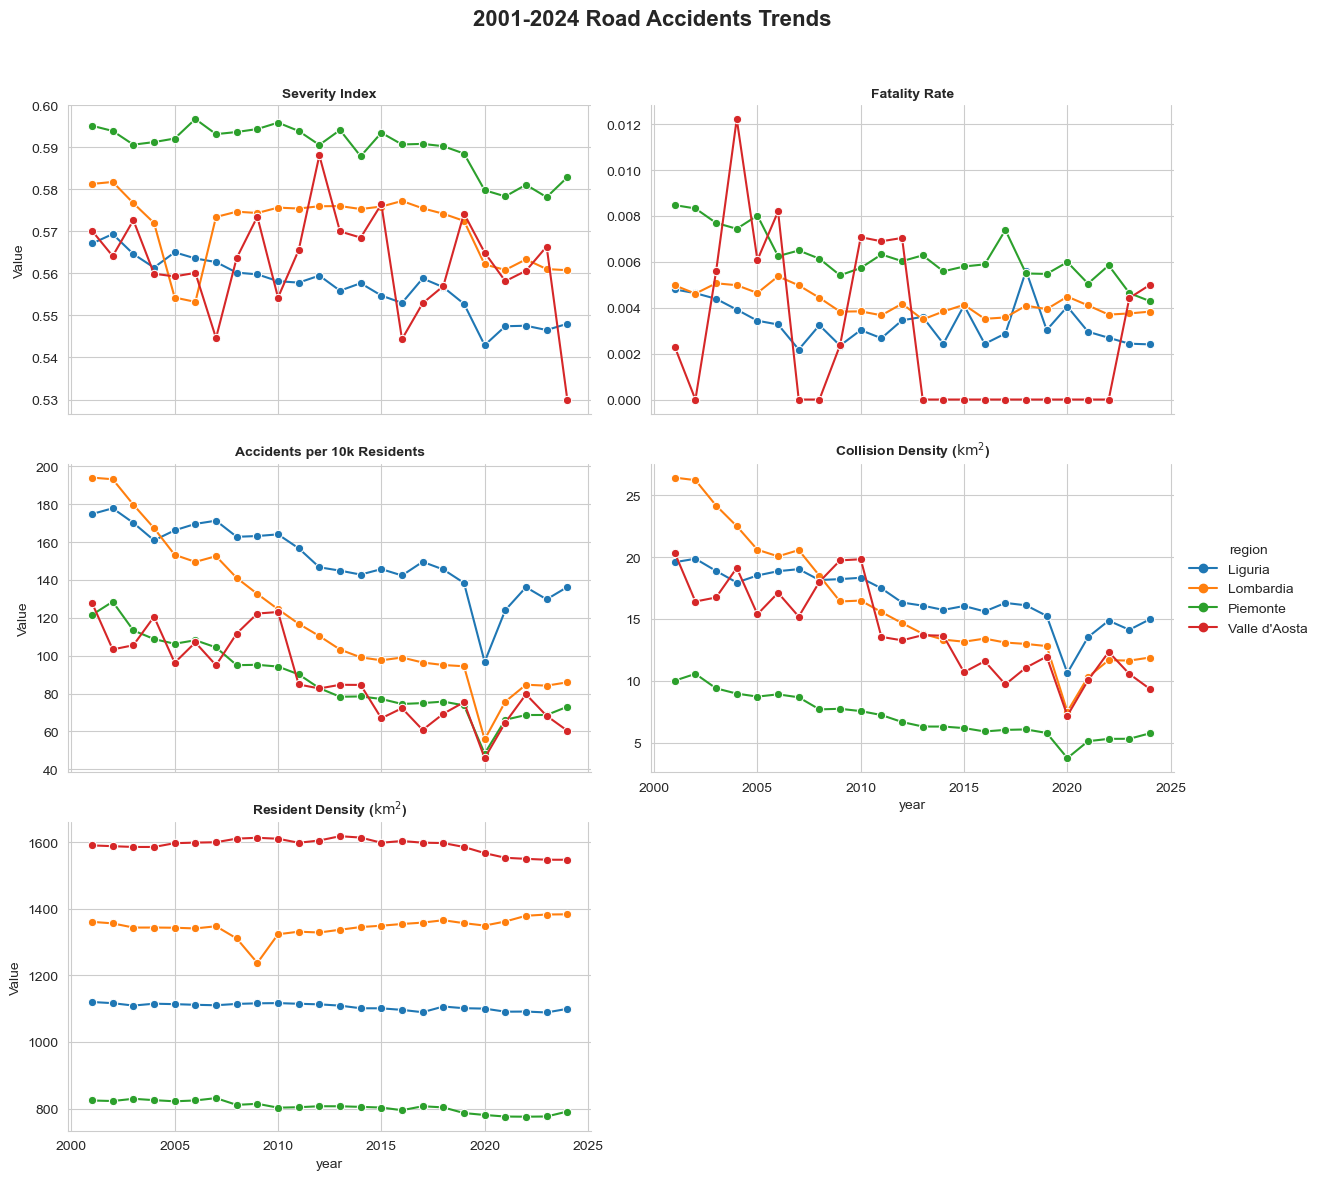

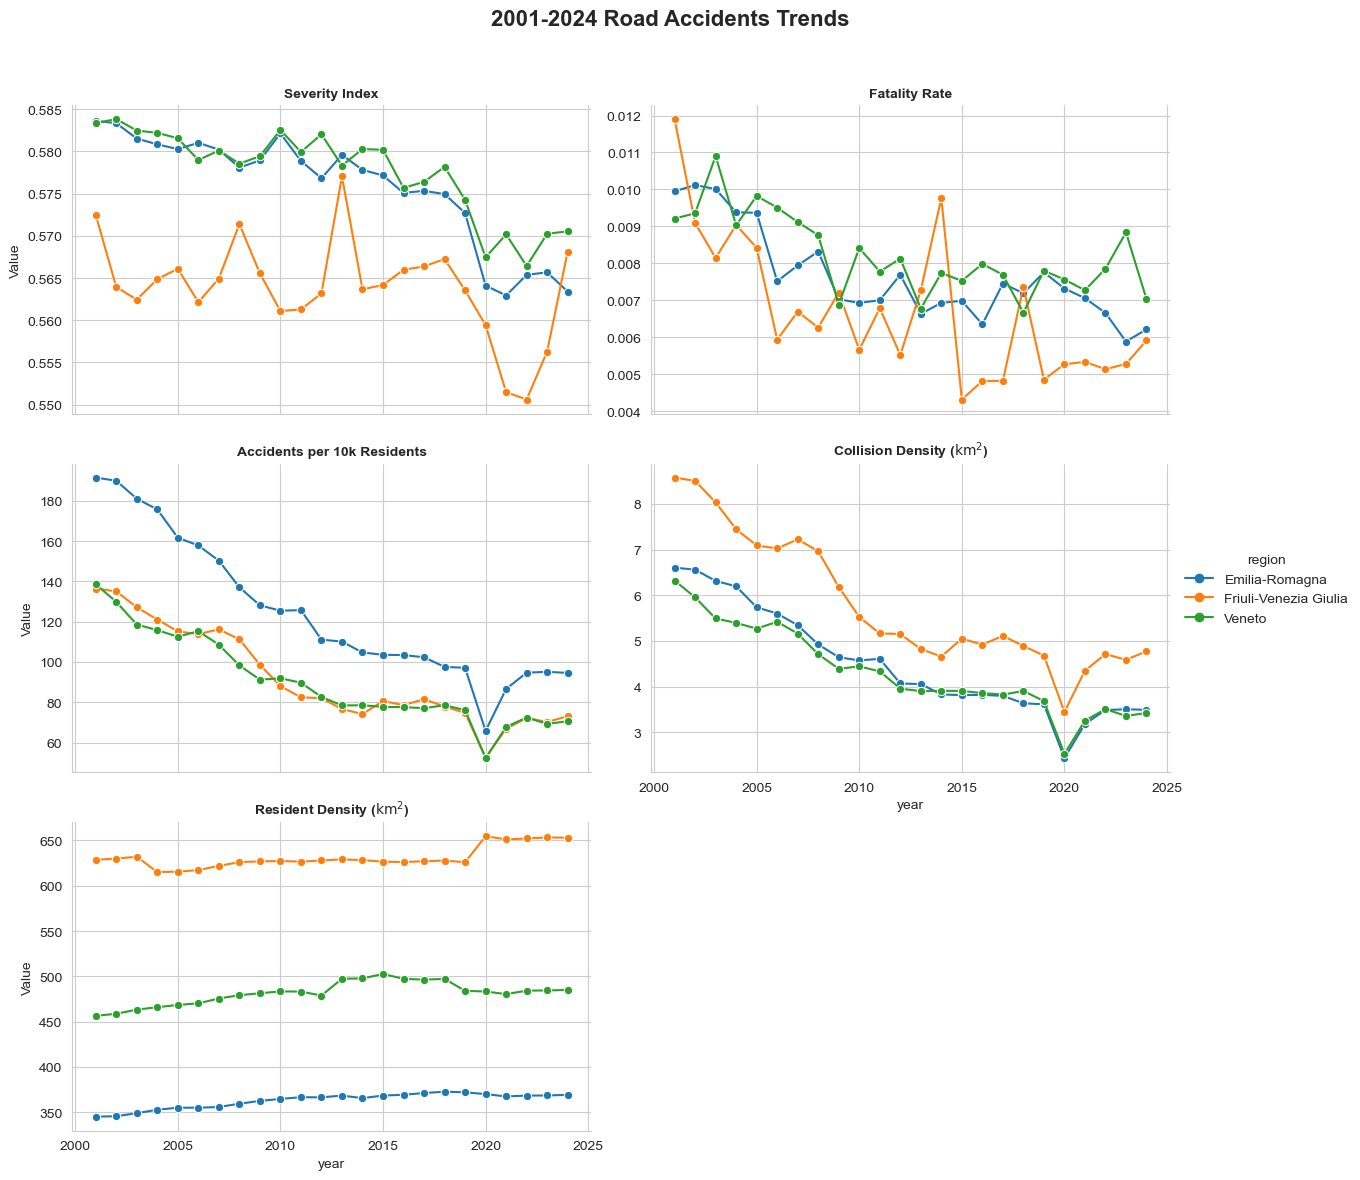

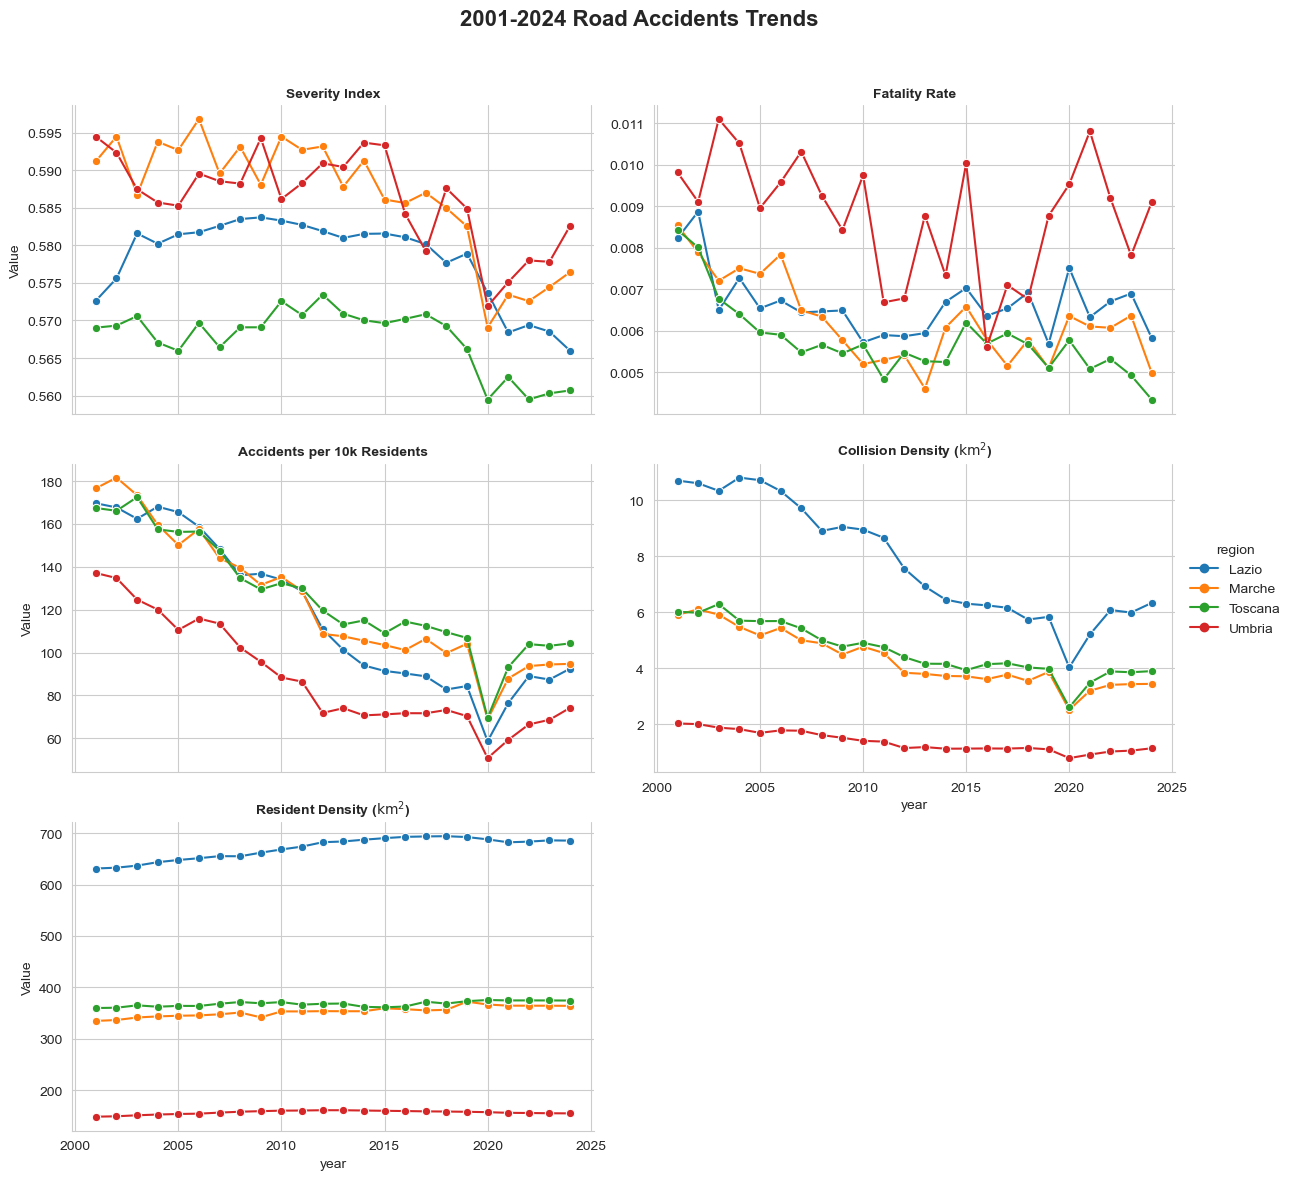

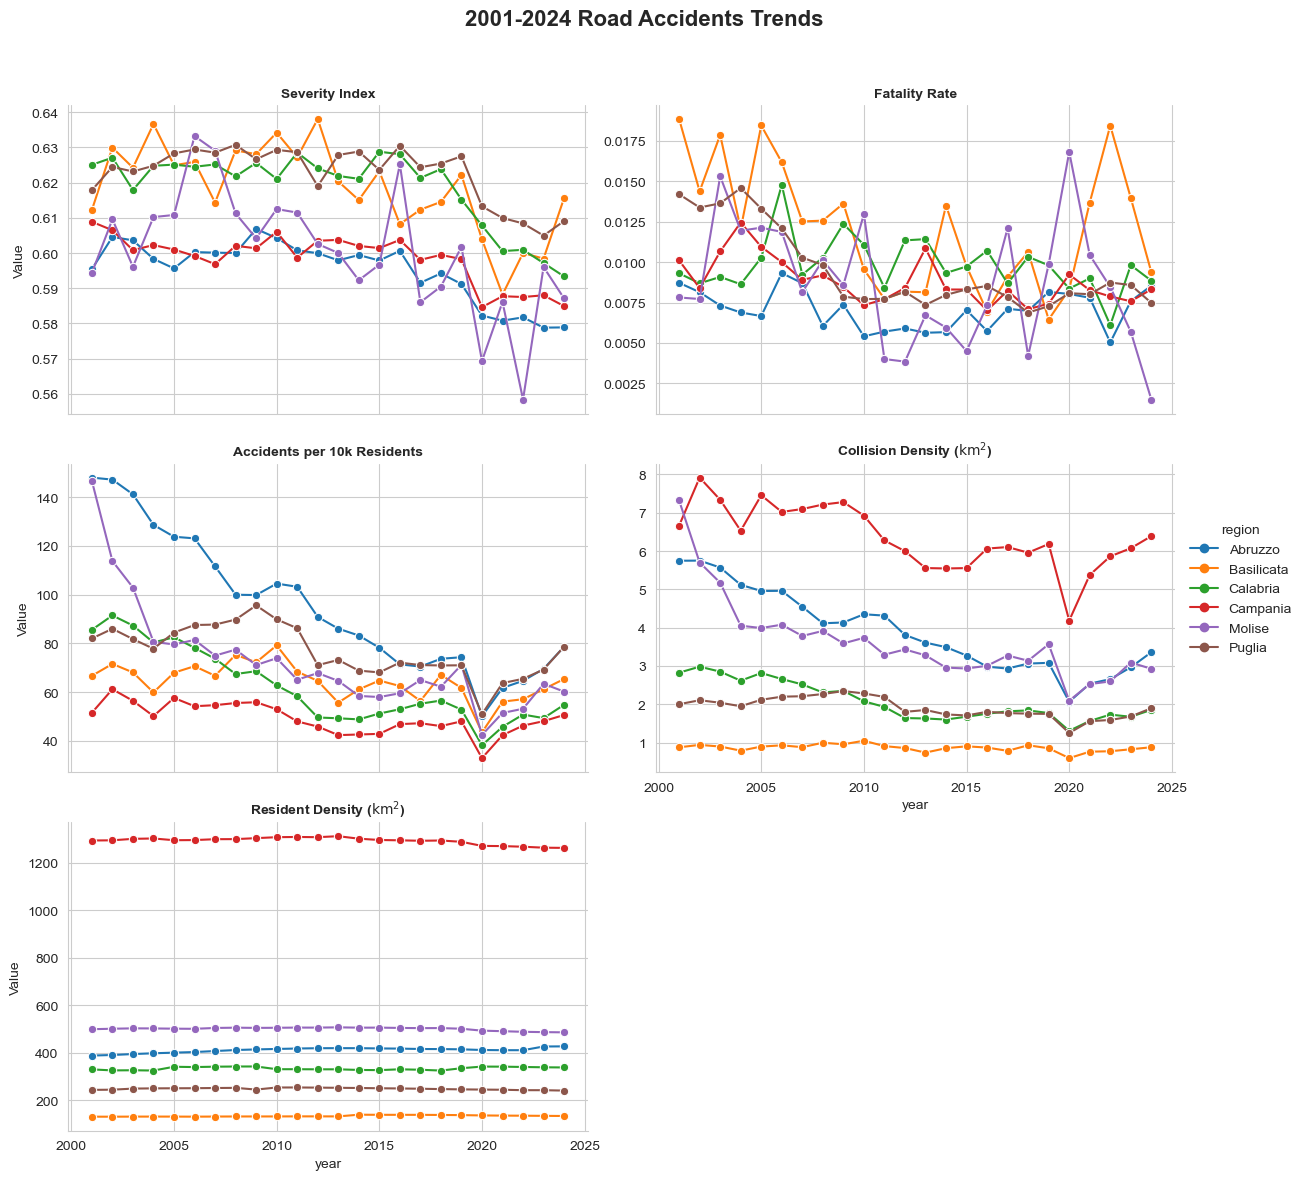

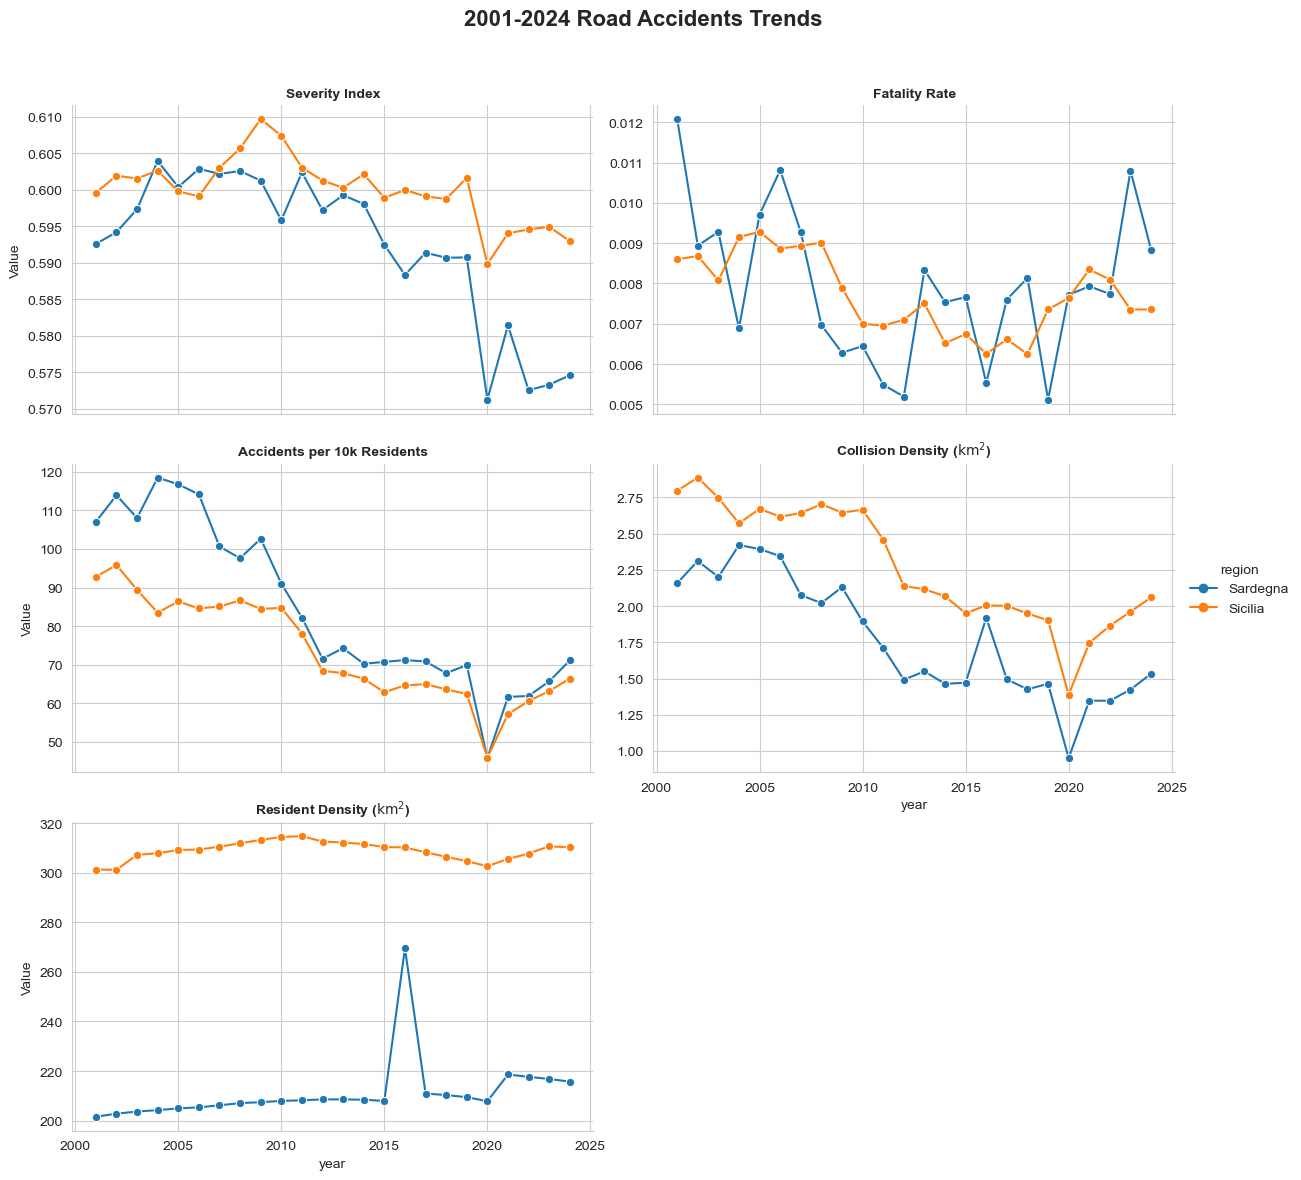

In [19]:
# North-West (Nord-Ovest)
north_west = ["Piemonte", "Valle d'Aosta", "Lombardia", "Liguria"]

# North-East (Nord-Est)
north_east = ["Trentino-Alto Adige", "Veneto", "Friuli-Venezia Giulia", "Emilia-Romagna",]

# Center (Centro)
center = ["Toscana", "Umbria", "Marche", "Lazio"]

# South (Sud)
south = ["Abruzzo", "Molise", "Campania", "Puglia", "Basilicata", "Calabria"]

# Islands
islands = ["Sicilia", "Sardegna"]

all_region = [north_west, north_east, center, south, islands]

for r in all_region:

    metrics = ['severity_index', 'fatality_rate', 'per_capita_accidents_rate', 'collision_density', 'resident_density']
    metric_labels = {
        'per_capita_accidents_rate': 'Accidents per 10k Residents',
        'severity_index': 'Severity Index',
        'fatality_rate': 'Fatality Rate',
        'collision_density': r'Collision Density ($\text{km}^2$)',
        'resident_density': r'Resident Density ($\text{km}^2$)',
    }

    realplot_year_comparison(df_filtered_region[df_filtered_region['region'].isin(r)], 'region', 'year', metrics, metric_labels)

Looking at the graphs, but this time examining each region individually, we can see that the previously hypothesized trend of a decrease in the number of accidents over time is true for the per capita and collision density metrics, meanwhile is not for the fatality rate and the severity index specially for smaller regions like Umbria and Valle d'Aosta. In 2020, every region experienced a sharp drop in accidents caused by the lockdown. It seems that the number of accidents has increased slightly in some regions since then, while it has remained stable in others.  

Since the purpose of this analysis is to determine where to focus efforts to invest in accident prevention now and in the future, the next step will be to identify the areas where the largest increase has occurred since 2020 (assuming that this increase will continue in the coming years).  

For the sake of completeness, we checked the regional trend, including all the minor towns that we didn't initially consider, to see if there were any significant changes.

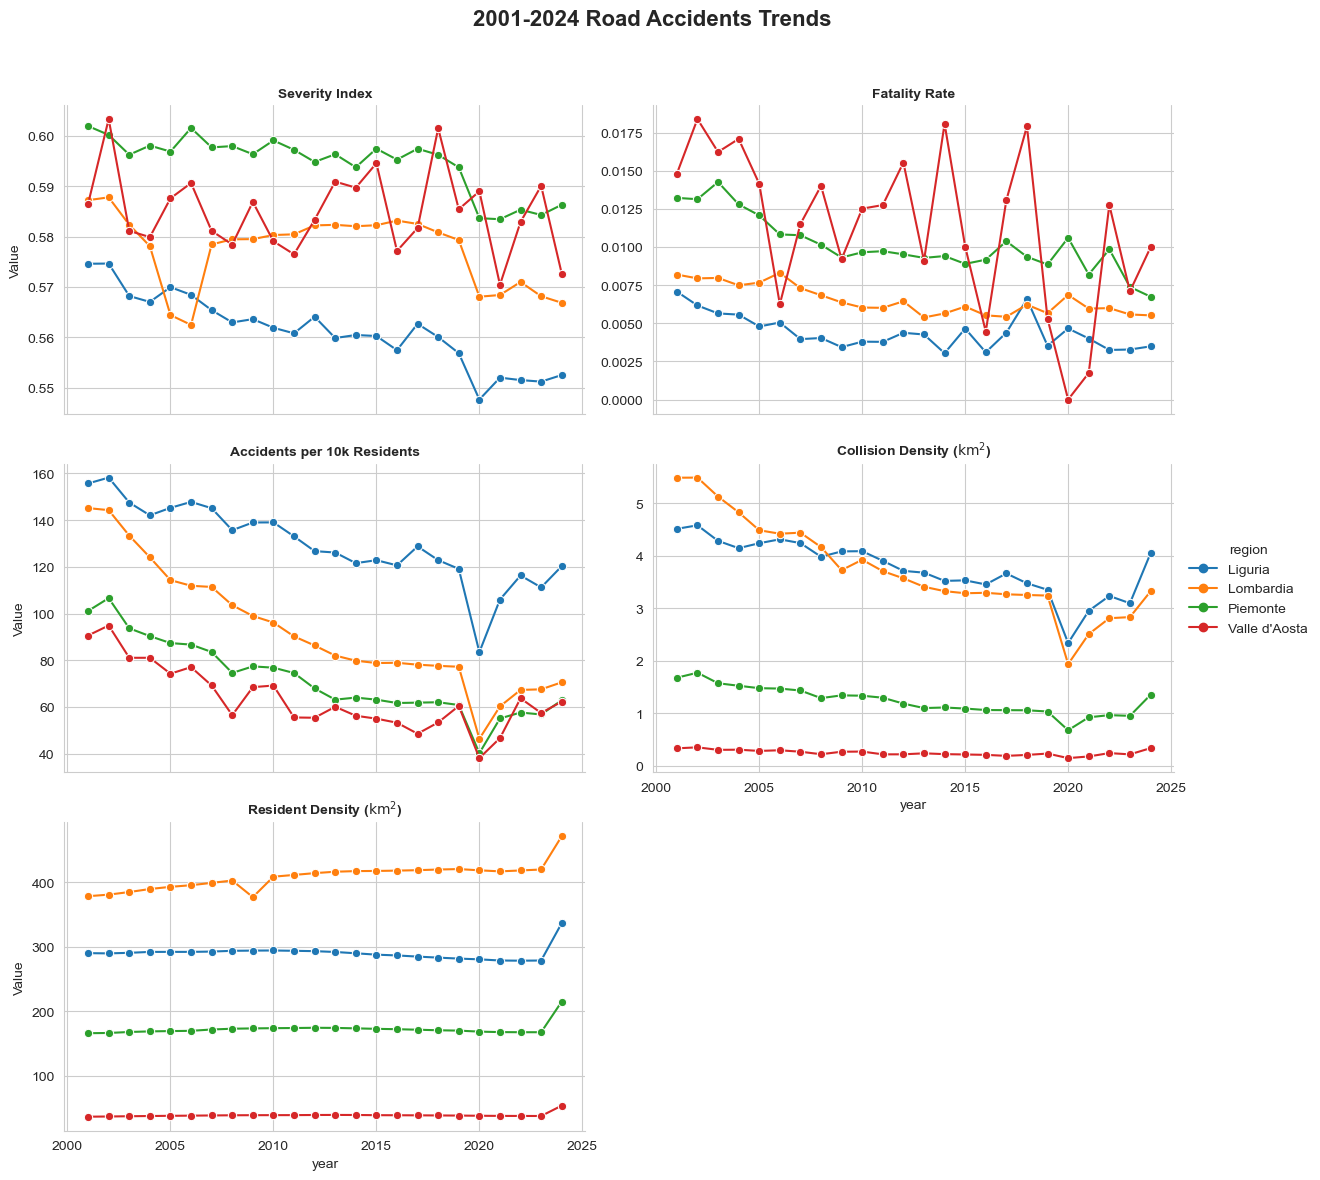

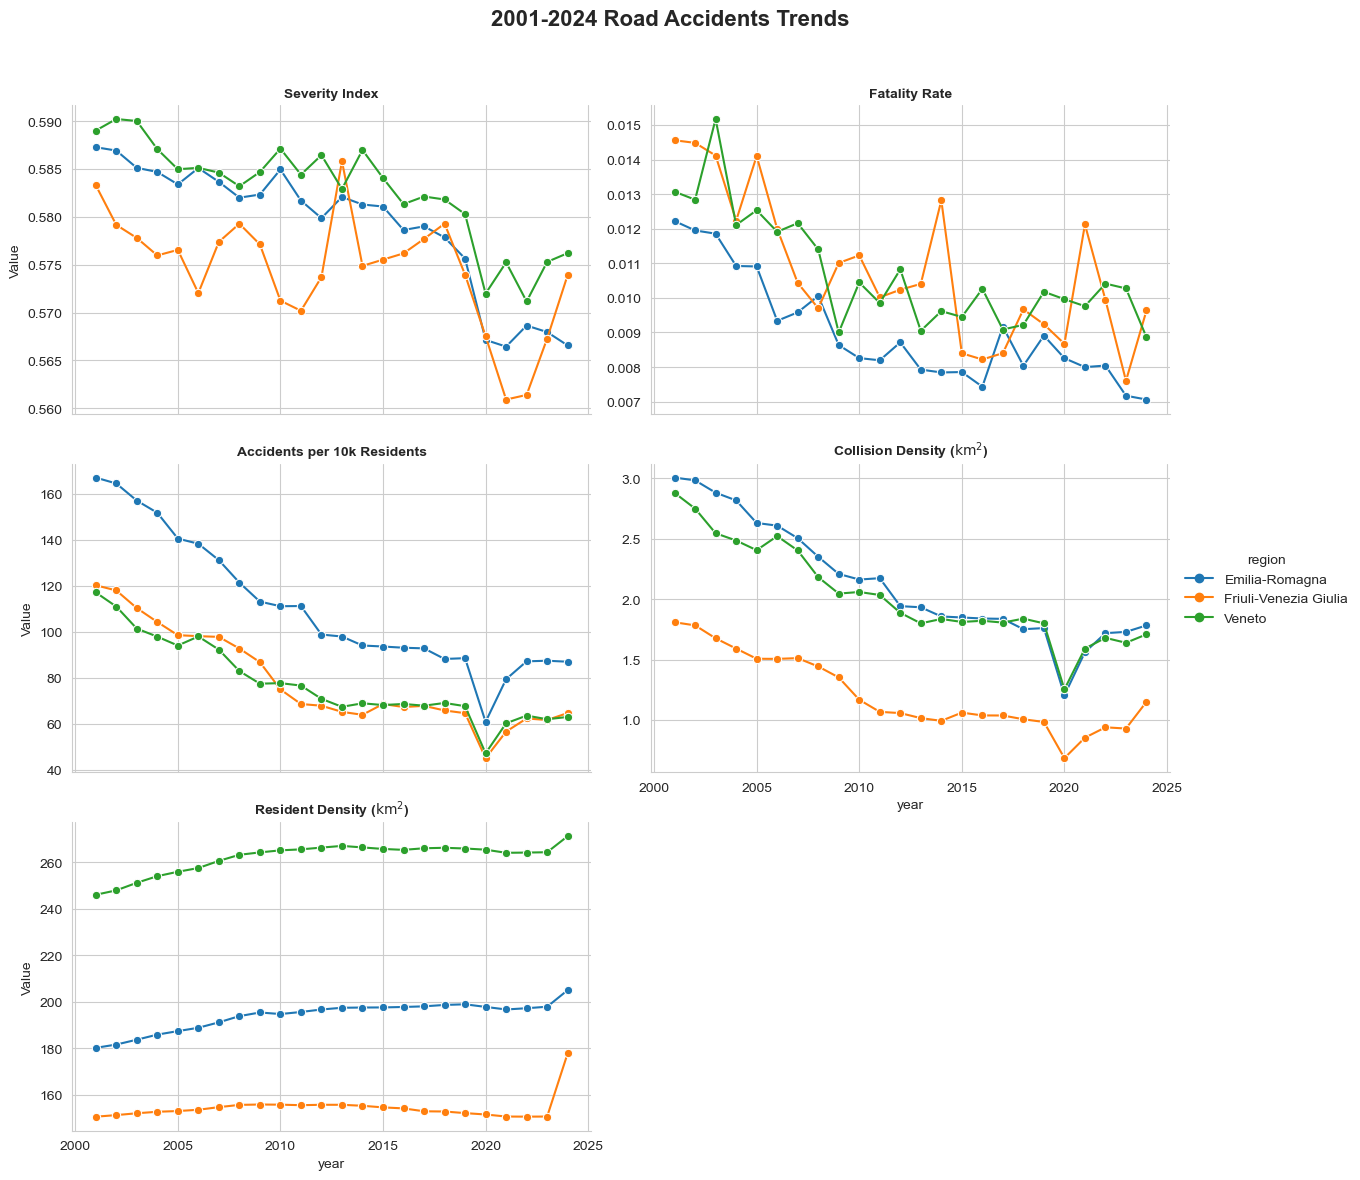

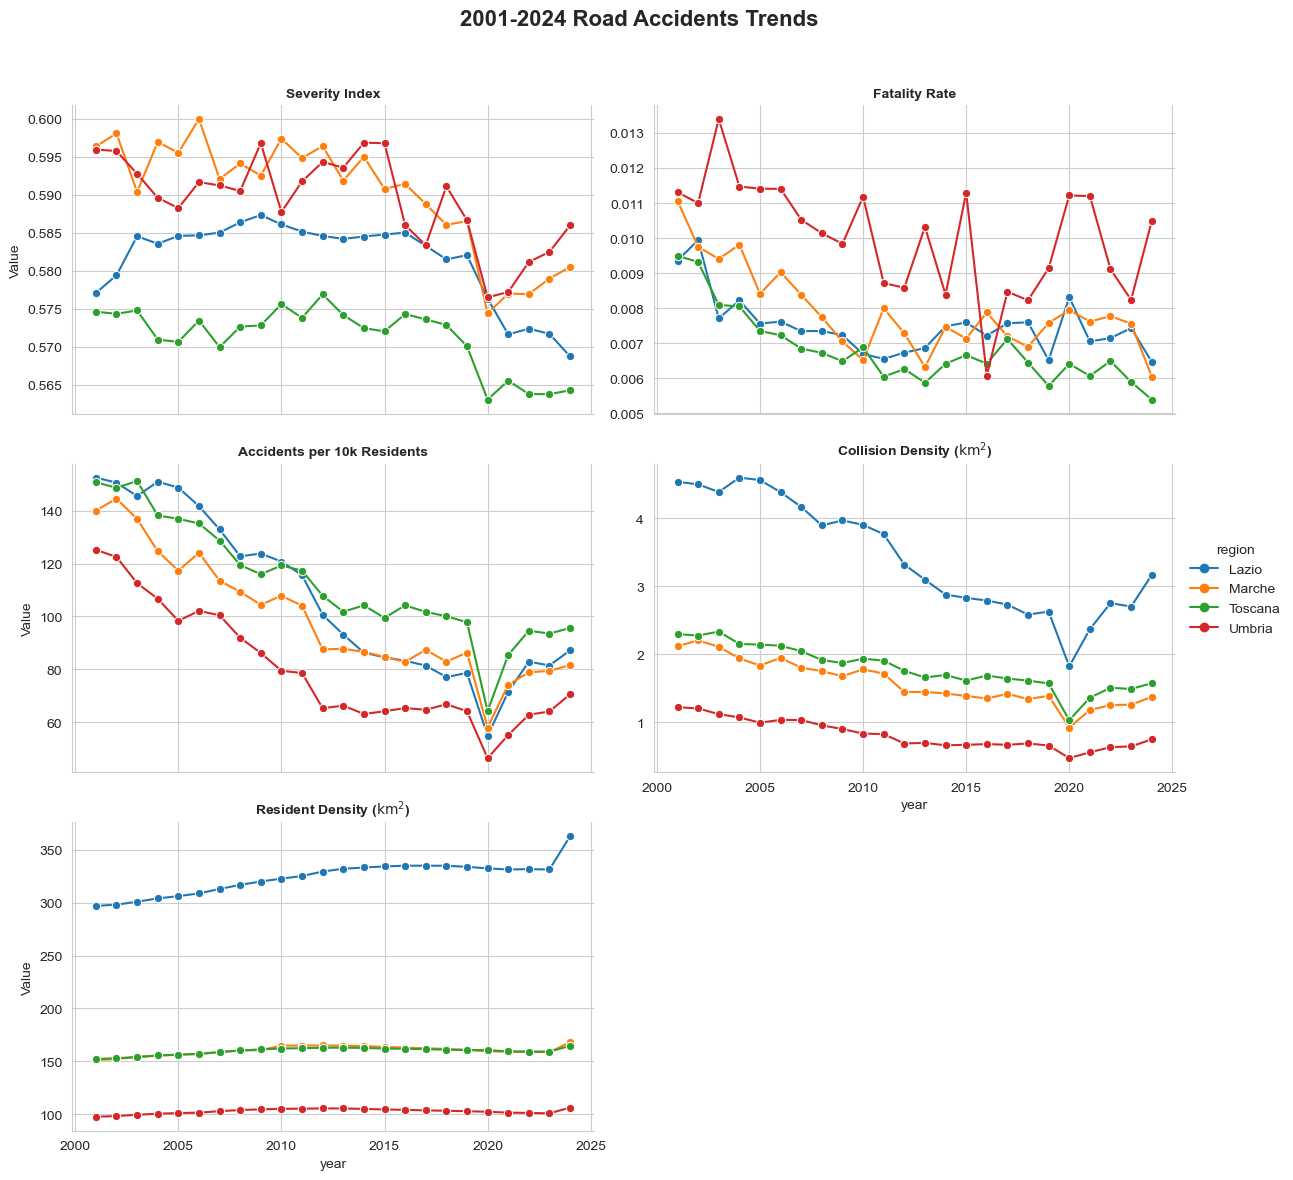

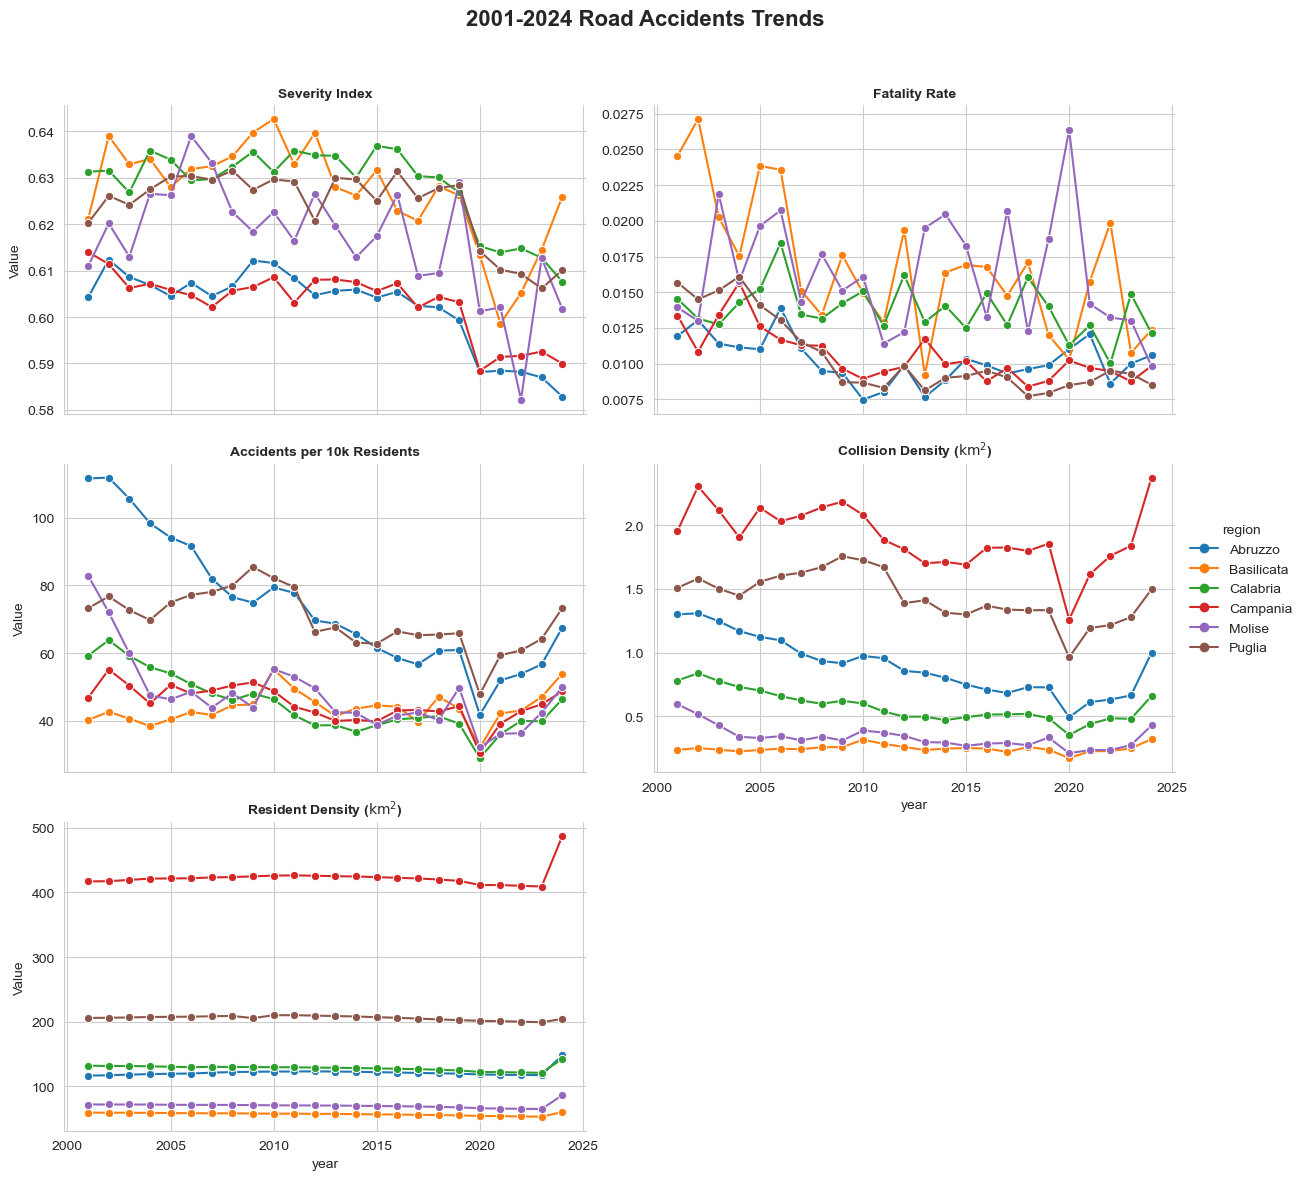

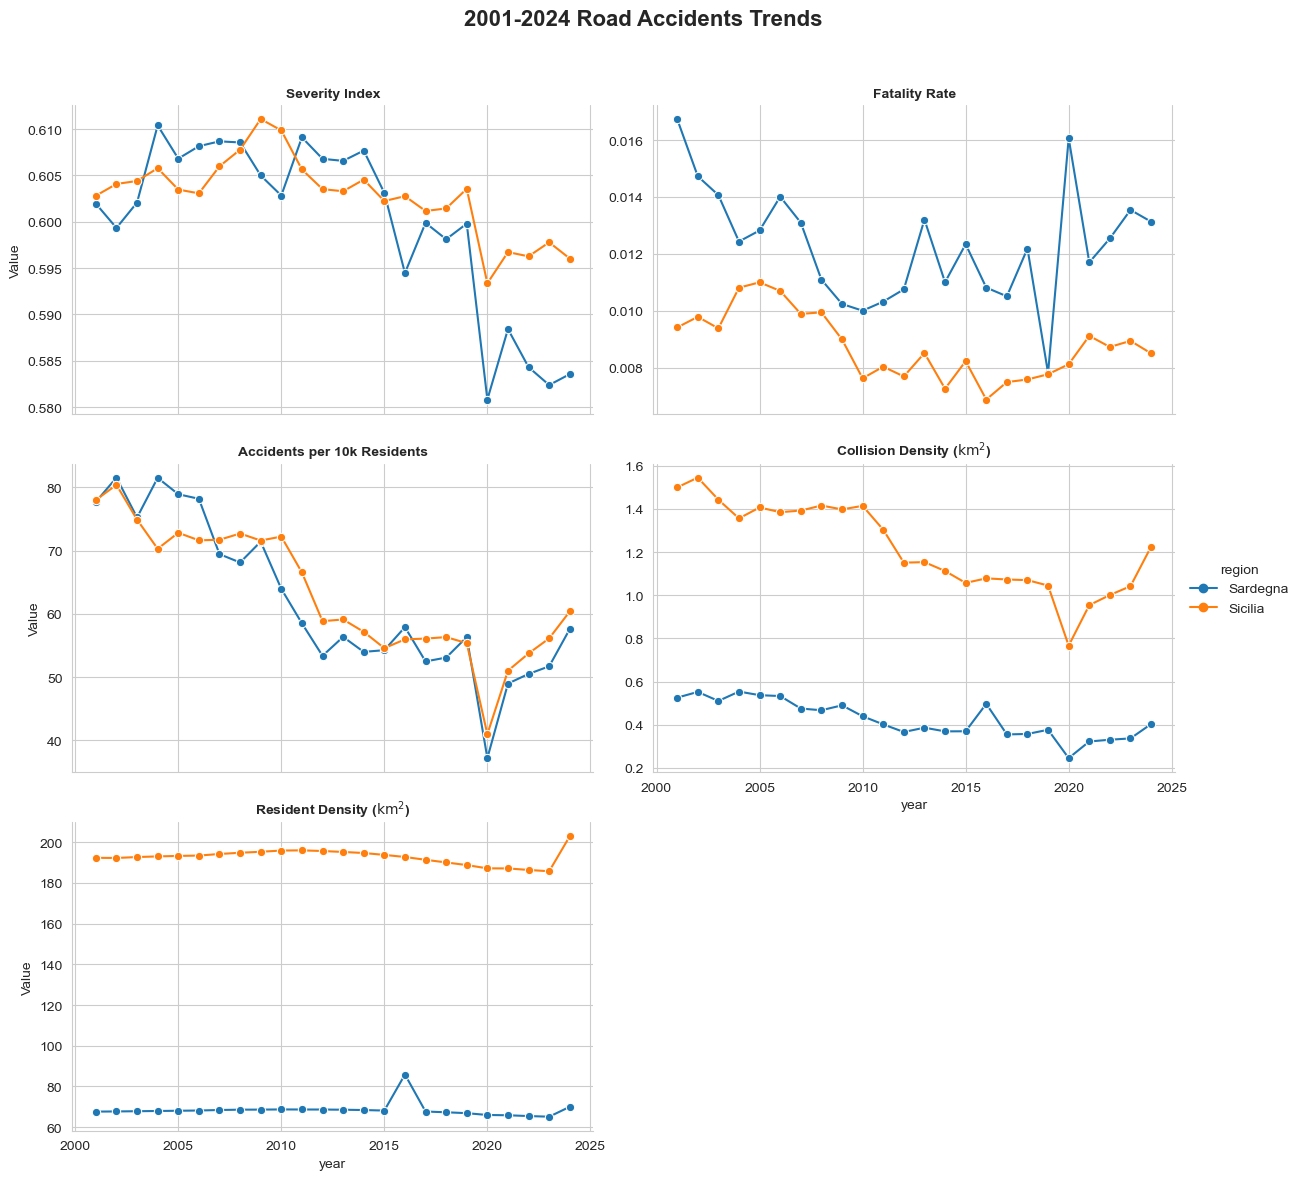

In [20]:
# group by region
df_region = df_pivot.groupby(['region', 'year']).agg(
                                        sum_residents=('residents', 'sum'),
                                        region_area=('area (km2)', 'sum'),
                                        collision=('collisions', 'sum'),
                                        injuries=('injuries', 'sum'),
                                        fatalities=('fatalities', 'sum')
                                    ).reset_index()

# calculcate again the metrics
# 1) Total Accidents
df_region['total_accidents'] = df_region['collision'] + df_region['injuries'] + df_region['fatalities']

# 2. Harmful Accidents (M + F)
df_region['Harmful_Accidents'] = df_region['fatalities'] + df_region['injuries']

# 3. Severity Index (where condition to taking into account possible division by zero)
df_region['severity_index'] = np.where(df_region['total_accidents'] > 0, df_region['Harmful_Accidents'] / df_region['total_accidents'], 0,)

# 4. Fatality Rate
df_region['fatality_rate'] = np.where(df_region['total_accidents'] > 0, df_region['fatalities'] / df_region['total_accidents'], 0,)

# 5. Per-Capita Accidents Rate
df_region['per_capita_accidents_rate'] = (df_region['total_accidents'] / df_region['sum_residents']) * 1e4

# 6. Collision Density
df_region['collision_density'] = df_region['total_accidents'] / df_region['region_area']

# 7) Resident Density
df_region['resident_density'] = df_region['sum_residents'] / df_region['region_area']

df_region['location'] = df_region['region'].map(italian_regions_istat)

for r in all_region:

    metrics = ['severity_index', 'fatality_rate', 'per_capita_accidents_rate', 'collision_density', 'resident_density']
    metric_labels = {
        'per_capita_accidents_rate': 'Accidents per 10k Residents',
        'severity_index': 'Severity Index',
        'fatality_rate': 'Fatality Rate',
        'collision_density': r'Collision Density ($\text{km}^2$)',
        'resident_density': r'Resident Density ($\text{km}^2$)',
    }

    realplot_year_comparison(df_region[df_region['region'].isin(r)], 'region', 'year', metrics, metric_labels)

The main differences we see are in the collision density and residents density, which strongly affects some regions. However, if we look closely, we see that the cause of these changes is particular to small regions, such as Valle d'Aosta and Molise, or regions with a high number of tows, like Sardegna and Friuli. Since these regions are very small, the number of collisions is very low, almost zero, but they increase the region surface area, lowering the densities.  
We can now proceed by using the filtered dataframe.

## IDENTIFICATION

Let's clarify the goal of our analysis so that we keep it in mind. Our company, which works in road traffic management and risk prevention, asked us to create an updated dashboard showing the best italian municipalities in which to invest. This means we have to identify the cities with the most accidents and determine how serious they are.  
Analyzing traffic accidents requires balancing two fundamental concepts:
- **Exposure**: How often do accidents occur?
- **Payout Risk**: How serious or fatal are the collisions when they do occur?

Let's review the metrics we have already calculated:
- **Severity Index:** A higher ratio means that crashes regularly result in injury or death.
- **Fatality rate:** It indicates severe liability payout risks
- **Per capita (x10000) accidents:** Individual exposure rate.
- **Collision Density:** High values mean frequent urban accidents.

One initial analysis could be to determine which city has the highest number of recorded accidents in the last year. We could simply print the top ten cities based on the per capita rate, but that would not be a complete answer. It would be better to identify the type of city that has the highest number of accidents, which could be done by clustering.

In [21]:
df_filtered[df_filtered['year'] == 2024].sort_values('per_capita_accidents_rate', ascending=False).reset_index(drop=True).head(20)

type,city_id,year,city,province,region,residents,area (km2),degurba,collisions,injuries,fatalities,total_accidents,harmful_accidents,severity_index,fatality_rate,per_capita_accidents_rate,collision_density,resident_density
0,10028,2024,Lavagna,GE,Liguria,12367.0,13.8679,2,102.0,133.0,2.0,237.0,135.0,0.569620,0.008439,191.639039,17.089826,891.771645
1,17161,2024,Rezzato,BS,Lombardia,13540.0,18.2064,2,102.0,142.0,0.0,244.0,142.0,0.581967,0.000000,180.206795,13.401881,743.694525
2,9029,2024,Finale Ligure,SV,Liguria,11012.0,35.5308,2,83.0,112.0,1.0,196.0,113.0,0.576531,0.005102,177.987650,5.516341,309.928288
3,48005,2024,Calenzano,FI,Toscana,17994.0,76.8222,2,127.0,179.0,4.0,310.0,183.0,0.590323,0.012903,172.279649,4.035292,234.229168
4,9002,2024,Albenga,SV,Liguria,23539.0,36.5893,2,172.0,220.0,0.0,392.0,220.0,0.561224,0.000000,166.532138,10.713515,643.330154
5,16024,2024,Bergamo,BG,Lombardia,120389.0,40.2430,1,893.0,1078.0,6.0,1977.0,1084.0,0.548306,0.003035,164.217661,49.126556,2991.551326
6,48002,2024,Barberino di Mugello,FI,Toscana,10939.0,133.3250,2,75.0,102.0,2.0,179.0,104.0,0.581006,0.011173,163.634702,1.342584,82.047628
7,27019,2024,Jesolo,VE,Veneto,26994.0,96.9423,2,176.0,243.0,2.0,421.0,245.0,0.581948,0.004751,155.960584,4.342789,278.454297
8,65025,2024,Capaccio Paestum,SA,Campania,22410.0,113.5471,3,136.0,201.0,10.0,347.0,211.0,0.608069,0.028818,154.841589,3.056001,197.363033
9,9056,2024,Savona,SV,Liguria,58581.0,65.3740,1,409.0,492.0,1.0,902.0,493.0,0.546563,0.001109,153.974838,13.797534,896.090189


By print the first 20 cities by `per_capita_accidents_rate` we get that the first for the year 2024 is Lavagna, a small city in Liguria with less than 15k residents and the first big city (more than 100k), Bergamo, appears only 6th. Looking at these results, one might think that the best places to invest are small cities, with some exceptions. But let's see if that's true.
We will use clustering tools to recognize patterns within different cities.

array([[<Axes: title={'center': 'severity_index'}>,
        <Axes: title={'center': 'per_capita_accidents_rate'}>],
       [<Axes: title={'center': 'resident_density'}>, <Axes: >]],
      dtype=object)

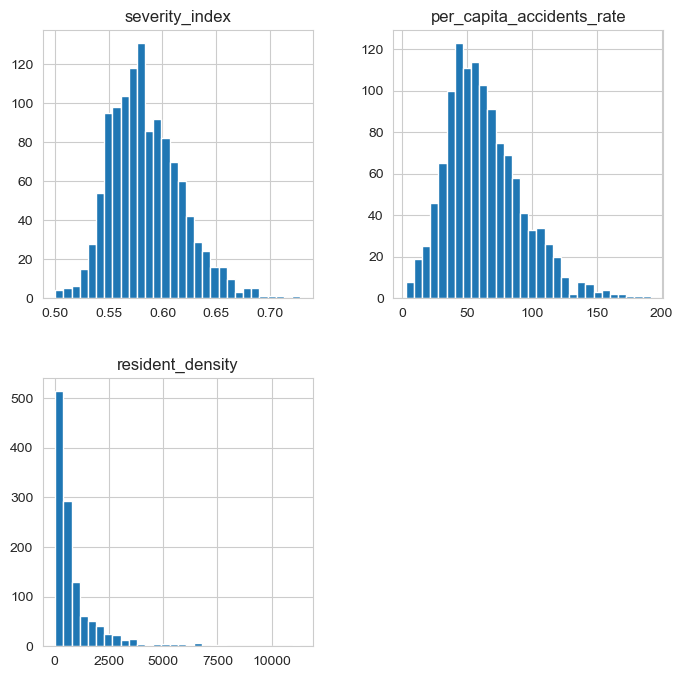

In [182]:
# check metrics distribution

#FEATURES = ['severity_index', 'fatality_rate', 'per_capita_accidents_rate', 'resident_density']
FEATURES = ['severity_index', 'per_capita_accidents_rate', 'resident_density']
#LOG_FEATURES = ['fatality_rate', 'per_capita_accidents_rate', 'resident_density']
LOG_FEATURES = ['per_capita_accidents_rate', 'resident_density']

df_2024 = df_filtered[df_filtered['year'] == 2024].copy()

df_2024[FEATURES].hist(figsize=(8, 8), bins=30)

We can see that the distributions for `severity_index` and `per_capita_accidents_rate` are similar to a Gaussian, even though the latter has a long tail up to 200, while the former two do not. Therefore, it is better to transform and scale the four different distributions.
First we apply `np.log1p()` to the skewed one so that they become more closer to a symmetric-normal distribution and then we scale with RobustScaler but why use `RobustScaler` instead of another scaler?  
Since our data does not follow a normal distribution, a `StandardScaler` is not ideal because outliers deflect the standard deviation. The same logic applies to a `MinMax` scaler. Here, outliers set the maximum boundaries to [-1, 1], compressing the other values into a very small range. `RobustScaler`, on the other hand, scales the data using only the central 50%, ignoring the outliers completely.

$$
x = \dfrac{x - Q_2(x)}{Q_3(x) - Q_1(x)}
$$

- $Q_2(x)$ is the median
- $Q_3(x) - Q_1(x)$ is the IQR (Interquartile Range) which is the distance between the 75th percentile and the 25th percentile

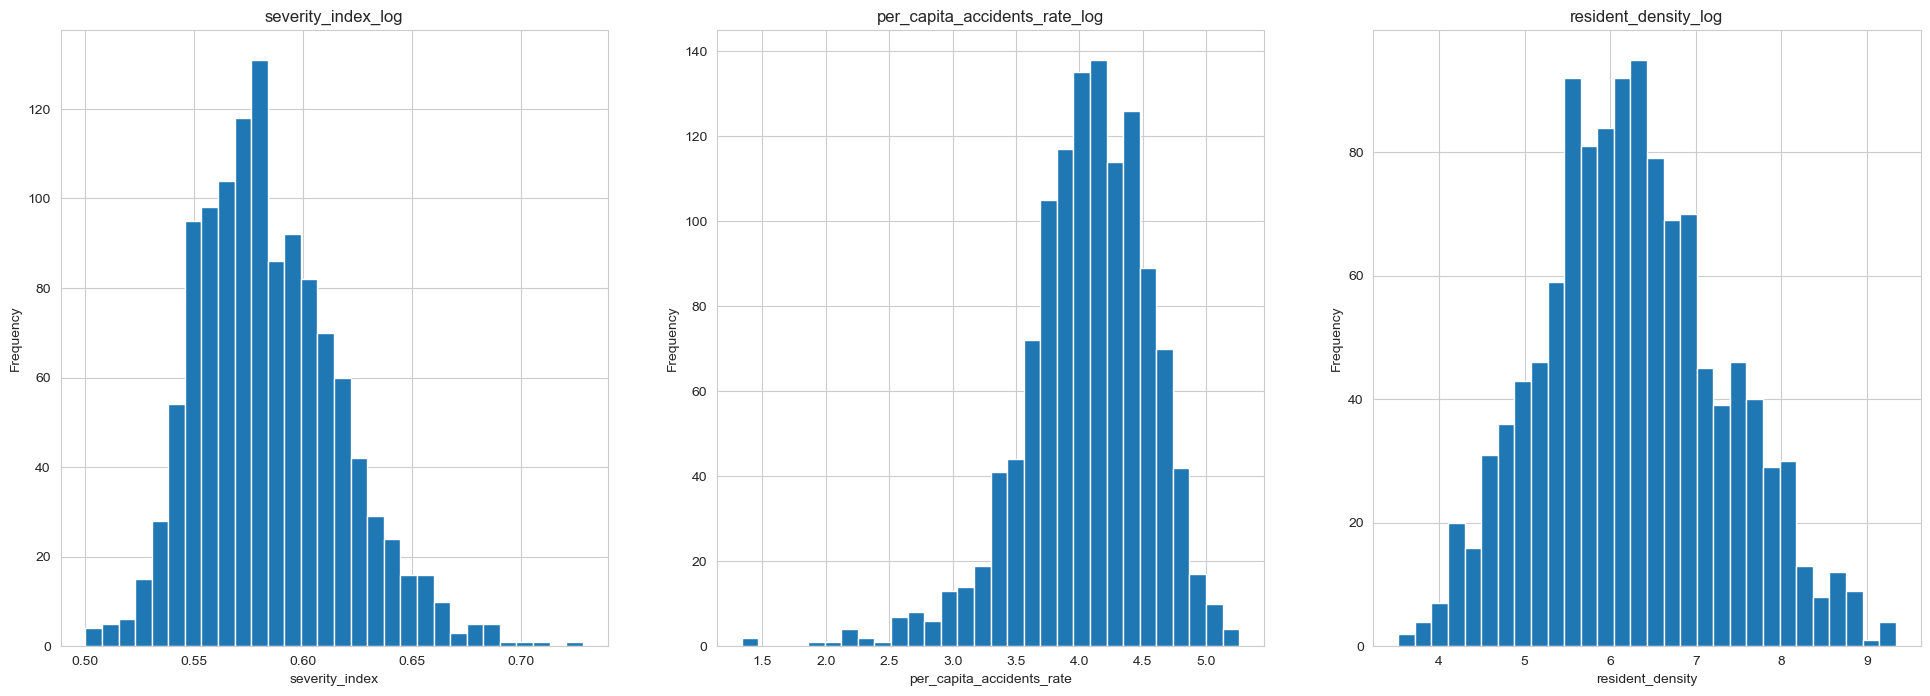

In [183]:
from sklearn.preprocessing import RobustScaler

work = df_2024.copy()

# log1p transform 
for col in FEATURES:
    if col in LOG_FEATURES:
        work[f'{col}_log'] = np.log1p(work[col].clip(lower=0))
    else:
        work[f'{col}_log'] = work[col]

model_cols = [f'{c}_log' for c in FEATURES]
scaler = RobustScaler()
X_scaled = scaler.fit_transform(work[model_cols])

fig, axes = plt.subplots(1, len(FEATURES), figsize=(8*len(FEATURES), 8))
for i, col in enumerate(FEATURES):
    axes[i].hist(work[f'{col}_log'], bins=30)
    axes[i].set_title(f'{col}_log')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')


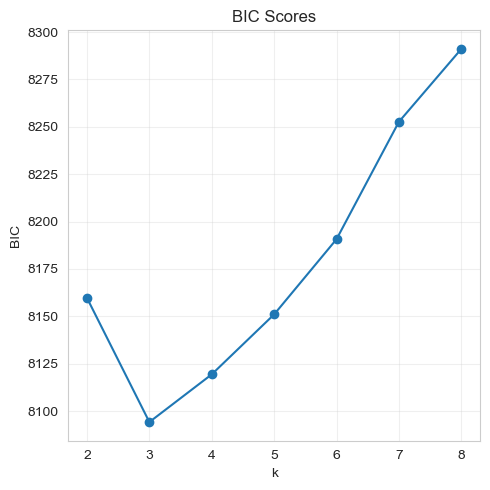

In [193]:
from sklearn.mixture import GaussianMixture


bic_scores, aic_scores = [], []
k_range = range(2, 9)
for k in k_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))

# plot bic-aic results
plt.figure(figsize=(5, 5))

plt.plot(k_range, bic_scores, marker='o')
plt.title('BIC Scores')
plt.xlabel('k')
plt.ylabel('BIC')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


According to the BIC results, k=4 is the better choice. However, let's do one more check to see if k=3 is actually the better choice. Let's check with a different covariance type.

In [194]:
work[['severity_index_log', 'per_capita_accidents_rate_log', 'resident_density_log']].corr()

type,severity_index_log,per_capita_accidents_rate_log,resident_density_log
type,,,
severity_index_log,1.000000,-0.018196,-0.343004
per_capita_accidents_rate_log,-0.018196,1.000000,-0.038363
resident_density_log,-0.343004,-0.038363,1.000000


In [189]:
k = 4

results = {}
for cov_type in ['full', 'diag', 'tied']:
    gmm = GaussianMixture(n_components=k, covariance_type=cov_type, random_state=42)
    gmm.fit(X_scaled)
    results[cov_type] = {'model': gmm, 'bic': gmm.bic(X_scaled), 'aic': gmm.aic(X_scaled)}
    print(f"{cov_type:6s} -> BIC: {results[cov_type]['bic']:.1f}, AIC: {results[cov_type]['aic']:.1f}")

# proceed with 'full' unless another covariance type gives a clearly lower BIC
gmm_final = results['full']['model']

full   -> BIC: 8119.4, AIC: 7920.8
diag   -> BIC: 8063.3, AIC: 7925.8
tied   -> BIC: 8144.3, AIC: 8037.4


In [192]:
work[['severity_index_log', 'per_capita_accidents_rate_log', 'resident_density_log']].corr()

type,severity_index_log,per_capita_accidents_rate_log,resident_density_log
type,,,
severity_index_log,1.000000,-0.018196,-0.343004
per_capita_accidents_rate_log,-0.018196,1.000000,-0.038363
resident_density_log,-0.343004,-0.038363,1.000000


diagonal has the lowest BIC value so we will stick with it

In [190]:
labels = gmm_final.predict(X_scaled)
probs = gmm_final.predict_proba(X_scaled)        
max_prob = probs.max(axis=1)

work['gmm_cluster'] = labels
work['gmm_confidence'] = max_prob
for i in range(k):
    work[f'gmm_prob_{i}'] = probs[:, i]

# how sharp vs. fuzzy is the 3-way split, in practice?
print("Confidence distribution (max posterior probability):")
print(work['gmm_confidence'].describe())

confident = (work['gmm_confidence'] > 0.8).sum()
fuzzy = (work['gmm_confidence'] < 0.6).sum()
print(f"\nConfidently assigned (>0.8): {confident} / {len(work)} "
      f"({confident/len(work)*100:.1f}%)")
print(f"Fuzzy/boundary cities (<0.6): {fuzzy} / {len(work)} "
      f"({fuzzy/len(work)*100:.1f}%)")

Confidence distribution (max posterior probability):
count    1202.000000
mean        0.681519
std         0.184022
min         0.313774
25%         0.519728
50%         0.683600
75%         0.844096
max         1.000000
Name: gmm_confidence, dtype: float64

Confidently assigned (>0.8): 382 / 1202 (31.8%)
Fuzzy/boundary cities (<0.6): 466 / 1202 (38.8%)


In [191]:
profile = (
    work
    .groupby('gmm_cluster')[FEATURES]
    .agg(['mean', 'median', 'count'])
)
print(profile)

print("\nCluster sizes:")
print(work['gmm_cluster'].value_counts().sort_index())

type        severity_index                 per_capita_accidents_rate  \
                      mean    median count                      mean   
gmm_cluster                                                            
0                 0.569000  0.571429   390                 56.308462   
1                 0.626159  0.619718   281                 64.284129   
2                 0.586438  0.583333   145                 27.915876   
3                 0.569515  0.570547   386                 83.140022   

type                         resident_density                     
                median count             mean       median count  
gmm_cluster                                                       
0            53.149498   390       396.062227   304.775336   390  
1            59.839289   281       376.679601   287.657642   281  
2            26.527544   145      2294.795943  1467.140546   145  
3            79.502349   386      1370.657556  1001.925246   386  

Cluster sizes:
gmm_cluste

/opt/miniconda3/envs/DA/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Axes: xlabel='umap_1', ylabel='umap_2'>

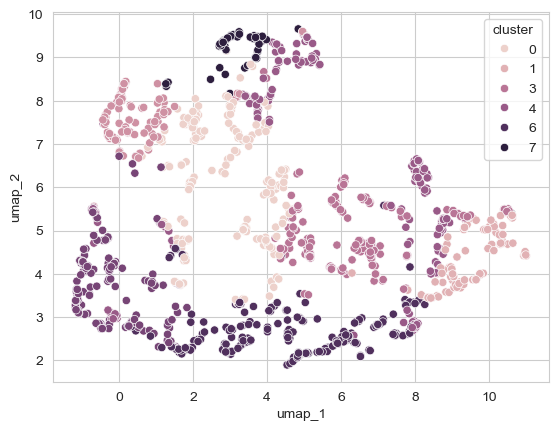

In [176]:
import umap

# K-means with 3 clusters
kmeans = KMeans(n_clusters=8, random_state=42)
work['cluster'] = kmeans.fit_predict(X_scaled)

# umap embedding
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.0, random_state=42)
embedding = reducer.fit_transform(X_scaled)

work[['umap_1', 'umap_2']] = embedding

sns.scatterplot(
    data=work,
    x = 'umap_1',
    y = 'umap_2',
    hue = 'cluster'
)

In [167]:
# cluster profile
work.groupby('cluster')[FEATURES].agg(['mean', 'median', 'count'])

type    severity_index                 per_capita_accidents_rate             \
                  mean    median count                      mean     median   
cluster                                                                       
0             0.568338  0.567568   475                 84.357727  79.599515   
1             0.615504  0.612403   397                 61.887327  58.634169   
2             0.570944  0.571429   330                 34.923641  37.073500   

type          resident_density                    
        count             mean      median count  
cluster                                           
0         475      1039.184947  697.958461   475  
1         397       295.566224  226.844435   397  
2         330      1549.023707  838.416898   330

So, how can we identify which cities to invest in? We have to work with the information the metrics give us, as well as other analytical methods. Since 2020 had a lower peak of accidents, we can use it as a starting point to see where exactly accidents increased and compare it to previous years.
1) **Composition score**: is a single data point that combines information from multiple variables. This help us to derive a single information on multiple different variables. In our case we will use it with the severity index and density collision, which tell us if we have an increase or not. We chose the severity index as the measure of how many serious accidents have occurred and collision density since they measure traffic volume. Accidents in a city aren't caused only by locals, but also by tourists, commercial transit, etc. Usually, a small city shouldn't have a lot of traffic, but if it does, that could be a sign of high traffic and, therefore, high risk.  
This will help us relocate the cities into different groups.
2) We calculte the **Z-Score** (https://www.geeksforgeeks.org/data-science/z-score-in-statistics/) which  measures how many standard deviations a data point lies away from the mean of a distribution. A score of 0 means the data point is exactly at the mean, positive Z-score indicates the data point is above the mean, negative Z-score indicates the data point is below the mean.  
In our case, we can calculate how many standard deviations a city's post-2020 average is above its three-year pre-Covid average (2016–2019). From the previous graphs, we saw that the general number of accidents decreased starting in 2001 and reached stability around 2015/2016. This proves whether a recent jump in accidents is just random annual fluctuation or a true structural increase.
3) Last we calculate the **Slope Regression** (Linear Regression) across the post Covid years. If the slope has a positive coefficient, it means there is an increase. If it is equal to zero, it means there are no changes. If it is negative, it indicates a decrease.

(Da rivedere in seguito)  
After that, to assist with our analysis, we can use machine learning clustering tools to identify which Italian cities have seen the greatest increase in accidents since the pandemic. To do this, we will use UMAP+HDBSCAN, allowing the algorithm to freely discover patterns that identify these relationships without manually imposing categories, something we would have had to do if we’d used K-Means, for example.  
To enhance HDBSCAN's performance, we first use UMAP (https://umap-learn.readthedocs.io/en/latest/parameters.html) to reduce our 8D feature space to 2D. Since HDBSCAN relies on spatial distances, UMAP helps preserve both local and global data structures before clustering begins.
Our logic uses the following four categories:
- **Escalating Hotspots:** High level, positive Delta (severe risk, actively worsening).
- **Stable:** High level, near-zero Delta (high background risk, but stable historically).
- **Emerging Risks:** Low level, positive Delta (post-lockdown accident surges).
- **Low Risk:** Low level, negative Delta (improved overall road safety).
In short, UMAP maintains the underlying structure of the data, while HDBSCAN performs the density-based cluster recognition.

In [25]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler

# defining the two time windows
PRE_START, PRE_END = 2016, 2019
POST_START, POST_END = 2021, 2024

In [24]:
def time_span_df(df, year1, year2):

    window = df[(df['Year'] >= year1) & (df['Year'] <= year2)]

    df_group = window.groupby('city_id').agg(
                                    # Take the latest string metadata to avoid duplicate rows
                                    city=('city', 'last'),
                                    province=('province', 'last'),
                                    region=('region', 'last'),
                                    # Aggregations
                                    mean_residents=('residents', 'mean'),
                                    mean_area_km2=('area (km2)', 'mean'),
                                    total_collisions=('collisions', 'sum'),
                                    total_fatalities=('fatalities', 'sum'),
                                    total_injuries=('injuries', 'sum'),
                                    total_accidents=('total_accidents', 'sum'),
                                    years_recorded=('year', 'count'),
                                ).reset_index()
    
    # 2) Harmful Accidents (M + F)
    df_group['harmful_accidents'] = df_group['total_fatalities'] + df_group['total_injuries']

    # 3) Severity Index (where condition to taking into account possible division by zero)
    df_group['severity_index'] = np.where(df_group['total_accidents'] > 0, df_group['harmful_accidents'] / df_group['total_accidents'], 0,)

    # 4) Fatality Rate
    df_group['fatality_rate'] = np.where(df_group['total_accidents'] > 0, df_group['total_fatalities'] / df_group['total_accidents'], 0,)

    # 5) Per-Capita Accidents Rate
    df_group['per_capita_accidents_rate'] = (df_group['total_accidents'] / df_group['mean_residents']) * 1e4

    # 6) Collision Density
    df_group['collision_density'] = df_group['total_accidents'] / df_group['mean_area_km2']

    return df_group

In [ ]:
# 1. -- Composition Score --

def calculate_composite_score(df_post, df_pre, growth_clip_pct=(1, 99)):

    merged = df_post.merge(
        df_pre[['city_id', 'total_accidents']],
        on='city_id', suffixes=('', '_pre'), how='inner'
    )
 
    pct_growth = (
        (merged['Total_Accidents'] / merged['Total_Accidents_pre'].replace(0, 1)) - 1
    ) * 100
 
    # Winsorize growth: caps the influence of tiny-baseline towns whose
    # % growth can be huge (e.g. 2 -> 6 accidents = +200%) and would
    # otherwise dominate the MinMax scaling for everyone else.
    lo, hi = np.percentile(pct_growth, growth_clip_pct)
    pct_growth_clipped = pct_growth.clip(lo, hi)
 
    density = merged['collision_density'].values
    severity = merged['severity_index'].values
 
    scaler = MinMaxScaler()
    scaled_matrix = scaler.fit_transform(
        np.column_stack([density, severity, pct_growth_clipped.values])
    )
 
    weights = np.array([0.4, 0.3, 0.3])  # density, severity, growth
    merged['composite_insurance_score'] = np.dot(scaled_matrix, weights)
    merged['pct_growth_raw'] = pct_growth.values
    merged['pct_growth_clipped'] = pct_growth_clipped.values
 
    return merged[['city_id', 'city', 'composite_insurance_score',
                    'pct_growth_raw', 'pct_growth_clipped',
                    'collision_density', 'severity_index']]



# 2. -- Z_Score --

def calculate_z_scores(df, pre_start=PRE_START, pre_end=PRE_END, post_start=POST_START, post_end=POST_END):
    # Separate Pre-2020 and Post-2020 datasets
    pre = df[(df['year'] >= pre_start) & (df['year'] <= pre_end)]
    post = df[(df['year'] >= post_start) & (df['year'] <= post_end)]

    # Calculate Historical Mean and Std Dev
    hist_stats = (
        pre.groupby(['city_id', 'city'])
        .agg(
            mu_accidents=('total_accidents', 'mean'),
            sigma_accidents=('total_accidents', 'std'),
            mu_severity=('severity_index', 'mean'),
            sigma_severity=('severity_index', 'std'),
            mu_fatal=('fatality_rate', 'mean'),
            sigma_fatal=('fatality_rate', 'std'),
        )
        .reset_index()
    )

    # Calculate Post-2020 Mean
    post_stats = (
        post.groupby(['city_id', 'city'])
        .agg(
            post_accidents=('total_accidents', 'mean'),
            post_severity=('severity_index', 'mean'),
            post_fatal=('fatality_rate', 'mean')
        )
        .reset_index()
    )

    # Merge and calculate Z-Scores
    z_df = pd.merge(hist_stats, post_stats, on=['city_id', 'city'], how='inner')

    # Avoid division by zero by replacing sigma=0 with 1
    z_df['z_accidents'] = (z_df['post_accidents'] - z_df['mu_accidents']) / z_df['sigma_accidents'].replace(0, 1)
    z_df['z_severity'] = (z_df['post_severity'] - z_df['mu_severity']) / z_df['sigma_severity'].replace(0, 1)
    z_df['z_fatal'] = (z_df['post_fatal'] - z_df['mu_fatal']) / z_df['sigma_fatal'].replace(0, 1)

    return z_df[['city_id', 'city', 'z_accidents', 'z_severity', 'z_fatal']]



# 3. -- Slope --

def _theil_sen_slope(years, values):
    """Robust slope: median of all pairwise slopes. Less sensitive to a
    single noisy year than OLS polyfit, useful with only 4 data points."""
    years = np.asarray(years, dtype=float)
    values = np.asarray(values, dtype=float)
    n = len(years)
    if n < 2:
        return 0.0
    slopes = []
    for i in range(n):
        for j in range(i + 1, n):
            dx = years[j] - years[i]
            if dx != 0:
                slopes.append((values[j] - values[i]) / dx)
    return float(np.median(slopes)) if slopes else 0.0
 
 
def calculate_slopes(df, df_pre_group, post_start=POST_START, post_end=POST_END,
                      method='theilsen'):
    """
    df: raw yearly dataframe (needs City_ID, Year, Total_Accidents)
    df_pre_group: output of build_group_metrics(df, PRE_START, PRE_END),
        used to normalize each city's slope by its own pre-covid baseline
        so slopes are comparable across city sizes.
 
    2020 is EXCLUDED (post_start defaults to 2021) so the covid dip does
    not mechanically inflate every city's rebound slope.
    """
    recent_df = df[(df['Year'] >= post_start) & (df['Year'] <= post_end)]
 
    baseline = df_pre_group.set_index('City_ID')['Total_Accidents'] / (PRE_END - PRE_START + 1)
    baseline = baseline.replace(0, np.nan)  # avoid dividing by a zero-accident baseline
 
    rows = []
    for city_id, group in recent_df.groupby('City_ID'):
        group = group.sort_values('Year')
        base = baseline.get(city_id, np.nan)
        if pd.isna(base) or len(group) < 2:
            slope_norm, slope_raw, r2 = np.nan, np.nan, np.nan
        else:
            if method == 'theilsen':
                slope_raw = _theil_sen_slope(group['Year'], group['Total_Accidents'])
            else:
                coeffs = np.polyfit(group['Year'], group['Total_Accidents'], 1)
                slope_raw = coeffs[0]
            slope_norm = slope_raw / base  # relative to own pre-covid yearly avg
 
            # R^2 of a simple linear fit, reported for QC even when using
            # Theil-Sen for the headline slope, so noisy 4-point fits can
            # be flagged/down-weighted rather than trusted blindly.
            if len(group) >= 3 and group['Year'].nunique() > 1:
                coeffs = np.polyfit(group['Year'], group['Total_Accidents'], 1)
                pred = np.polyval(coeffs, group['Year'])
                ss_res = np.sum((group['Total_Accidents'] - pred) ** 2)
                ss_tot = np.sum((group['Total_Accidents'] - group['Total_Accidents'].mean()) ** 2)
                r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
            else:
                r2 = np.nan
 
        rows.append({
            'City_ID': city_id,
            'Slope_Raw': slope_raw,
            'Slope_Normalized': slope_norm,  # e.g. +0.05 = +5%/yr vs pre-covid avg
            'Slope_R2': r2,
        })
 
    return pd.DataFrame(rows)


In [ ]:
"""# 1. -- Composition Score --

def calculate_composite_score(df_post, df_pre):

    # percentage growth
    density = df_post['Collision_Density'].values
    severity = df_post['Severity_index'].values
    pct_growth = ((df_post['Total_Accidents'].values / df_pre['Total_Accidents'].replace(0, 1).values) - 1) * 100

    # 2. Scale features between 0 and 1
    scaler = MinMaxScaler()
    scaled_matrix = scaler.fit_transform(np.column_stack([density, severity, pct_growth]))

    # 3. Calculate Weighted Sum (40% Density, 30% Severity, 30% Growth): standard used weights
    weights = np.array([0.4, 0.3, 0.3])
    Composite_Insurance_Score = np.dot(scaled_matrix, weights)

    return Composite_Insurance_Score



# 2. -- Z_Score --

def calculate_z_scores(df):
    # Separate Pre-2020 and Post-2020 datasets
    pre_2020 = df[(df['Year'] > 2015) & (df['Year'] < 2020)]
    post_2020 = df[df['Year'] > 2020]

    # Calculate Historical Mean and Std Dev
    hist_stats = (
        pre_2020.groupby(['City_ID', 'City'])
        .agg(
            mu_accidents=('Total_Accidents', 'mean'),
            sigma_accidents=('Total_Accidents', 'std'),
            mu_severity=('Severity_index', 'mean'),
            sigma_severity=('Severity_index', 'std'),
            mu_fatal=('Fatality_Rate', 'mean'),
            sigma_fatal=('Fatality_Rate', 'std')
        )
        .reset_index()
    )

    # Calculate Post-2020 Mean
    post_stats = (
        post_2020.groupby(['City_ID', 'City'])
        .agg(
            post_accidents=('Total_Accidents', 'mean'),
            post_severity=('Severity_index', 'mean'),
            post_fatal=('Fatality_Rate', 'mean')
        )
        .reset_index()
    )

    # Merge and calculate Z-Scores
    z_df = pd.merge(hist_stats, post_stats, on=['City_ID', 'City'])

    # Avoid division by zero by replacing sigma=0 with 1
    z_df['Z_Accidents'] = (z_df['post_accidents'] - z_df['mu_accidents']) / z_df['sigma_accidents'].replace(0, 1)
    z_df['Z_Severity'] = (z_df['post_severity'] - z_df['mu_severity']) / z_df['sigma_severity'].replace(0, 1)
    z_df['Z_Fatal'] = (z_df['post_fatal'] - z_df['mu_fatal']) / z_df['sigma_fatal'].replace(0, 1)

    z_df.set_index(['City_ID', 'City'])
    return z_df[['Z_Accidents', 'Z_Severity', 'Z_Fatal']].values



# 3. -- Slope --

def calculate_slopes(df):
    recent_df = df[df['Year'] > 2020]

    def get_slope(group):
        if len(group) < 2:
            return 0.0
        # Fits a 1st degree polynomial (line) -> Returns slope (m)
        return np.polyfit(group['Year'], group['Total_Accidents'], 1)[0]

    slopes = recent_df.groupby('City_ID').apply(get_slope).reset_index(name='Recent_Accident_Slope') 

    slopes.set_index('City_ID')
    return slopes['Recent_Accident_Slope'].values"""

In [ ]:
def time_span_df(df, year1, year2):

    window = df[(df['Year'] >= year1) & (df['Year'] <= year2)]

    df_group = window.groupby('City_ID').agg(
                                    # Take the latest string metadata to avoid duplicate rows
                                    City=('City', 'last'),
                                    Province=('Province', 'last'),
                                    Region=('Region', 'last'),
                                    # Aggregations
                                    mean_residents=('Residents', 'sum'),
                                    Mean_Area_km2=('Area (km2)', 'mean'),
                                    Total_Collisions=('Collisions', 'sum'),
                                    Total_Fatalities=('Fatalities', 'sum'),
                                    Total_Injuries=('Injuries', 'sum'),
                                    Total_Accidents=('Total_Accidents', 'sum'),
                                    Years_Recorded=('Year', 'count'),
                                ).reset_index()
    
    # 2) Harmful Accidents (M + F)
    df_group['Harmful_Accidents'] = df_group['Total_Fatalities'] + df_group['Total_Injuries']

    # 3) Severity Index (where condition to taking into account possible division by zero)
    df_group['Severity_index'] = np.where(df_group['Total_Accidents'] > 0, df_group['Harmful_Accidents'] / df_group['Total_Accidents'], 0,)

    # 4) Fatality Rate
    df_group['Fatality_Rate'] = np.where(df_group['Total_Accidents'] > 0, df_group['Total_Fatalities'] / df_group['Total_Accidents'], 0,)

    # 5) Per-Capita Accidents Rate
    df_group['Per_Capita_Accidents_Rate'] = (df_group['Total_Accidents'] / df_group['Sum_Residents']) * 1e4

    # 6) Collision Density
    df_group['Collision_Density'] = df_group['Total_Accidents'] / df_group['Mean_Area_km2']

    return df_group

In [28]:
# divide in pre and post covid and group by
df_post_temp = time_span_df(df_filtered, 2021, 2024)
df_pre_temp = time_span_df(df_filtered, 2015, 2019)
# selectiong only city that are present in both datasets
df_cities = set(df_post_temp['City_ID']).intersection(set(df_pre_temp['City_ID']))

df_pre = df_pre_temp[df_pre_temp['City_ID'].isin(df_cities)]
df_post = df_post_temp[df_post_temp['City_ID'].isin(df_cities)]

print(f"Number of cities in pre-covid dataset: {df_pre.shape[0]}")
print(f"Number of cities in post-covid dataset: {df_post.shape[0]}")

Number of cities in pre-covid dataset: 1202
Number of cities in post-covid dataset: 1202


In [29]:
df_post_ind = df_filtered['City_ID'].isin(df_post['City_ID'].unique())

df_post['Composition_Score'] = calculate_composite_score(df_post, df_pre)
# Z-Scores
df_post[['Z_Accidents', 'Z_Severity', 'Z_Fatality']] = calculate_z_scores(df_filtered[df_post_ind])
# slope
df_post['Recent_Accident_Slope'] = calculate_slopes(df_filtered[df_post_ind])
df_post

/var/folders/g8/zc16hv7s1cjgwvmrs6kxv4240000gn/T/ipykernel_57450/1625567112.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_post['Composition_Score'] = calculate_composite_score(df_post, df_pre)
/var/folders/g8/zc16hv7s1cjgwvmrs6kxv4240000gn/T/ipykernel_57450/1625567112.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_post[['Z_Accidents', 'Z_Severity', 'Z_Fatality']] = calculate_z_scores(df_filtered[df_post_ind])
/var/folders/g8/zc16hv7s1cjgwvmrs6kxv4240000gn/T/ipykernel_57450/1625567112.py:5: 

,City_ID,City,Province,Region,Sum_Residents,Mean_Area_km2,Total_Collisions,Total_Fatalities,Total_Injuries,Total_Accidents,...,Harmful_Accidents,Severity_index,Fatality_Rate,Per_Capita_Accidents_Rate,Collision_Density,Composition_Score,Z_Accidents,Z_Severity,Z_Fatality,Recent_Accident_Slope
0,1008,Alpignano,TO,Piemonte,66060.0,11.9193,100.0,1.0,137.0,238.0,...,138.0,0.579832,0.004202,36.027853,19.967616,0.154222,-1.049941,-0.461095,-0.250958,-1.0
1,1013,Avigliana,TO,Piemonte,49047.0,23.2173,133.0,2.0,183.0,318.0,...,185.0,0.581761,0.006289,64.835770,13.696683,0.158702,-0.884919,-0.182045,-0.417258,7.9
2,1024,Beinasco,TO,Piemonte,69646.0,6.7366,114.0,1.0,143.0,258.0,...,144.0,0.558140,0.003876,37.044482,38.298251,0.125380,-2.536619,-2.385767,-0.489151,1.3
3,1028,Borgaro Torinese,TO,Piemonte,46957.0,11.1093,64.0,2.0,89.0,155.0,...,91.0,0.587097,0.012903,33.008923,13.952274,0.160265,-0.664268,-0.092205,0.393260,0.8
4,1059,Carmagnola,TO,Piemonte,112717.0,95.7163,258.0,7.0,365.0,630.0,...,372.0,0.590476,0.011111,55.892190,6.581951,0.163840,-0.030911,-0.549371,-0.264353,13.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,111009,Carbonia,SU,Sardegna,104468.0,145.5410,193.0,14.0,324.0,531.0,...,338.0,0.636535,0.026365,50.828962,3.648456,0.248146,-2.976857,-0.279360,1.605345,20.7
1209,111034,Guspini,SU,Sardegna,43695.0,174.6685,73.0,9.0,110.0,192.0,...,119.0,0.619792,0.046875,43.940954,1.099225,0.237541,0.157243,-0.283761,2.332059,1.4
1210,111035,Iglesias,SU,Sardegna,100078.0,208.2296,164.0,6.0,224.0,394.0,...,230.0,0.583756,0.015228,39.369292,1.892142,0.152821,-1.527494,-4.341398,0.523295,5.3
1211,111071,Sant'Antioco,SU,Sardegna,42515.0,88.0162,49.0,3.0,79.0,131.0,...,82.0,0.625954,0.022901,30.812654,1.488362,0.287226,1.678571,-0.010813,0.019720,4.1


In [30]:
print(df_post.isna().sum())

City_ID                      0
City                         0
Province                     0
Region                       0
Sum_Residents                0
Mean_Area_km2                0
Total_Collisions             0
Total_Fatalities             0
Total_Injuries               0
Total_Accidents              0
Years_Recorded               0
Harmful_Accidents            0
Severity_index               0
Fatality_Rate                0
Per_Capita_Accidents_Rate    0
Collision_Density            0
Composition_Score            0
Z_Accidents                  7
Z_Severity                   7
Z_Fatality                   7
Recent_Accident_Slope        0
dtype: int64


In [31]:
df_post[df_post.isna().any(axis=1)]

,City_ID,City,Province,Region,Sum_Residents,Mean_Area_km2,Total_Collisions,Total_Fatalities,Total_Injuries,Total_Accidents,...,Harmful_Accidents,Severity_index,Fatality_Rate,Per_Capita_Accidents_Rate,Collision_Density,Composition_Score,Z_Accidents,Z_Severity,Z_Fatality,Recent_Accident_Slope
240,20057,San Giorgio Bigarello,MN,Lombardia,47369.0,51.5351,115.0,2.0,174.0,291.0,...,176.0,0.604811,0.006873,61.432582,5.646637,0.356965,NaN,NaN,NaN,6.4
265,23052,Negrar di Valpolicella,VR,Veneto,66226.0,40.4501,97.0,3.0,119.0,219.0,...,122.0,0.557078,0.013699,33.068583,5.414078,0.104546,NaN,NaN,NaN,-0.3
266,23055,Oppeano,VR,Veneto,41225.0,46.7256,115.0,5.0,160.0,280.0,...,165.0,0.589286,0.017857,67.919951,5.992432,0.363876,NaN,NaN,NaN,9.0
307,25074,Borgo Valbelluna,BL,Veneto,53937.0,167.6917,85.0,5.0,119.0,209.0,...,124.0,0.593301,0.023923,38.748911,1.246335,0.312645,NaN,NaN,NaN,0.7
417,34051,Sorbolo Mezzani,PR,Emilia-Romagna,51562.0,66.9713,76.0,2.0,99.0,177.0,...,101.0,0.570621,0.011299,34.327606,2.642923,0.385390,NaN,NaN,NaN,4.4
571,48054,Barberino Tavarnelle,FI,Toscana,47725.0,122.9906,181.0,0.0,232.0,413.0,...,232.0,0.561743,0.000000,86.537454,3.357980,0.360618,NaN,NaN,NaN,6.1
1140,96088,Valdilana,BI,Piemonte,30377.0,61.1378,41.0,1.0,56.0,98.0,...,57.0,0.581633,0.010204,32.261250,1.602936,0.341844,NaN,NaN,NaN,-0.7


array([[<Axes: title={'center': 'Per_Capita_Accidents_Rate'}>,
        <Axes: title={'center': 'Composition_Score'}>],
       [<Axes: title={'center': 'Z_Accidents'}>,
        <Axes: title={'center': 'Z_Severity'}>],
       [<Axes: title={'center': 'Z_Fatality'}>,
        <Axes: title={'center': 'Recent_Accident_Slope'}>]], dtype=object)

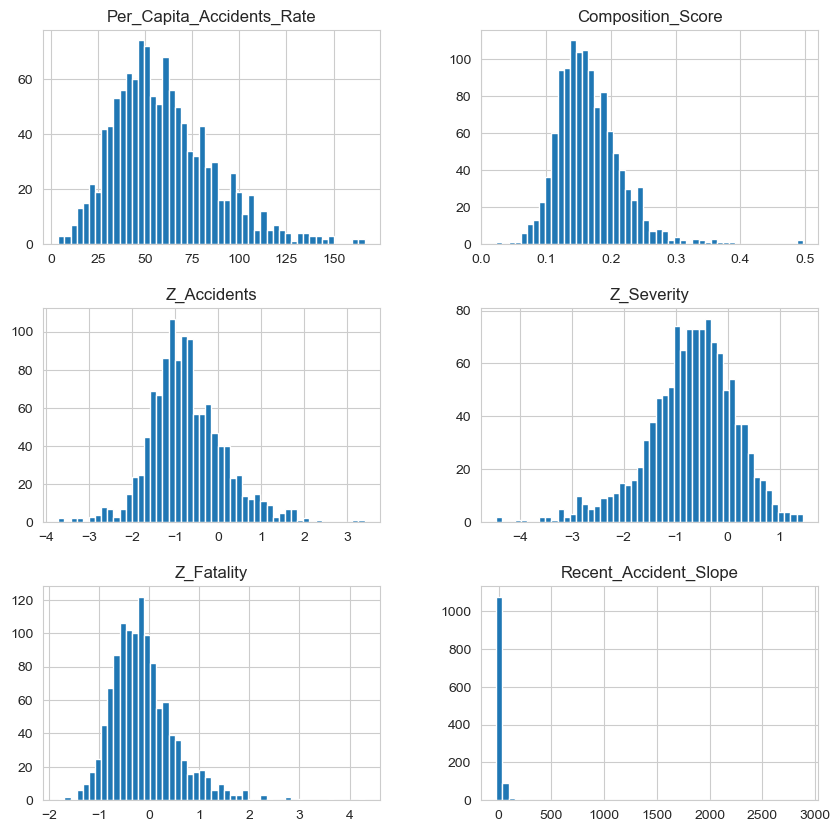

In [32]:
clustering_cols = [
    'Per_Capita_Accidents_Rate',
    'Composition_Score',
    'Z_Accidents',
    'Z_Severity',
    'Z_Fatality',
    'Recent_Accident_Slope',
]

df_post[clustering_cols].hist(figsize=(10, 10), bins=50)

In [33]:
df_post['Recent_Accident_Slope'].describe()

count    1202.000000
mean       20.254647
std        99.295448
min       -21.100000
25%         2.600000
50%         7.500000
75%        17.200000
max      2882.000000
Name: Recent_Accident_Slope, dtype: float64

array([[<Axes: title={'center': 'Per_Capita_Accidents_Rate'}>,
        <Axes: title={'center': 'Severity_index'}>,
        <Axes: title={'center': 'Collision_Density'}>],
       [<Axes: title={'center': 'Fatality_Rate'}>,
        <Axes: title={'center': 'Composition_Score'}>,
        <Axes: title={'center': 'Z_Accidents'}>],
       [<Axes: title={'center': 'Z_Severity'}>,
        <Axes: title={'center': 'Z_Fatality'}>,
        <Axes: title={'center': 'Recent_Accident_Slope'}>]], dtype=object)

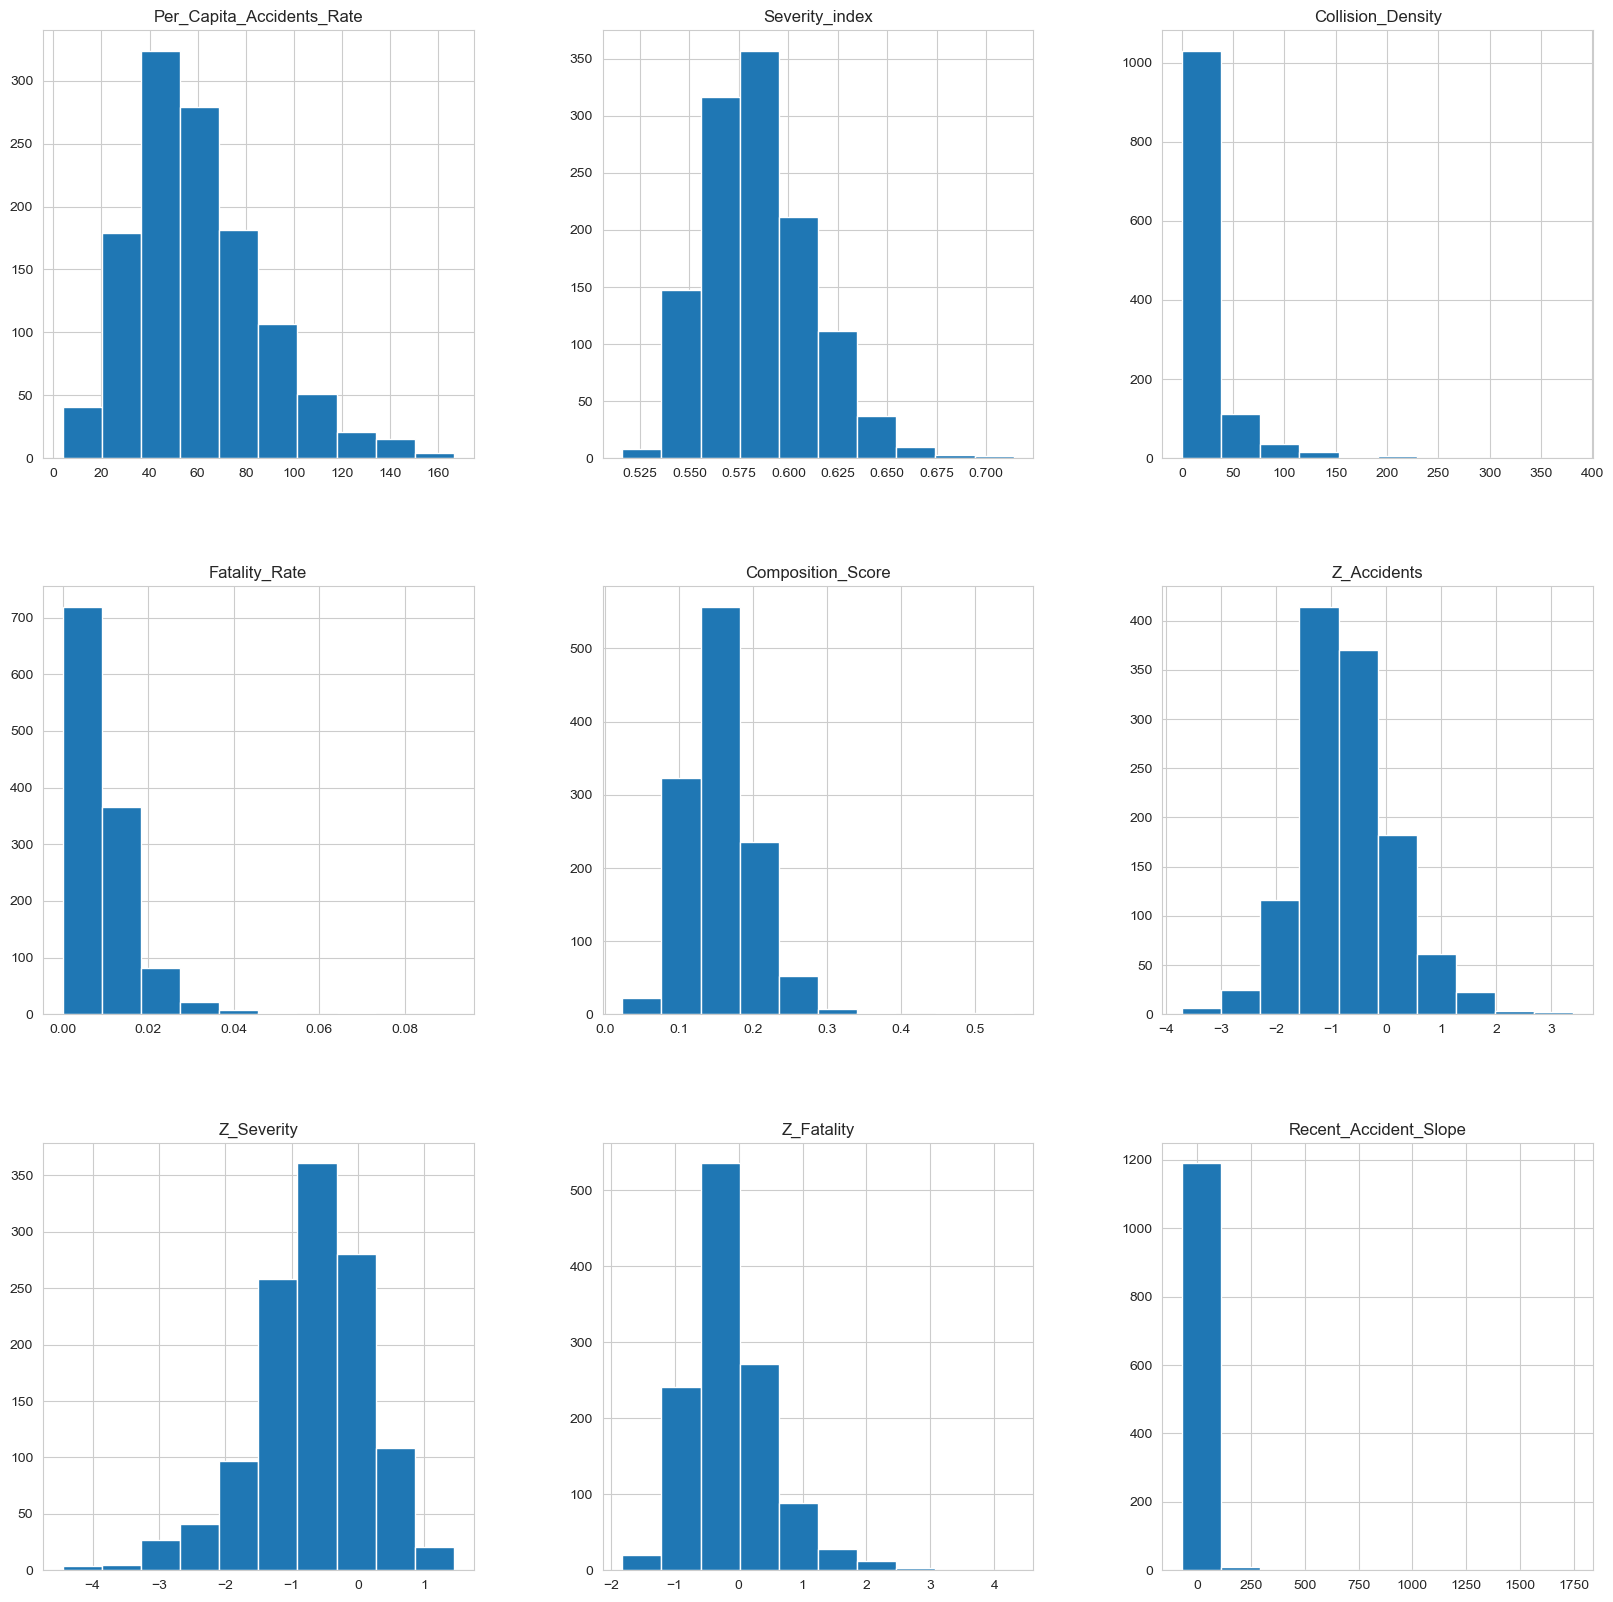

In [115]:
import umap
from sklearn.cluster import HDBSCAN 
# ---------------------------------------------------------
# UMAP and HDBSCAN

features_df = df_post.copy()
features_df = features_df.fillna(0)

clustering_cols = [
    'Per_Capita_Accidents_Rate',
    'Severity_index',
    'Collision_Density',
    'Fatality_Rate',
    'Composition_Score',
    'Z_Accidents',
    'Z_Severity',
    'Z_Fatality',
    'Recent_Accident_Slope',
]


features_df[clustering_cols].hist(figsize=(20, 20))

In [116]:
from sklearn.preprocessing import PowerTransformer
X = features_df[clustering_cols]
#X_scaled = RobustScaler().fit_transform(X)
# 2. Apply PowerTransformer (Yeo-Johnson)
pt = PowerTransformer(method='yeo-johnson')
X_scaled = pt.fit_transform(X)

# UMAP Projection
reducer = umap.UMAP(n_neighbors=15, min_dist=0.0, random_state=42)
embedding = reducer.fit_transform(X_scaled)


features_df['UMAP_1'] = embedding[:, 0]
features_df['UMAP_2'] = embedding[:, 1]

# HDBSCAN Clustering
clusterer = HDBSCAN(
    min_cluster_size=15,  # Minimum number of cities to form a cluster
    min_samples=5,  # Higher values increase noise tolerance
    cluster_selection_epsilon=0.5,
    cluster_selection_method='leaf',
    metric='euclidean',
)
features_df['cluster'] = clusterer.fit_predict(embedding)

# ---------------------------------------------------------
# STEP 3: Insurance Risk Category Mapping
# ---------------------------------------------------------
# Group by cluster to analyze average risk characteristics
cluster_summary = features_df.groupby('cluster')[
    ['Per_Capita_Accidents_Rate', 'Severity_index', 'Z_Accidents', 'Z_Severity', 'Z_Fatality', 'Recent_Accident_Slope']
].mean()

print("--- Cluster Profiles Summary ---")
print(features_df['cluster'].value_counts())
print(cluster_summary)

/opt/miniconda3/envs/DA/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


--- Cluster Profiles Summary ---
cluster
 0    876
 1    259
-1     67
Name: count, dtype: int64
         Per_Capita_Accidents_Rate  Severity_index  Z_Accidents  Z_Severity  \
cluster                                                                       
-1                       60.633403        0.587379    -0.857136   -0.524982   
 0                       62.119995        0.587599    -0.600538   -0.718089   
 1                       52.944032        0.575627    -1.091719   -0.688594   

         Z_Fatality  Recent_Accident_Slope  
cluster                                     
-1         0.277115               6.325373  
 0        -0.275356              14.010388  
 1         0.335891              -0.425869  


array([[<Axes: title={'center': 'Per_Capita_Accidents_Rate'}>,
        <Axes: title={'center': 'Severity_index'}>,
        <Axes: title={'center': 'Collision_Density'}>],
       [<Axes: title={'center': 'Fatality_Rate'}>,
        <Axes: title={'center': 'Composition_Score'}>,
        <Axes: title={'center': 'Z_Accidents'}>],
       [<Axes: title={'center': 'Z_Severity'}>,
        <Axes: title={'center': 'Z_Fatality'}>,
        <Axes: title={'center': 'Recent_Accident_Slope'}>]], dtype=object)

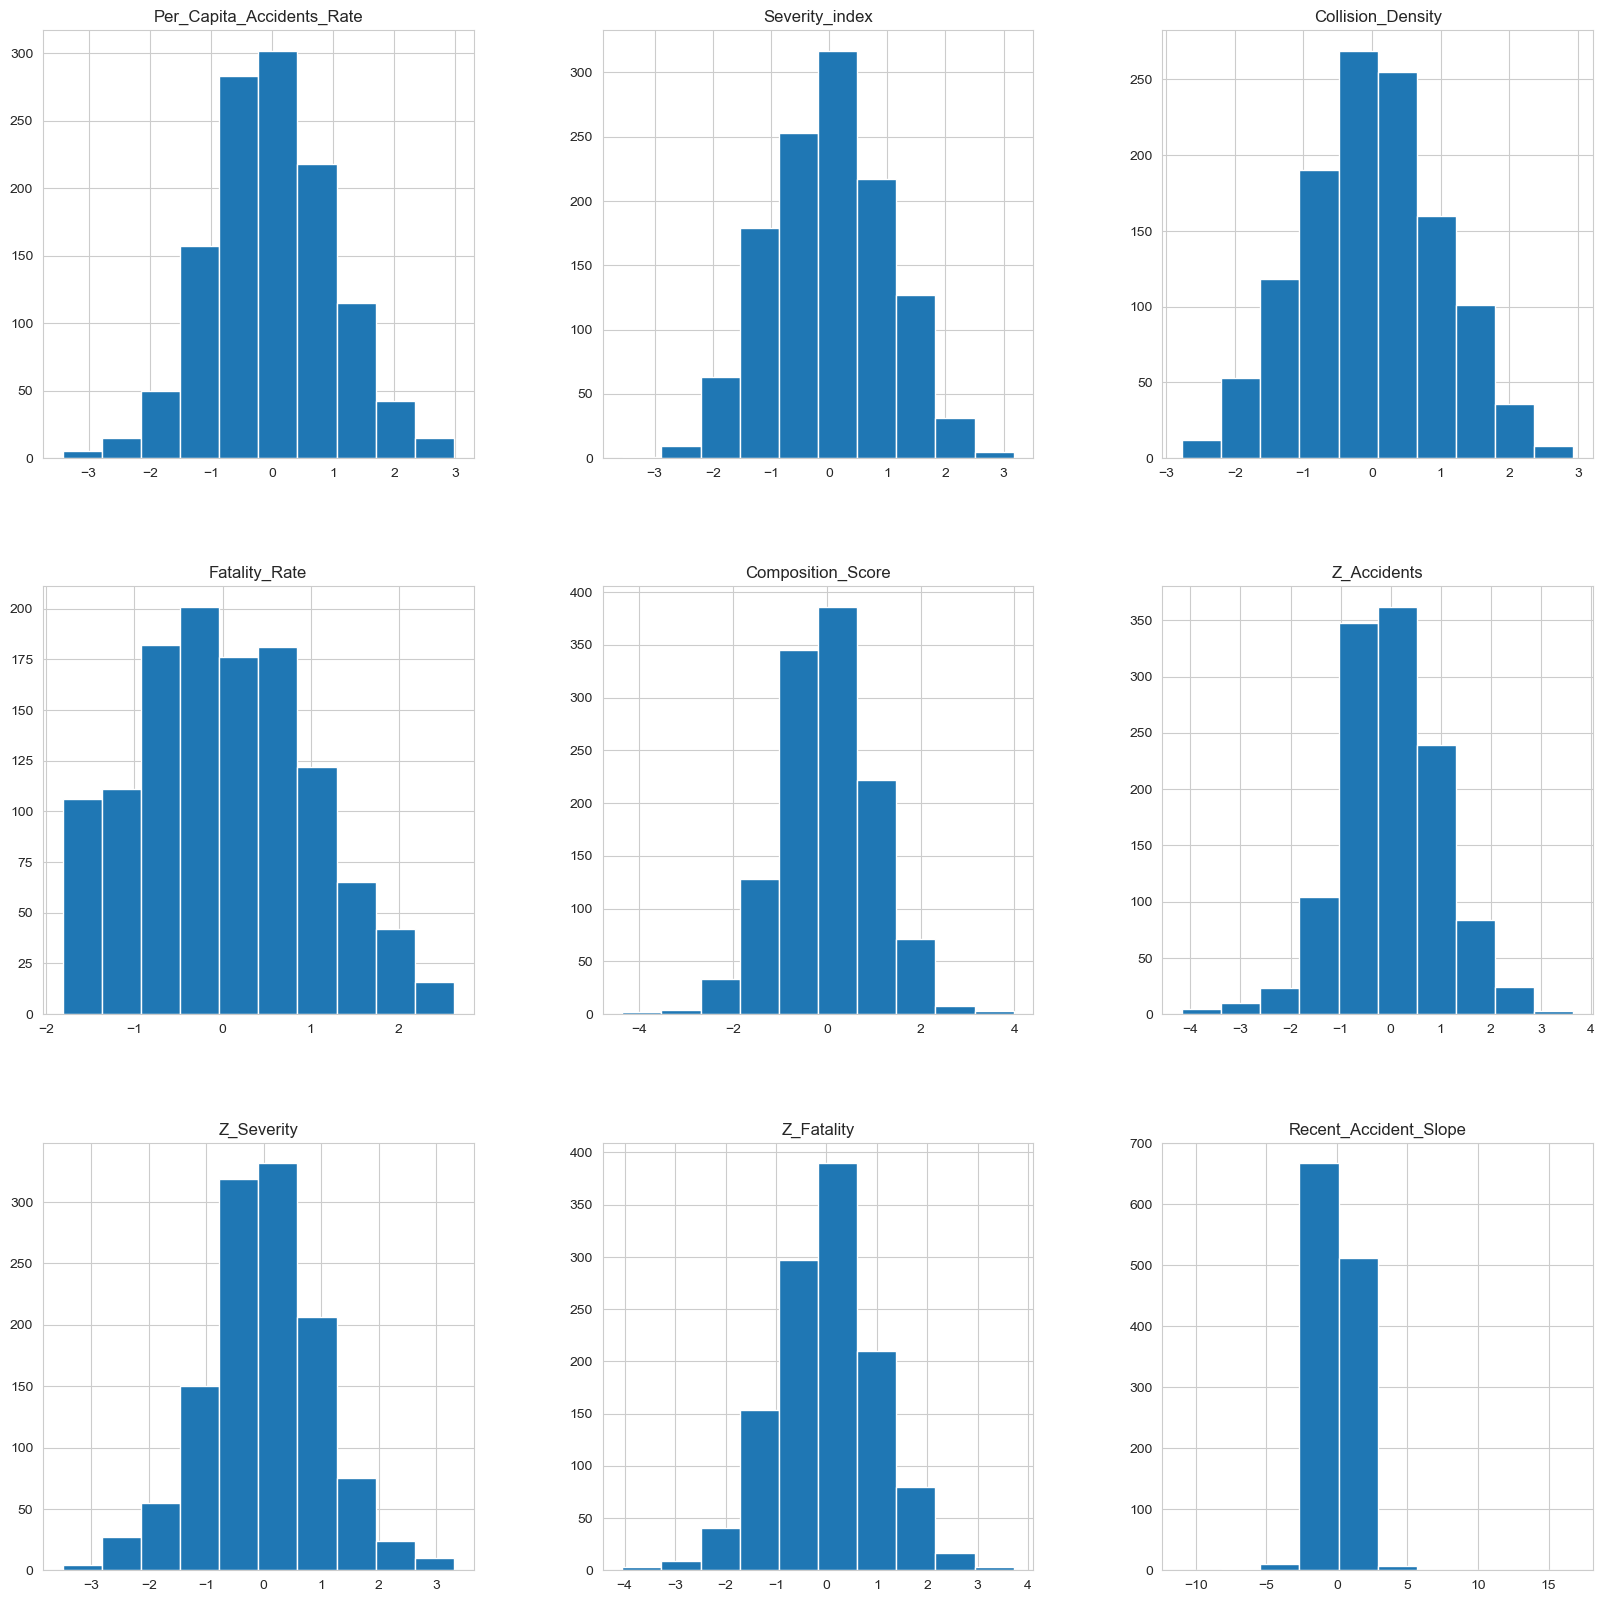

In [117]:
X_scaled_df = pd.DataFrame(
    X_scaled, columns=clustering_cols, index=X.index
)

X_scaled_df[clustering_cols].hist(figsize=(20, 20))

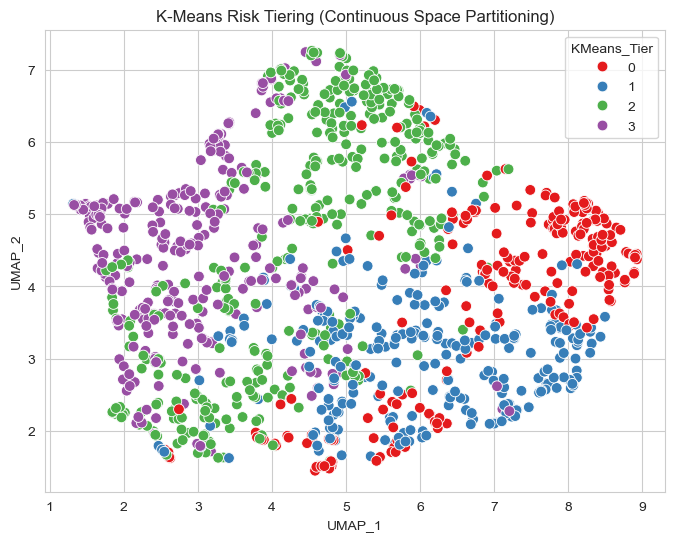

In [118]:
from sklearn.cluster import KMeans

# Run K-Means directly on your PowerTransformed features (X_transformed)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
features_df['KMeans_Tier'] = kmeans.fit_predict(X_scaled_df[['Severity_index', 'Z_Accidents', 'Collision_Density', 'Recent_Accident_Slope']].values)

# Plot on your UMAP coordinates to see clean geometric partitions
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=features_df,
    x='UMAP_1',
    y='UMAP_2',
    hue='KMeans_Tier',
    palette='Set1',
    s=60,
)
plt.title('K-Means Risk Tiering (Continuous Space Partitioning)')
plt.show()

<Axes: xlabel='UMAP_1', ylabel='UMAP_2'>

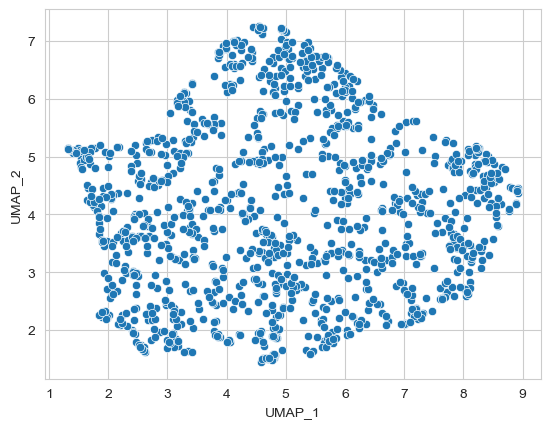

In [103]:
sns.scatterplot(data=features_df, x='UMAP_1', y='UMAP_2')

In [85]:
def plot_umap_clusters(df):
    # Scatter plot of UMAP coordinates colored by HDBSCAN clusters

    unique_clusters = sorted(df['cluster'].unique())

    # Generate 20 distinct colors using 'tab20'
    tab20_colors = sns.color_palette("tab20", n_colors=len(unique_clusters))
    color_dict = {
        cluster: color for cluster, color in zip(unique_clusters, tab20_colors)
    }
    color_dict[-1] = (0.35, 0.35, 0.35)  # Dark Gray for Noise

    # 3. Map markers: 'X' for Noise (-1), 'o' for all real clusters
    marker_dict = {
        cluster: 'X' if cluster == -1 else 'o' for cluster in unique_clusters
    }

    scatter = sns.scatterplot(
        data=df,
        x='UMAP_1',
        y='UMAP_2',
        hue='cluster',
        palette=color_dict,
        style='cluster',    # Distinguish noise
        markers=marker_dict,        # Noise -> X, Normal -> o
        s=60,
        alpha=0.8,
    )

    plt.title(
        'UMAP + HDBSCAN Risk Profile Clusters',
        fontsize=14,
        fontweight='bold',
    )
    plt.xlabel('UMAP Dimension 1', fontsize=11)
    plt.ylabel('UMAP Dimension 2', fontsize=11)
    plt.legend(title='Cluster ID (-1 = Noise)', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    return color_dict

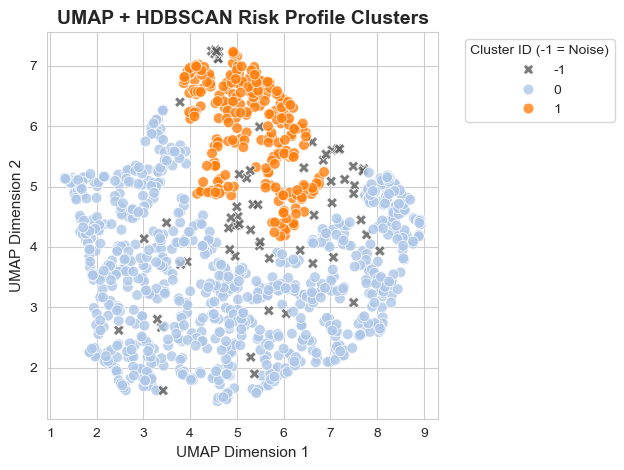

In [105]:
color_dict = plot_umap_clusters(features_df)

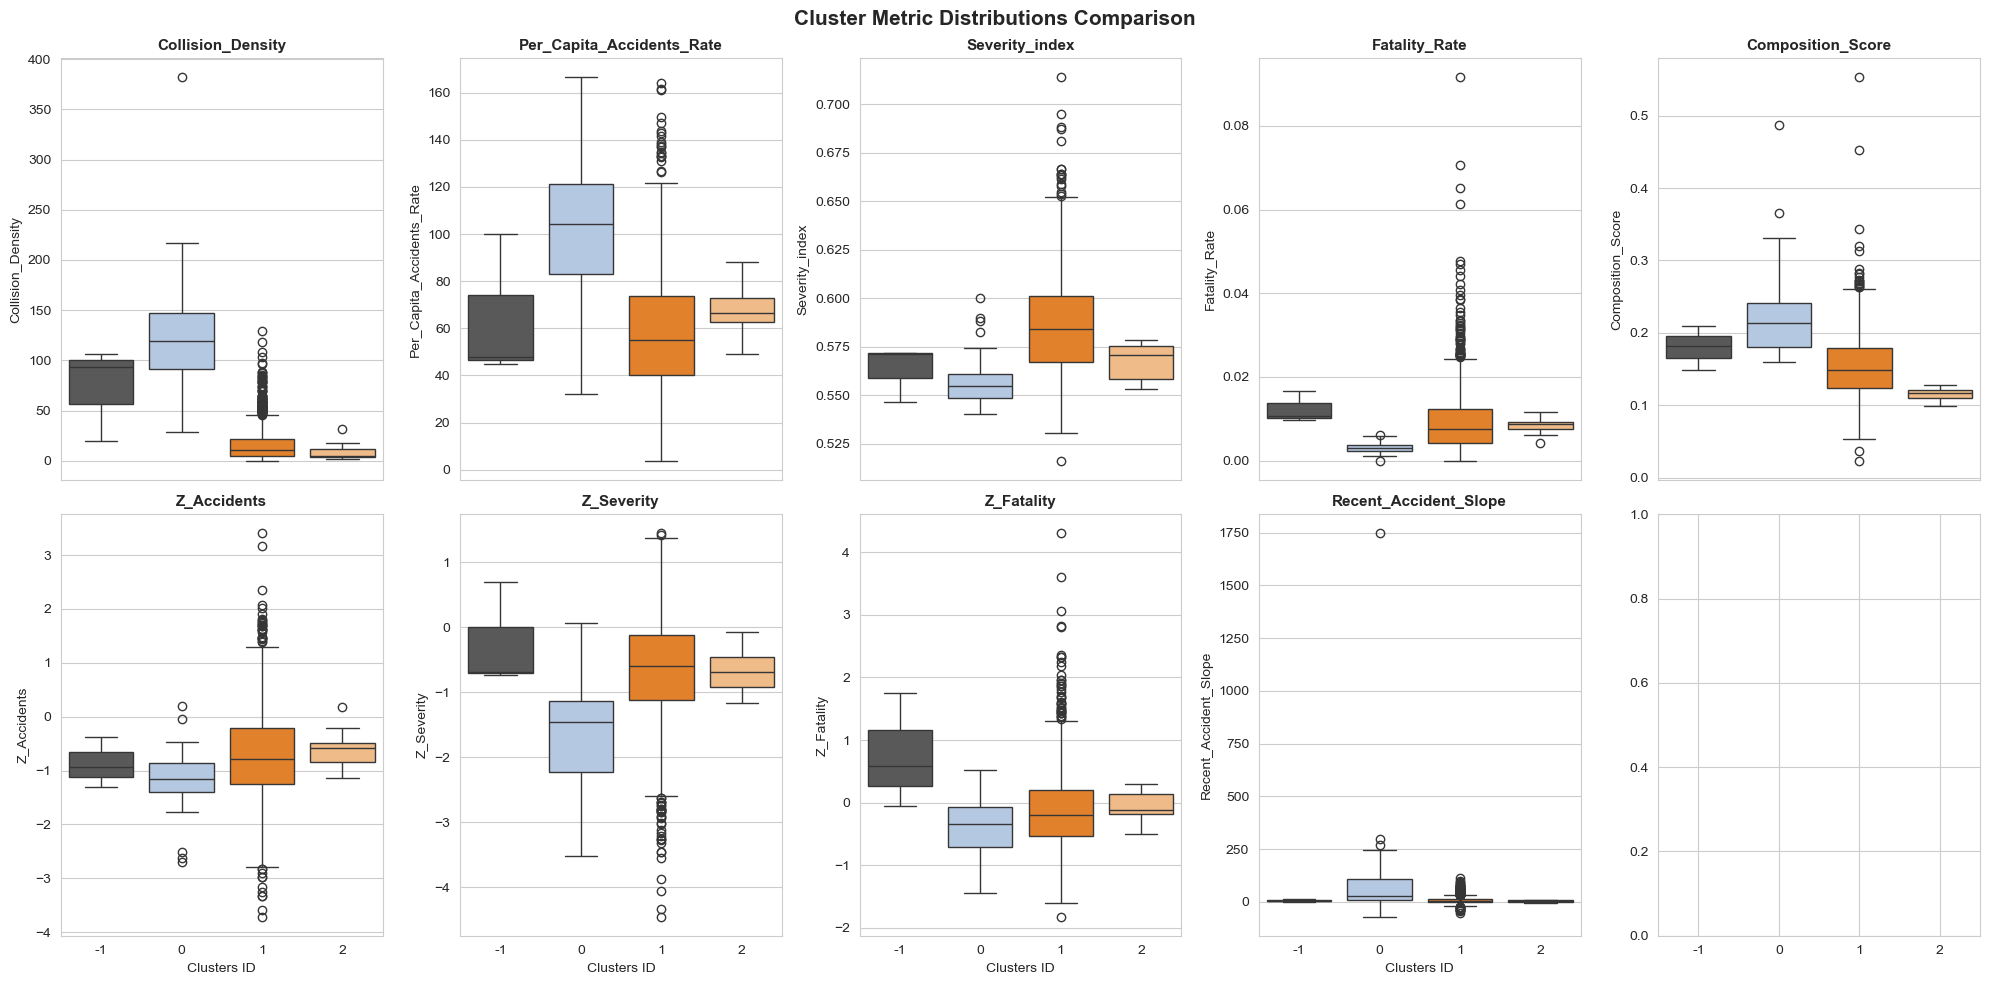

In [87]:
def plot_boxplots_metrics(df, metrics,target_clusters = None):

    if target_clusters is None:
        target_clusters = df['cluster'].unique()

    fig, axes = plt.subplots(2, 5, figsize=(20, 10), sharex=True)
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        sns.boxplot(
            data=df[df['cluster'].isin(target_clusters)],
            x='cluster',
            y=metric,
            ax=axes[i],
            hue='cluster',
            palette=color_dict,
            legend=False,
        )
        axes[i].set_title(metric, fontsize=11, fontweight='bold')
        axes[i].set_xlabel('Clusters ID')


    plt.suptitle('Cluster Metric Distributions Comparison', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_boxplots_metrics(features_df, clustering_cols)

array([[<Axes: title={'center': 'City_ID'}>,
        <Axes: title={'center': 'Sum_Residents'}>,
        <Axes: title={'center': 'Mean_Area_km2'}>,
        <Axes: title={'center': 'Total_Collisions'}>,
        <Axes: title={'center': 'Total_Fatalities'}>],
       [<Axes: title={'center': 'Total_Injuries'}>,
        <Axes: title={'center': 'Total_Accidents'}>,
        <Axes: title={'center': 'Years_Recorded'}>,
        <Axes: title={'center': 'Harmful_Accidents'}>,
        <Axes: title={'center': 'Severity_index'}>],
       [<Axes: title={'center': 'Fatality_Rate'}>,
        <Axes: title={'center': 'Per_Capita_Accidents_Rate'}>,
        <Axes: title={'center': 'Collision_Density'}>,
        <Axes: title={'center': 'Composition_Score'}>,
        <Axes: title={'center': 'Z_Accidents'}>],
       [<Axes: title={'center': 'Z_Severity'}>,
        <Axes: title={'center': 'Z_Fatality'}>,
        <Axes: title={'center': 'Recent_Accident_Slope'}>,
        <Axes: title={'center': 'UMAP_1'}>,
      

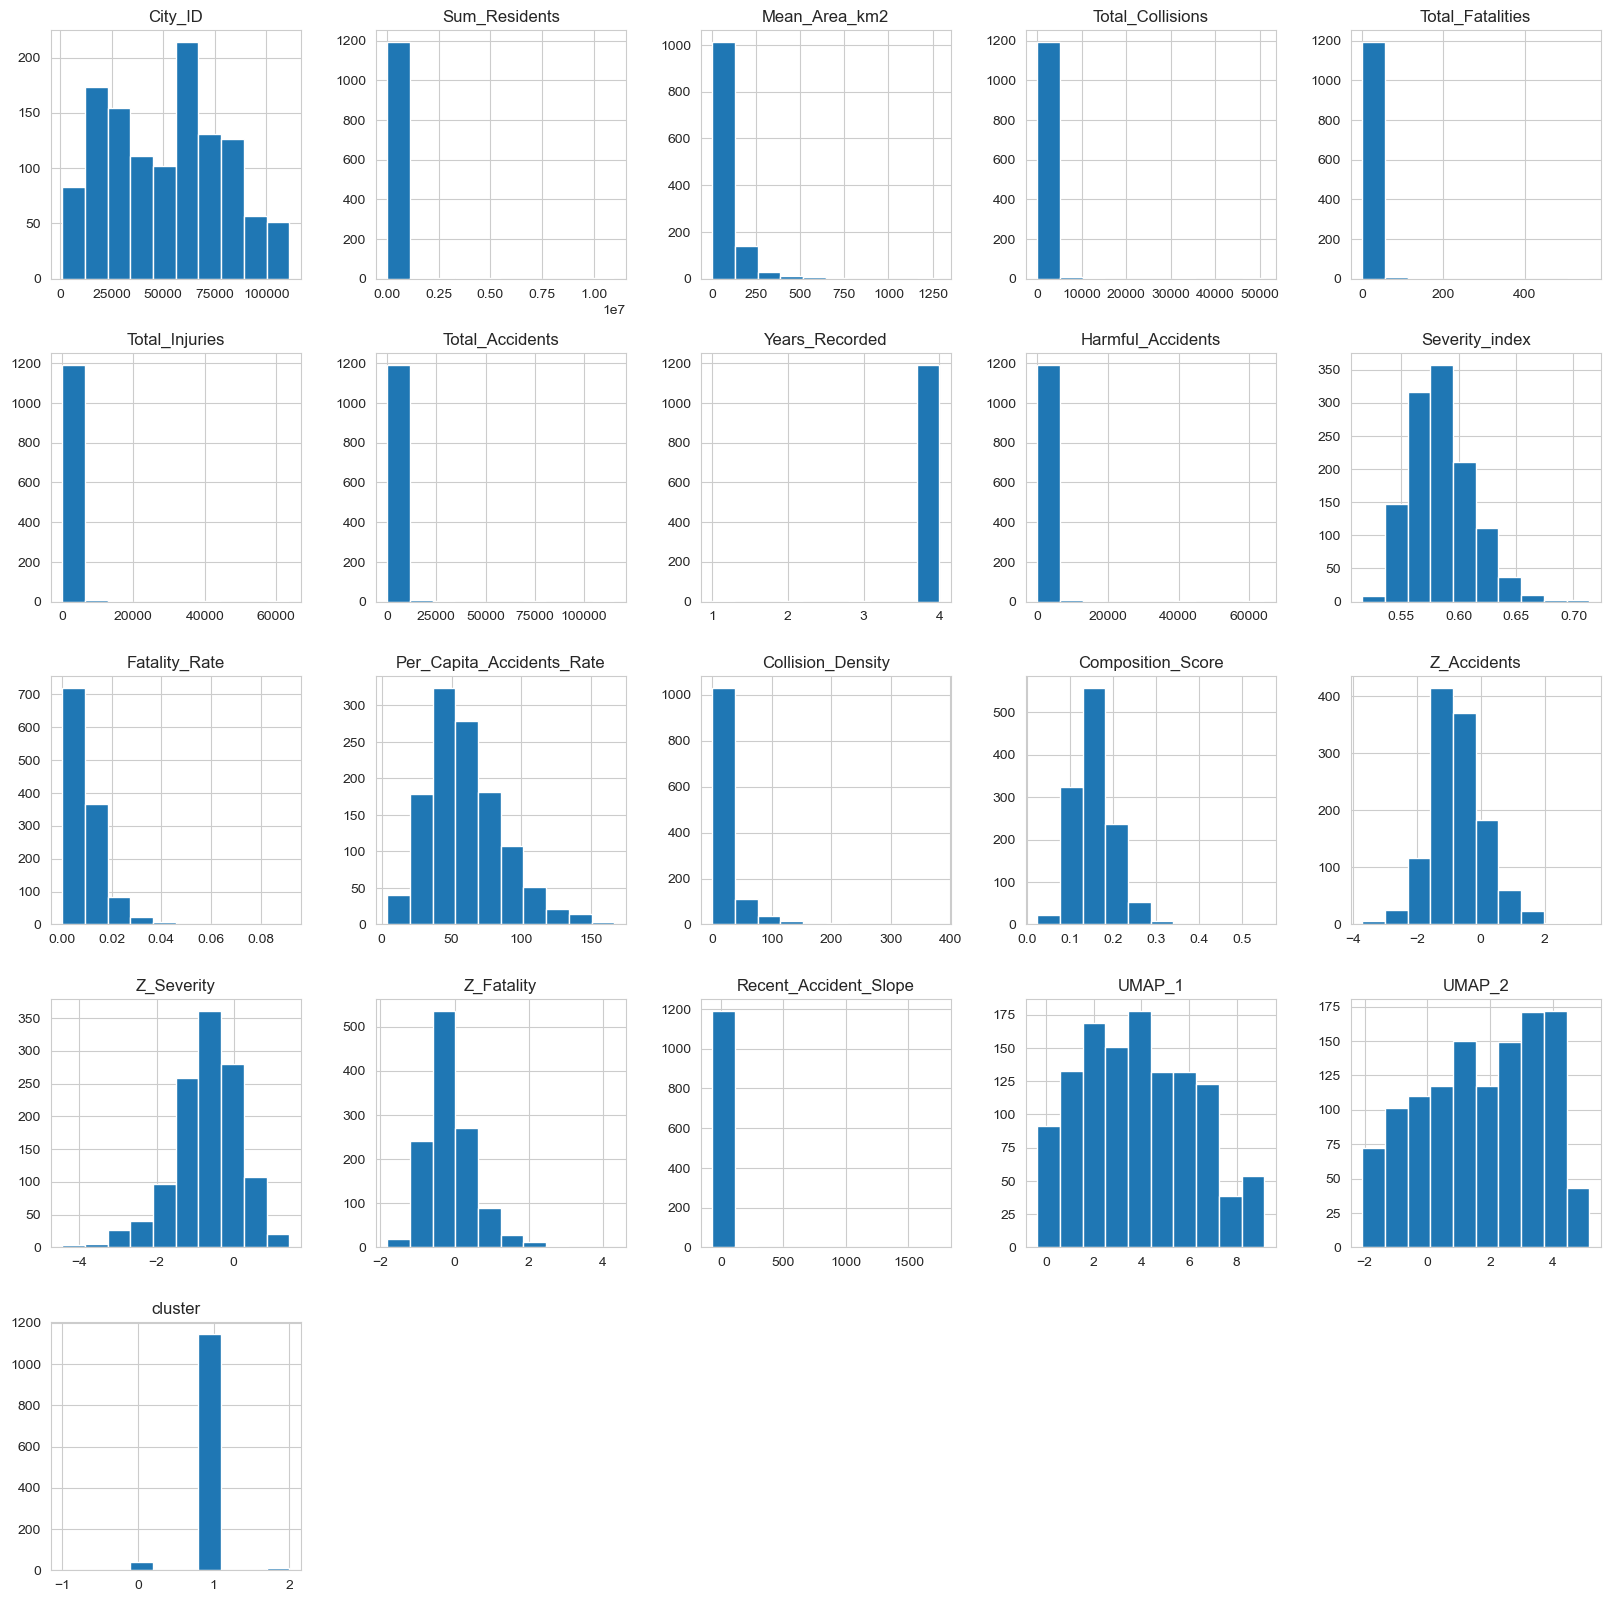

In [88]:
features_df.hist(figsize=(20, 20))

## IDENTIFICATION 2

To assist with our analysis, we can use machine learning clustering tools to identify which Italian cities have seen the greatest increase in accidents since the pandemic. To do this, we’ve opted to use HDBSCAN because it allows the algorithm to freely discover patterns that identify these relationships without manually imposing categories, something we would have had to do if we’d used K-Means, for example.
We provide HDBSCAN with the four metrics we calculated as features: the Severity Index, the Fatality Rate, the number of accidents per capita, and the Collision Density. We expect the safest cities to be those with the lowest values across all four metrics, while those most prone to accidents will be those with the highest values.  
To determine which city has actually seen the largest increase in accidents in recent years, we calculates the change of accidents between pre covid (2016-2019) and post covid (2021-24). I’ve chosen not to include 2020, as it was a unique year due to restrictions, but instead to start directly from the years of normal road traffic.   
To do that, we will perform a similar calculation to the one we did for the total of 24 years, but this time we will select a smaller time range.

In [51]:
df_2021_2024 = time_span_df(df_filtered, 2021, 2024)
df_2016_2019 = time_span_df(df_filtered, 2016, 2019)

As we can see from the previous information, more cities were registered in the years 2026-2019 than in the years 2021-2024. To proceed with our analysis, we select only the cities present in the 2021-2024 dataset from the 2016-2019 dataset for comparison.

In [52]:
df_comparison = pd.merge(
    df_2021_2024,
    df_2016_2019,
    #on=['Region', 'Province', 'City'],
    on='City_ID',
    how='inner',
    suffixes=('_post2020', '_pre2020'),
)
df_comparison

,City_ID,City_post2020,Province_post2020,Region_post2020,Sum_Residents_post2020,Mean_Area_km2_post2020,Total_Collisions_post2020,Total_Fatalities_post2020,Total_Injuries_post2020,Total_Accidents_post2020,...,Total_Collisions_pre2020,Total_Fatalities_pre2020,Total_Injuries_pre2020,Total_Accidents_pre2020,Years_Recorded_pre2020,Harmful_Accidents_pre2020,Severity_index_pre2020,Fatality_Rate_pre2020,Per_Capita_Accidents_Rate_pre2020,Collision_Density_pre2020
0,1008,Alpignano,TO,Piemonte,66060.0,11.9193,100.0,1.0,137.0,238.0,...,103.0,1.0,136.0,240.0,4,137.0,0.570833,0.004167,34.993585,20.135411
1,1013,Avigliana,TO,Piemonte,49047.0,23.2173,133.0,2.0,183.0,318.0,...,129.0,2.0,173.0,304.0,4,175.0,0.575658,0.006579,60.724701,13.093741
2,1024,Beinasco,TO,Piemonte,69646.0,6.7366,114.0,1.0,143.0,258.0,...,171.0,4.0,260.0,435.0,4,264.0,0.606897,0.009195,60.598462,64.594687
3,1028,Borgaro Torinese,TO,Piemonte,46957.0,11.1093,64.0,2.0,89.0,155.0,...,72.0,1.0,99.0,172.0,4,100.0,0.581395,0.005814,34.891269,14.442313
4,1059,Carmagnola,TO,Piemonte,112717.0,95.7163,258.0,7.0,365.0,630.0,...,230.0,11.0,331.0,572.0,4,342.0,0.597902,0.019231,49.963314,5.976087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1197,111009,Carbonia,SU,Sardegna,104468.0,145.5410,193.0,14.0,324.0,531.0,...,168.0,4.0,296.0,468.0,3,300.0,0.641026,0.008547,57.440933,3.215578
1198,111034,Guspini,SU,Sardegna,43695.0,174.6685,73.0,9.0,110.0,192.0,...,49.0,1.0,85.0,135.0,3,86.0,0.637037,0.007407,38.751902,0.772906
1199,111035,Iglesias,SU,Sardegna,100078.0,208.2296,164.0,6.0,224.0,394.0,...,174.0,4.0,253.0,431.0,3,257.0,0.596288,0.009281,54.858336,2.069828
1200,111071,Sant'Antioco,SU,Sardegna,42515.0,88.0162,49.0,3.0,79.0,131.0,...,24.0,0.0,39.0,63.0,3,39.0,0.619048,0.000000,19.162332,0.716768


Now, we can calculate the difference in of the metrics between the pre- and post-2020 periods.

In [53]:
#metrics_list = ['Total_Collisions', 'Total_Fatalities', 'Total_Injuries', 'Total_Accidents', 'Severity_index', 'Fatality_Rate', 'Per_Capita_Accidents_Rate', 'Collision_Density']
metrics_list = ['Severity_index', 'Fatality_Rate', 'Per_Capita_Accidents_Rate', 'Collision_Density']

for m in metrics_list:
    df_comparison['Delta_' + m] = df_comparison[m + '_post2020'] - df_comparison[m + '_pre2020']

df_comparison

,City_ID,City_post2020,Province_post2020,Region_post2020,Sum_Residents_post2020,Mean_Area_km2_post2020,Total_Collisions_post2020,Total_Fatalities_post2020,Total_Injuries_post2020,Total_Accidents_post2020,...,Years_Recorded_pre2020,Harmful_Accidents_pre2020,Severity_index_pre2020,Fatality_Rate_pre2020,Per_Capita_Accidents_Rate_pre2020,Collision_Density_pre2020,Delta_Severity_index,Delta_Fatality_Rate,Delta_Per_Capita_Accidents_Rate,Delta_Collision_Density
0,1008,Alpignano,TO,Piemonte,66060.0,11.9193,100.0,1.0,137.0,238.0,...,4,137.0,0.570833,0.004167,34.993585,20.135411,0.008999,0.000035,1.034269,-0.167795
1,1013,Avigliana,TO,Piemonte,49047.0,23.2173,133.0,2.0,183.0,318.0,...,4,175.0,0.575658,0.006579,60.724701,13.093741,0.006103,-0.000290,4.111068,0.602942
2,1024,Beinasco,TO,Piemonte,69646.0,6.7366,114.0,1.0,143.0,258.0,...,4,264.0,0.606897,0.009195,60.598462,64.594687,-0.048757,-0.005319,-23.553980,-26.296436
3,1028,Borgaro Torinese,TO,Piemonte,46957.0,11.1093,64.0,2.0,89.0,155.0,...,4,100.0,0.581395,0.005814,34.891269,14.442313,0.005701,0.007089,-1.882346,-0.490038
4,1059,Carmagnola,TO,Piemonte,112717.0,95.7163,258.0,7.0,365.0,630.0,...,4,342.0,0.597902,0.019231,49.963314,5.976087,-0.007426,-0.008120,5.928877,0.605864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1197,111009,Carbonia,SU,Sardegna,104468.0,145.5410,193.0,14.0,324.0,531.0,...,3,300.0,0.641026,0.008547,57.440933,3.215578,-0.004491,0.017818,-6.611971,0.432879
1198,111034,Guspini,SU,Sardegna,43695.0,174.6685,73.0,9.0,110.0,192.0,...,3,86.0,0.637037,0.007407,38.751902,0.772906,-0.017245,0.039468,5.189053,0.326319
1199,111035,Iglesias,SU,Sardegna,100078.0,208.2296,164.0,6.0,224.0,394.0,...,3,257.0,0.596288,0.009281,54.858336,2.069828,-0.012531,0.005948,-15.489044,-0.177685
1200,111071,Sant'Antioco,SU,Sardegna,42515.0,88.0162,49.0,3.0,79.0,131.0,...,3,39.0,0.619048,0.000000,19.162332,0.716768,0.006907,0.022901,11.650322,0.771595


At this point, we have the metric values for the post 2020 period, as well as the difference compared to the pre 2020 period.  
We can therefore proceed by using HDBSCAN to identify clusters of cities based on their road safety, whether it has improved, remained the same, or worsened.  
We must take into account that we’ve excluded some cities due to missing data for certain years, but this analysis will help us understand not so much which cities are the best and worst, but what kind of cities they are. Once we have this information, we can then conduct a more targeted analysis focused on that type of city.

To enhance HDBSCAN's performance, we first use UMAP (https://umap-learn.readthedocs.io/en/latest/parameters.html) to reduce our 8D feature space to 2D. Since HDBSCAN relies on spatial distances, UMAP helps preserve both local and global data structures before clustering begins.
Our logic uses the following four categories:
- **Escalating Hotspots:** High level, positive Delta (severe risk, actively worsening).
- **Stable:** High level, near-zero Delta (high background risk, but stable historically).
- **Emerging Risks:** Low level, positive Delta (post-lockdown accident surges).
- **Low Risk:** Low level, negative Delta (improved overall road safety).
In short, UMAP maintains the underlying structure of the data, while HDBSCAN performs the density-based cluster recognition.

In [54]:
# First we import UMAP and other ML tools
import umap
from sklearn.cluster import HDBSCAN 
from sklearn.preprocessing import RobustScaler

Why use RobustScaler instead of another scaler? Since our data does not follow a normal distribution, a `StandardScaler` is not ideal because outliers deflect the standard deviation. The same logic applies to a `MinMax` scaler. Here, outliers set the maximum boundaries to [-1, 1], compressing the other values into a very small range. `RobustScaler`, on the other hand, scales the data using only the central 50%, ignoring the outliers completely.

$$
x = \dfrac{x - Q_2(x)}{Q_3(x) - Q_1(x)}
$$

- $Q_2(x)$ is the median
- $Q_3(x) - Q_1(x)$ is the IQR (Interquartile Range) which is the distance between the 75th percentile and the 25th percentile

In [57]:
features_ml = ['Severity_index_post2020', 'Fatality_Rate_post2020', 'Per_Capita_Accidents_Rate_post2020', 'Collision_Density_post2020', 'Delta_Severity_index', 'Delta_Fatality_Rate', 'Delta_Per_Capita_Accidents_Rate', 'Delta_Collision_Density']
#features_ml = ['Delta_Severity_index', 'Delta_Fatality_Rate', 'Delta_Per_Capita_Accidents_Rate', 'Delta_Collision_Density']

# Prepare dataset (in ML X is referred as training data)
X_data = df_comparison[features_ml].copy()

# Scale features
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_data)

# UMAP
reducer = umap.UMAP(
    n_components=2,  # 2D space
    n_neighbors=10,  # local vs. global balance
    min_dist=0.0,  # Minimum distance between embedded points
    random_state=42,  # Ensures reproducible results
)
#reducer = umap.UMAP(random_state=42)
#reducer = umap.UMAP(metric='cosine', random_state=42, low_memory=True)
X_embedded = reducer.fit_transform(X_scaled)


df_comparison['UMAP_1'] = X_embedded[:, 0]
df_comparison['UMAP_2'] = X_embedded[:, 1]

/opt/miniconda3/envs/DA/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Axes: xlabel='UMAP_1', ylabel='UMAP_2'>

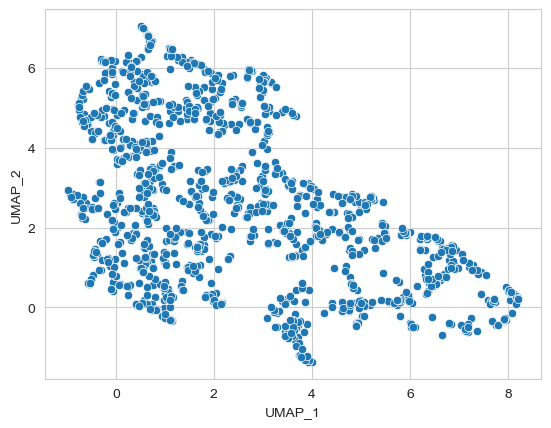

In [58]:
# Plot 2D data
sns.scatterplot(data=df_comparison, x='UMAP_1', y='UMAP_2')

In [62]:
# HDBSCAN
clusterer = HDBSCAN(
    min_cluster_size=20,  # Minimum number of cities to form a cluster
    min_samples=5,  # Higher values increase noise tolerance
    cluster_selection_epsilon=0.5,
    cluster_selection_method='leaf',
    metric='euclidean',
)

df_comparison['HDBSCAN_Cluster'] = clusterer.fit_predict(X_embedded)

# Display cluster distribution (-1 represents Noise/Anomalies)
print(df_comparison['HDBSCAN_Cluster'].value_counts())

HDBSCAN_Cluster
 0    1129
 1      66
-1       7
Name: count, dtype: int64


In [63]:
def plot_umap_clusters(df):
    # Scatter plot of UMAP coordinates colored by HDBSCAN clusters

    unique_clusters = sorted(df['HDBSCAN_Cluster'].unique())

    # Generate 20 distinct colors using 'tab20'
    tab20_colors = sns.color_palette("tab20", n_colors=len(unique_clusters))
    color_dict = {
        cluster: color for cluster, color in zip(unique_clusters, tab20_colors)
    }
    color_dict[-1] = (0.35, 0.35, 0.35)  # Dark Gray for Noise

    # 3. Map markers: 'X' for Noise (-1), 'o' for all real clusters
    marker_dict = {
        cluster: 'X' if cluster == -1 else 'o' for cluster in unique_clusters
    }

    scatter = sns.scatterplot(
        data=df,
        x='UMAP_1',
        y='UMAP_2',
        hue='HDBSCAN_Cluster',
        palette=color_dict,
        style='HDBSCAN_Cluster',    # Distinguish noise
        markers=marker_dict,        # Noise -> X, Normal -> o
        s=60,
        alpha=0.8,
    )

    plt.title(
        'UMAP + HDBSCAN Risk Profile Clusters',
        fontsize=14,
        fontweight='bold',
    )
    plt.xlabel('UMAP Dimension 1', fontsize=11)
    plt.ylabel('UMAP Dimension 2', fontsize=11)
    plt.legend(title='Cluster ID (-1 = Noise)', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    return color_dict

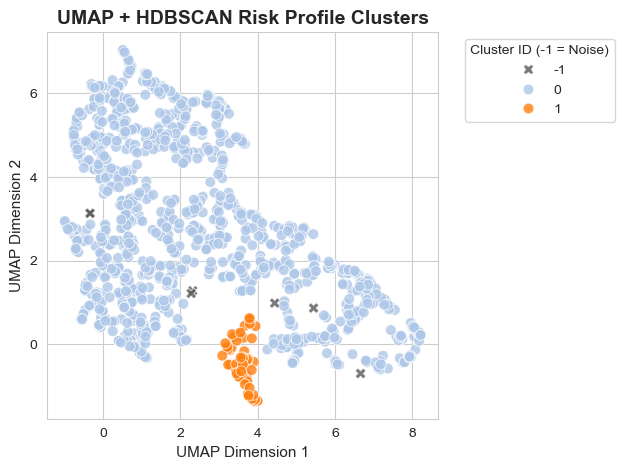

In [64]:
color_dict = plot_umap_clusters(df_comparison)

After some tweaks and tuning, UMAP successfully captured the dataset's non-linear manifold and structural relationships among the cities, while HDBSCAN identified the different clusters.  
We don't know what these clusters represent, so we must investigate each one to see what they represent and what our ML algorithm has found. 

### CLUSTERS CHECK: PLOTS

In [65]:
def plot_boxplots_metrics(df, metrics, target_clusters = None):

    if target_clusters is None:
        target_clusters = df['HDBSCAN_Cluster'].unique()

    fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True)
    axes = axes.flatten()

    for i, metric in enumerate(features_ml):
        sns.boxplot(
            data=df[df['HDBSCAN_Cluster'].isin(target_clusters)],
            x='HDBSCAN_Cluster',
            y=metric,
            ax=axes[i],
            hue='HDBSCAN_Cluster',
            palette=color_dict,
            legend=False,
        )
        axes[i].set_title(metric, fontsize=11, fontweight='bold')
        axes[i].set_xlabel('Clusters ID')


    plt.suptitle('Cluster Metric Distributions Comparison', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

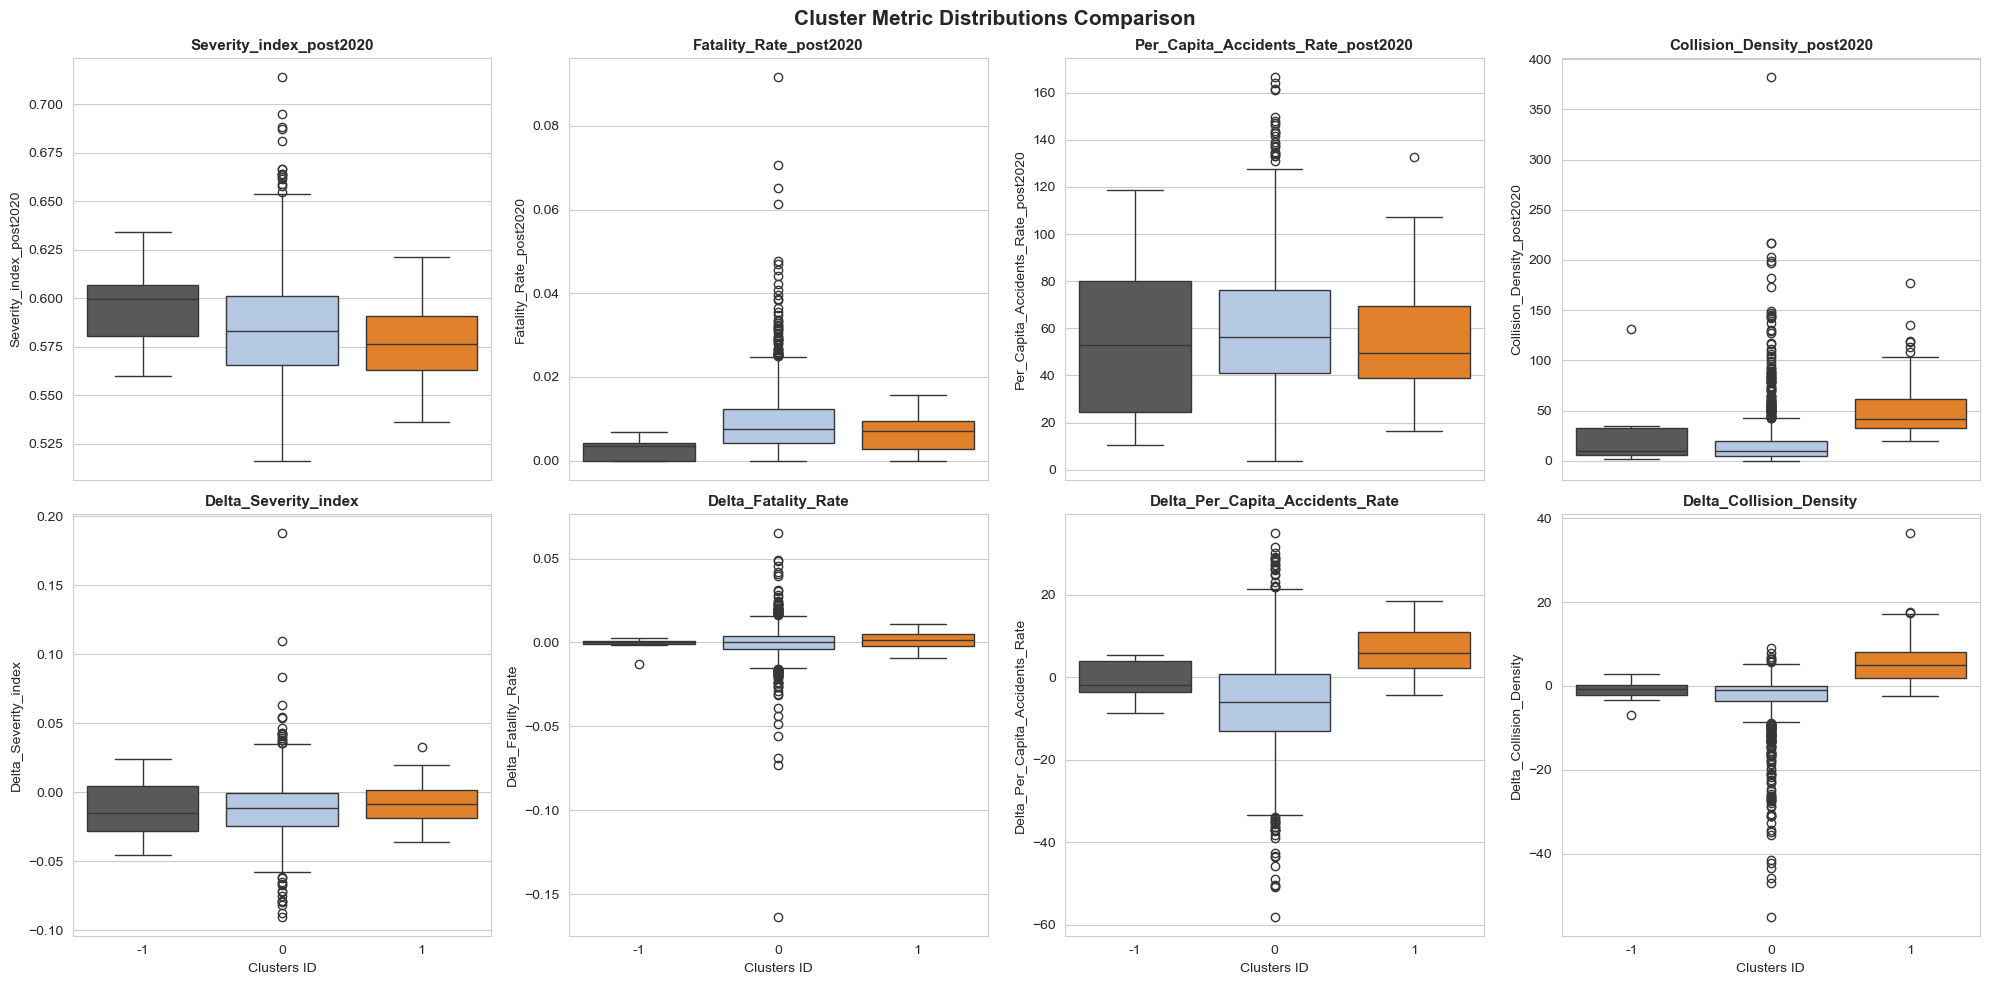

In [66]:
plot_boxplots_metrics(df_comparison, features_ml)

In [34]:
def print_cluster_metrics_information(df, cluster_id):
    pd.set_option('display.width', 1000)
    
    print(f"Cluster {cluster_id} Information:")
    print(df.loc[df['HDBSCAN_Cluster'] == cluster_id, features_ml].describe())

From this graph, we can see that some clusters match the characteristics we were looking for, namely which cities have seen the greatest increase in accidents, warranting investment in safety, and which have shown no change in recent years or even an improvement.  
First, let’s analyze the largest clusters where a certain trend is evident.  
- **Cluster 1**: we can see that there has been a significant increase in the `Fatality_Rate`. Examining both the distribution of post-2020 data and the difference from pre-2020 data, we observe that both distributions are characterized by positive skewness, meaning the values tend more toward higher, positive values. Another factor to consider is that there is both a high post-2020 Fatality_Rate value and a positive difference; this indicates that there has been a sharp increase in fatal accidents in recent years for those cities.  
Looking at the per capita rate, we see that, in general, there has not been a significant difference: the number of accidents does not reach extremely high values, and the Delta is centered around 0 with a distribution that is nearly Gaussian.

In [35]:
print_cluster_metrics_information(df_comparison, 1)

Cluster 1 Information:
       Severity_index_post2020  Fatality_Rate_post2020  Per_Capita_Accidents_Rate_post2020  Collision_Density_post2020  Delta_Severity_index  Delta_Fatality_Rate  Delta_Per_Capita_Accidents_Rate  Delta_Collision_Density
count                50.000000               50.000000                           50.000000                   50.000000             50.000000            50.000000                        50.000000                50.000000
mean                  0.558286                0.348381                           22.940053                    0.281869              0.068434             0.347093                        -0.744558                -0.285144
std                   0.086694                0.114172                           24.171012                    0.217620              0.250666             0.113806                        35.777464                 1.035237
min                   0.500000                0.250000                            3.695492       

- **Cluster 2** shows a similar trend: a post-2020 period and a Delta greater than zero for the `Severity_index` tells us that there has been an increase in serious accidents, but not fatal ones (the fatality rate is close to zero, except for some outliers). The slight increase in accidents per capita and collisions density also confirms the rise in accidents involving injuries in these types of cities.

In [36]:
print_cluster_metrics_information(df_comparison, 2)

Cluster 2 Information:
       Severity_index_post2020  Fatality_Rate_post2020  Per_Capita_Accidents_Rate_post2020  Collision_Density_post2020  Delta_Severity_index  Delta_Fatality_Rate  Delta_Per_Capita_Accidents_Rate  Delta_Collision_Density
count               306.000000              306.000000                          306.000000                  306.000000            306.000000           306.000000                       306.000000               306.000000
mean                  0.570484                0.009270                           33.804821                    0.373521              0.568850             0.009270                        33.761364                 0.371108
std                   0.087908                0.037244                           32.161176                    0.511681              0.086397             0.037244                        32.093455                 0.497526
min                   0.500000                0.000000                            2.644803       

- **Cluster 5-9** even if are small, they present a similar trend to **Cluster 2**. There is an increase in the `Severity_index`, but no increase in the `Fatality_Rate`. There is also a small increase in the `Per_Capita_Accidents_Rate`.

- **Cluster 3**, on the other hand, we see the opposite trend. The `Per_Capita_Accidents_Rate` has decreased, as the negative delta of the `Severity_index` and the `Fatality_Rate`, indicating a lower number of serious accidents compared to pre 2020. This is a sign of improved safety on the road.

In [37]:
print_cluster_metrics_information(df_comparison, 3)

Cluster 3 Information:
       Severity_index_post2020  Fatality_Rate_post2020  Per_Capita_Accidents_Rate_post2020  Collision_Density_post2020  Delta_Severity_index  Delta_Fatality_Rate  Delta_Per_Capita_Accidents_Rate  Delta_Collision_Density
count               176.000000              176.000000                          176.000000                  176.000000            176.000000           176.000000                       176.000000               176.000000
mean                  0.124079                0.002058                            6.401633                    0.103057             -0.510052            -0.097633                       -27.375610                -0.467448
std                   0.243923                0.016123                           15.585906                    0.298141              0.283409             0.145566                        48.694773                 0.793014
min                   0.000000                0.000000                            0.000000       

- **Special mention:** We have some other cluster that doesn't show a strong, clear distribution as the other we mentioned before, indicating a very specific local group that we can joing to the other.  
**Cluster 4** is quite close to **Cluster 3**: similar values in distribution but not extreme as **Cluster 3**.  
**Cluster 0** is the cluster where all the metrics are zero, indicating cities without any record of accidents.  
**Cluster 7** should represent the general case, where there are no significant changes over time. However, there are many outliers in each boxplot. This could indicate small towns where metrics can change rapidly (for example, two additional accidents in a city of 1000 residents can greatly increase the per capita rate!). We will follow the algorithm of placing these outliers in the larger cluster since they could only show differences in one metric, while the others don't. Statistically, they are meaningless. A similar discussion applies to the noise cluster, since we set a minimum cluster size of 50, which is large enough to provide statistical information.

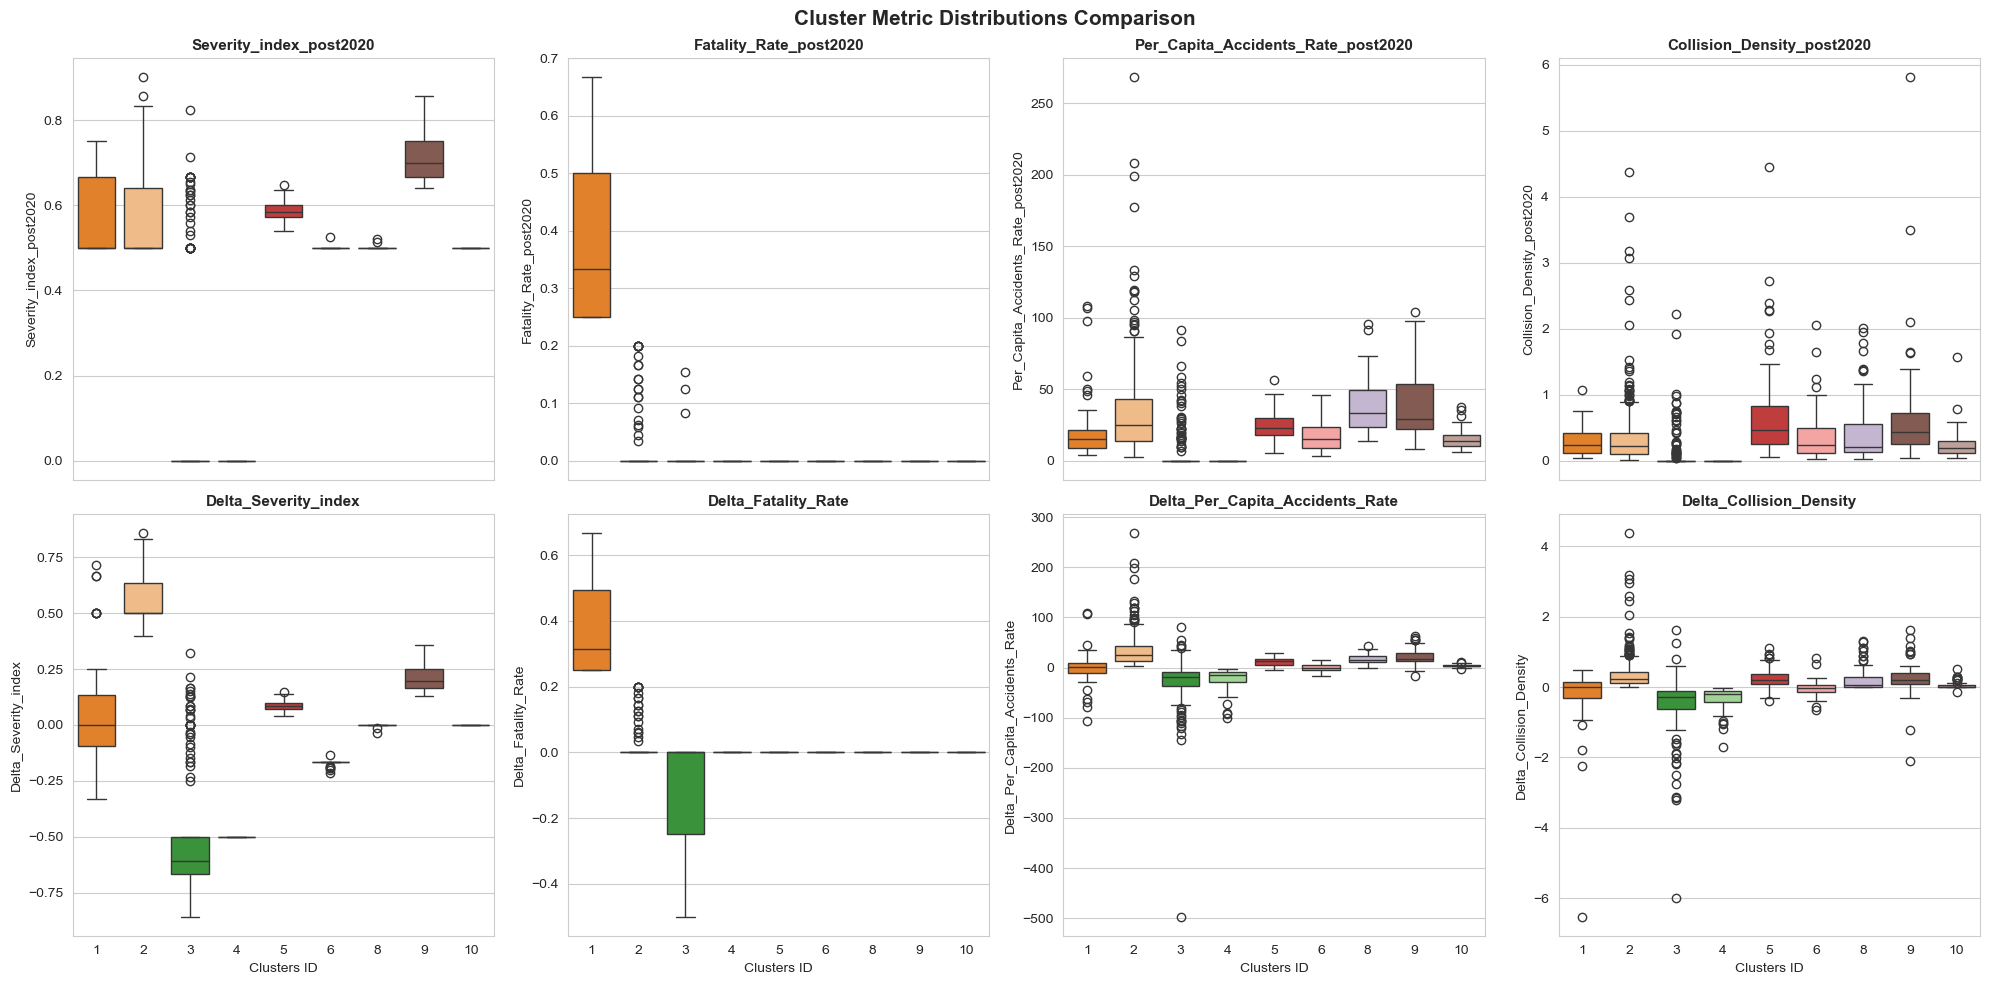

In [ ]:
# Same plot but without cluster with ID -1, 0, 7

plot_boxplots_metrics(df_comparison, features_ml, target_clusters=[1, 2, 3, 4, 5, 6, 8, 9, 10])

**First Conclusions**

When we view the clusters without the outliers of **Cluster 0**, **7**, and **-1 (noise)**, we can confirm some of our deductions:
- **Cluster 1** has a significant increase in deadly accidents and accidents overall.
- **Cluster 2** shows an increase in the number of accidents, as well as a majority of injuries, while deaths are pretty low. This could be due to low/medium speed accidents, which usually occur in big cities. **Clusters 2**, **5**, and **9** show similar results and can be grouped together.
- **Cluster 3** represents the safest cities, with a decrease in accidents in terms of both number and severity. **Clusters 4** has similar trends and can be grouped together.
- **Cluster 7** shows the general trend of Italian cities without any particular variations. **Clusters** **6**, **8**, and **10** can also be grouped together.
- **Clusters 0** and **-1** are those for which we have no accident information, or which are considered outliers because they could not be grouped within any other cluster.

In [39]:
print_cluster_metrics_information(df_comparison, 0)

Cluster 0 Information:
       Severity_index_post2020  Fatality_Rate_post2020  Per_Capita_Accidents_Rate_post2020  Collision_Density_post2020  Delta_Severity_index  Delta_Fatality_Rate  Delta_Per_Capita_Accidents_Rate  Delta_Collision_Density
count                    295.0                   295.0                               295.0                       295.0                 295.0                295.0                            295.0                    295.0
mean                       0.0                     0.0                                 0.0                         0.0                   0.0                  0.0                              0.0                      0.0
std                        0.0                     0.0                                 0.0                         0.0                   0.0                  0.0                              0.0                      0.0
min                        0.0                     0.0                                 0.0       

## Making First Conclusion
After verifying the various similarities in the results from the UMAP and HDBSCAN clustering analyses, we can begin to classify cities based on their accident risk level into four main categories:
- **A** = high risk of fatalities,
- **B** = high risk of serious accidents,
- **C** = average safety level,
- **D** = improved road safety.
- **N** = no statistical informations.  
The order A, B, C, and D reflects the priority order for investment.  
Let's continue by grouping the various clusters into the four categories listed above

In [52]:
risk_categories = {
    -1: 'N',
    0: 'N',
    1: 'A',
    2: 'B',
    3: 'D',
    4: 'D',
    5: 'B',
    6: 'C',
    7: 'C',
    8: 'C',
    9: 'B',
    10: 'C',
}

In [53]:
# Add the categories
df_comparison['Risk_Category'] = df_comparison['HDBSCAN_Cluster'].map(risk_categories)
df_comparison.sample(5)

,City_ID,City,Province_post2020,Region,Sum_Residents_post2020,Mean_Area_km2_post2020,Total_Collisions_post2020,Total_Fatalities_post2020,Total_Injuries_post2020,Total_Accidents_post2020,...,Per_Capita_Accidents_Rate_pre2020,Collision_Density_pre2020,Delta_Severity_index,Delta_Fatality_Rate,Delta_Per_Capita_Accidents_Rate,Delta_Collision_Density,UMAP_1,UMAP_2,HDBSCAN_Cluster,Risk_Category
1454,12110,Orino,VA,Lombardia,2493.0,3.7246,2.0,1.0,1.0,4.0,...,24.405125,2.147882,-0.125000,0.250000,-8.360199,-1.073941,2.081700,15.929948,1,A
5966,74004,Cellino San Marco,BR,Puglia,24257.0,37.8386,49.0,2.0,62.0,113.0,...,73.270014,4.994926,-0.063258,0.012408,-26.685522,-2.008557,3.922618,2.977939,7,C
2502,19026,Castelverde,CR,Lombardia,22412.0,30.8908,59.0,2.0,92.0,153.0,...,59.643032,4.337847,-0.019949,0.005609,8.623968,0.615084,6.170020,2.961830,7,C
4007,41049,Piobbico,PU,Marche,7212.0,48.1975,15.0,2.0,22.0,39.0,...,32.010243,0.518699,0.015385,0.011282,22.066296,0.290471,4.414338,4.829967,7,C
1170,8061,Triora,IM,Liguria,1523.0,67.6059,1.0,0.0,1.0,2.0,...,42.553191,0.088750,0.000000,0.000000,-29.421215,-0.059166,10.404273,9.273228,7,C


In [54]:
# Some cleaning
df_comparison = df_comparison.rename(columns={
    'City_post2020': 'City',
    'Province_post2020': 'Province',
    'Region_post2020': 'Region',
})

In [55]:
# add the categories also into the 2001-2024 dataframe
city_to_risk = df_comparison.set_index('City_ID')['Risk_Category'].to_dict()
df_pivot['Current_Risk_Category'] = df_pivot['City'].map(city_to_risk)

### Category A: high risk of fatalities
Let's investigate the city with a high fatality rate post 2020

In [79]:
category_A = df_comparison[df_comparison['Risk_Category'] == 'A'].copy()

category_A[['Sum_Residents_post2020', 'Mean_Area_km2_post2020']].describe()

,Sum_Residents_post2020,Mean_Area_km2_post2020
count,50.000000,50.000000
mean,2622.920000,21.613540
std,1657.396136,15.987215
min,375.000000,3.724600
25%,1487.500000,9.188450
50%,2039.500000,18.788800
75%,3838.750000,27.319250
max,6701.000000,67.893700


In [ ]:
# Top 10 cities with the highest fatality rate
useful_columns = ['City_ID', 'City', 'Province', 'Region', 'Sum_Residents_post2020', 'Mean_Area_km2_post2020', 'Total_Accidents_post2020', 'Fatality_Rate_pre2020', 'Fatality_Rate_post2020', 'Delta_Fatality_Rate']
category_A[useful_columns].sort_values('Fatality_Rate_post2020', ascending=False).head(10)

,City_ID,City,Province,Region,Sum_Residents_post2020,Mean_Area_km2_post2020,Total_Accidents_post2020,Fatality_Rate_pre2020,Fatality_Rate_post2020,Delta_Fatality_Rate
5646,69003,Ari,CH,Abruzzo,4269.0,11.3916,3.0,0.00000,0.666667,0.666667
1964,16127,Locatello,BG,Lombardia,2465.0,3.7894,2.0,0.00000,0.500000,0.500000
5552,67003,Arsita,TE,Abruzzo,2221.0,34.1360,2.0,0.00000,0.500000,0.500000
4185,46014,Fosciandora,LU,Toscana,1669.0,19.8593,2.0,0.00000,0.500000,0.500000
618,4140,Monteu Roero,CN,Piemonte,4849.0,24.6997,2.0,0.00000,0.500000,0.500000
741,5014,Calliano,AT,Piemonte,1209.0,17.2930,2.0,0.02439,0.500000,0.475610
7318,96023,Curino,BI,Piemonte,1414.0,21.6494,2.0,0.00000,0.500000,0.500000
6832,86017,Sperlinga,EN,Sicilia,2047.0,59.1390,2.0,0.00000,0.500000,0.500000
6721,83079,San Marco d'Alunzio,ME,Sicilia,5412.0,26.1407,2.0,0.00000,0.500000,0.500000
4962,61071,Roccaromana,CE,Campania,2478.0,27.7121,2.0,0.00000,0.500000,0.500000


From what we can see, the towns with the highest fatality rates after 2020 are those with populations under 10,000 and areas under 100 $\text{Km}^2$

In [69]:
category_A.groupby(['Region']).agg({'City_ID': 'count'}).sort_values('City_ID', ascending=False)

,City_ID
Region,
Piemonte,12
Lombardia,7
Abruzzo,5
Campania,5
Sicilia,5
Lazio,3
Liguria,3
Sardegna,3
Basilicata,2


And the towns with the highest fatality rates are in the Piemonte region. 

In [82]:
category_A[category_A['Region'] == 'Piemonte'].groupby(['Province']).agg({'City_ID': 'count'}).sort_values('City_ID', ascending=False)

,City_ID
Province,
AT,3
CN,3
AL,2
BI,2
TO,1
VC,1
